In [1]:
# Step 1 — Raw Data Audit

In [1]:
from pathlib import Path

DATA_PATH = "/root/autodl-tmp/data/04-24.csv"

p = Path(DATA_PATH)

print("Exists:", p.exists())
print("Size:", round(p.stat().st_size / 1024**3, 2), "GB")

Exists: True
Size: 1.53 GB


In [2]:
# ============================================================
# Reproducibility settings
# ============================================================

import os

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import random
import numpy as np
import tensorflow as tf

tf.config.experimental.enable_op_determinism()


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

I0000 00:00:1788535377.068948    1026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788535377.123740    1026 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788535378.181802    1026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# ============================================================
# Step 1 — Raw Data Audit
# ============================================================

import pandas as pd
import numpy as np

DATA_PATH = "/root/autodl-tmp/data/04-24.csv"

df = pd.read_csv(DATA_PATH)

print("===== BASIC INFO =====")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

# ---------- Time ----------
df["valid_time"] = pd.to_datetime(df["valid_time"])

print("\n===== TIME =====")
print("Start:", df["valid_time"].min())
print("End:", df["valid_time"].max())
print("Unique timestamps:", df["valid_time"].nunique())

times = np.sort(df["valid_time"].unique())
time_diff = pd.Series(times[1:] - times[:-1])

print("\nMost common time intervals:")
print(time_diff.value_counts().head())

# ---------- Spatial ----------
print("\n===== SPATIAL =====")
print("Latitude range:", df["latitude"].min(), "to", df["latitude"].max())
print("Longitude range:", df["longitude"].min(), "to", df["longitude"].max())

print("Unique latitude:", df["latitude"].nunique())
print("Unique longitude:", df["longitude"].nunique())

grid_points = (
    df[["latitude", "longitude"]]
    .drop_duplicates()
    .shape[0]
)
print("Total unique grid points:", grid_points)

# 每个时间有多少空间格点
rows_per_time = df.groupby("valid_time").size()

print("\n===== GRID POINTS PER TIMESTAMP =====")
print(rows_per_time.describe())
print("Unique counts:", rows_per_time.unique())

# ---------- Missing ----------
print("\n===== MISSING VALUES =====")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

# ---------- Target ----------
print("\n===== RAW TP =====")
print(
    df["tp"].describe(
        percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
    )
)

print("\nLargest 10 raw tp values:")
print(df["tp"].nlargest(10).tolist())

# ---------- Duplicate ----------
print("\n===== DUPLICATES =====")
duplicates = df.duplicated(
    subset=["valid_time", "latitude", "longitude"]
).sum()

print("Duplicate time-lat-lon rows:", duplicates)

print("\n===== STEP 1 COMPLETE =====")

===== BASIC INFO =====
Shape: (10869579, 17)
Columns: ['valid_time', 'latitude', 'longitude', 'number', 'expver', 'u10', 'v10', 'd2m', 't2m', 'sp', 'tp', 'e', 'mxtpr', 'mntpr', 'tcc', 'ssr', 'lsp']


,valid_time,latitude,longitude,number,expver,u10,v10,d2m,t2m,sp,tp,e,mxtpr,mntpr,tcc,ssr,lsp
0,2004-01-01 00:00:00,55.5,-10.50,0,1,15.037308,-12.340988,279.58910,282.60413,99860.06,0.000139,-0.000256,0.000067,0.000017,0.543610,3.599999e-12,0.000037
1,2004-01-01 00:00:00,55.5,-10.25,0,1,15.046097,-11.705246,279.74536,282.67834,99792.06,0.000226,-0.000238,0.000109,0.000050,0.481079,3.599999e-12,0.000031
2,2004-01-01 00:00:00,55.5,-10.00,0,1,14.989456,-10.914230,279.89380,282.75647,99740.06,0.000283,-0.000222,0.000109,0.000050,0.412537,3.599999e-12,0.000026
3,2004-01-01 00:00:00,55.5,-9.75,0,1,14.779495,-9.798019,280.01100,282.83070,99715.06,0.000274,-0.000207,0.000112,0.000050,0.329193,3.599999e-12,0.000022
4,2004-01-01 00:00:00,55.5,-9.50,0,1,14.564652,-8.629074,280.08130,282.88538,99663.06,0.000273,-0.000191,0.000112,0.000050,0.274841,3.599999e-12,0.000019



===== TIME =====
Start: 2004-01-01 00:00:00
End: 2024-11-02 12:00:00
Unique timestamps: 30447

Most common time intervals:
0 days 06:00:00    30446
Name: count, dtype: int64

===== SPATIAL =====
Latitude range: 51.5 to 55.5
Longitude range: -10.5 to -5.5
Unique latitude: 17
Unique longitude: 21
Total unique grid points: 357

===== GRID POINTS PER TIMESTAMP =====
count    30447.0
mean       357.0
std          0.0
min        357.0
25%        357.0
50%        357.0
75%        357.0
max        357.0
dtype: float64
Unique counts: [357]

===== MISSING VALUES =====
tp       1480479
e        1480479
mxtpr    1480479
mntpr    1480479
ssr      1480479
lsp      1480479
dtype: int64

===== RAW TP =====
count    9.389100e+06
mean     1.344345e-04
std      3.537806e-04
min      0.000000e+00
50%      8.583069e-06
90%      3.786087e-04
95%      7.572174e-04
99%      1.791477e-03
99.9%    3.398418e-03
max      1.262236e-02
Name: tp, dtype: float64

Largest 10 raw tp values:
[0.012622356, 0.011207581, 

In [4]:
# ============================================================
# Step 2A — Dublin Subset + Missing-Time Audit
# ============================================================

import pandas as pd
import numpy as np

# Dublin 5x5 domain used in the paper
LAT_MIN, LAT_MAX = 52.75, 53.75
LON_MIN, LON_MAX = -6.75, -5.75

df_dublin = df[
    df["latitude"].between(LAT_MIN, LAT_MAX) &
    df["longitude"].between(LON_MIN, LON_MAX)
].copy()

print("===== DUBLIN SUBSET =====")
print("Shape:", df_dublin.shape)

print("Unique latitude:", sorted(df_dublin["latitude"].unique()))
print("Unique longitude:", sorted(df_dublin["longitude"].unique()))

print("Latitude count:", df_dublin["latitude"].nunique())
print("Longitude count:", df_dublin["longitude"].nunique())

print(
    "Unique grid points:",
    df_dublin[["latitude", "longitude"]]
    .drop_duplicates()
    .shape[0]
)

print("\nRows per timestamp:")
print(df_dublin.groupby("valid_time").size().value_counts())

# ------------------------------------------------------------
# Missing audit
# ------------------------------------------------------------

missing_vars = ["tp", "e", "mxtpr", "mntpr", "ssr", "lsp"]

print("\n===== MISSING COUNTS IN DUBLIN =====")
print(df_dublin[missing_vars].isna().sum())

# How many missing grid cells at each timestamp?
tp_missing_by_time = (
    df_dublin.groupby("valid_time")["tp"]
    .apply(lambda x: x.isna().sum())
)

print("\nMissing TP cells per timestamp:")
print(tp_missing_by_time.value_counts().sort_index())

missing_times = tp_missing_by_time[
    tp_missing_by_time > 0
].index

print("\nNumber of timestamps with missing TP:", len(missing_times))

if len(missing_times) > 0:
    print("First missing timestamp:", missing_times.min())
    print("Last missing timestamp:", missing_times.max())

    print("\nFirst 20 missing timestamps:")
    print(missing_times[:20])

# expver check
print("\n===== EXPVER =====")
print(df_dublin["expver"].value_counts(dropna=False))

print("\nexpver distribution for missing TP rows:")
print(
    df_dublin.loc[
        df_dublin["tp"].isna(), "expver"
    ].value_counts(dropna=False)
)

===== DUBLIN SUBSET =====
Shape: (761175, 17)
Unique latitude: [np.float64(52.75), np.float64(53.0), np.float64(53.25), np.float64(53.5), np.float64(53.75)]
Unique longitude: [np.float64(-6.75), np.float64(-6.5), np.float64(-6.25), np.float64(-6.0), np.float64(-5.75)]
Latitude count: 5
Longitude count: 5
Unique grid points: 25

Rows per timestamp:
25    30447
Name: count, dtype: int64

===== MISSING COUNTS IN DUBLIN =====
tp       103675
e        103675
mxtpr    103675
mntpr    103675
ssr      103675
lsp      103675
dtype: int64

Missing TP cells per timestamp:
tp
0     26300
25     4147
Name: count, dtype: int64

Number of timestamps with missing TP: 4147
First missing timestamp: 2022-01-01 00:00:00
Last missing timestamp: 2024-11-02 12:00:00

First 20 missing timestamps:
DatetimeIndex(['2022-01-01 00:00:00', '2022-01-01 06:00:00',
               '2022-01-01 12:00:00', '2022-01-01 18:00:00',
               '2022-01-02 00:00:00', '2022-01-02 06:00:00',
               '2022-01-02 12:00:

In [5]:
# ============================================================
# Step 2B — Dublin Regional Aggregation
# 25 grid cells -> one regional mean time series
# Period: 2004-01-01 to 2021-12-31
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Keep only the complete period
# ------------------------------------------------------------

END_TIME = pd.Timestamp("2021-12-31 18:00:00")

df_complete = df_dublin[
    df_dublin["valid_time"] <= END_TIME
].copy()

print("===== COMPLETE DUBLIN DATA =====")
print("Rows:", len(df_complete))
print("Start:", df_complete["valid_time"].min())
print("End:", df_complete["valid_time"].max())
print("Unique timestamps:", df_complete["valid_time"].nunique())

# ------------------------------------------------------------
# 2. Define final variables
# ------------------------------------------------------------

FEATURES = [
    "mxtpr",
    "mntpr",
    "lsp",
    "tcc",
    "v10",
    "u10",
    "d2m"
]

TARGET = "tp"

required_cols = FEATURES + [TARGET]

# Confirm no missing values in selected period
print("\n===== MISSING VALUES BEFORE AGGREGATION =====")
print(df_complete[required_cols].isna().sum())

# ------------------------------------------------------------
# 3. Regional mean across the 25 Dublin grid cells
# ------------------------------------------------------------

df_regional = (
    df_complete
    .groupby("valid_time", as_index=False)[required_cols]
    .mean()
    .sort_values("valid_time")
    .reset_index(drop=True)
)

print("\n===== REGIONAL DATA =====")
print("Shape:", df_regional.shape)
print("Start:", df_regional["valid_time"].min())
print("End:", df_regional["valid_time"].max())

display(df_regional.head())

# ------------------------------------------------------------
# 4. Convert precipitation TARGET from metres to millimetres
# IMPORTANT: only once
# ------------------------------------------------------------

df_regional["tp_mm"] = df_regional["tp"] * 1000.0

# Keep original tp temporarily for verification
print("\n===== REGIONAL TP CHECK =====")
print("Raw tp (m):")
print(df_regional["tp"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
))

print("\ntp converted to mm:")
print(df_regional["tp_mm"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
))

print("\nMaximum regional tp:")
print("metres:", df_regional["tp"].max())
print("mm:", df_regional["tp_mm"].max())

# ------------------------------------------------------------
# 5. Verify strictly regular 6-hourly time series
# ------------------------------------------------------------

time_diff = df_regional["valid_time"].diff().dropna()

print("\n===== TEMPORAL CONTINUITY =====")
print(time_diff.value_counts())

expected_rows = (
    pd.date_range(
        start=df_regional["valid_time"].min(),
        end=df_regional["valid_time"].max(),
        freq="6h"
    )
)

print("Expected timestamps:", len(expected_rows))
print("Actual timestamps:", len(df_regional))
print(
    "Continuous 6-hour series:",
    len(expected_rows) == len(df_regional)
)

# ------------------------------------------------------------
# 6. Final dataset used from this point onward
# ------------------------------------------------------------

df_model = df_regional[
    ["valid_time"] + FEATURES + ["tp_mm"]
].copy()

print("\n===== FINAL MODEL DATA =====")
print("Shape:", df_model.shape)
print("Columns:", df_model.columns.tolist())

display(df_model.head())

# ------------------------------------------------------------
# 7. Save clean regional dataset
# ------------------------------------------------------------

OUTPUT_PATH = (
    "/root/autodl-tmp/data/"
    "dublin_regional_2004_2021.csv"
)

df_model.to_csv(OUTPUT_PATH, index=False)

print("\nSaved to:")
print(OUTPUT_PATH)

print("\n===== STEP 2B COMPLETE =====")

===== COMPLETE DUBLIN DATA =====
Rows: 657500
Start: 2004-01-01 00:00:00
End: 2021-12-31 18:00:00
Unique timestamps: 26300

===== MISSING VALUES BEFORE AGGREGATION =====
mxtpr    0
mntpr    0
lsp      0
tcc      0
v10      0
u10      0
d2m      0
tp       0
dtype: int64

===== REGIONAL DATA =====
Shape: (26300, 9)
Start: 2004-01-01 00:00:00
End: 2021-12-31 18:00:00


,valid_time,mxtpr,mntpr,lsp,tcc,v10,u10,d2m,tp
0,2004-01-01 00:00:00,5.617142e-06,3.719330e-07,8.487701e-06,0.202726,0.947801,6.650042,277.814113,1.941681e-05
1,2004-01-01 06:00:00,4.873276e-06,1.702309e-06,8.277893e-06,0.408947,-2.558291,7.981807,277.712466,1.342773e-05
2,2004-01-01 12:00:00,3.862381e-07,1.335144e-07,7.629394e-07,0.383137,-4.215610,7.123491,276.204019,8.201599e-07
3,2004-01-01 18:00:00,3.814697e-08,1.907349e-08,4.959106e-07,0.404938,-4.978065,6.540432,275.706439,1.831055e-06
4,2004-01-02 00:00:00,4.196167e-07,1.955032e-07,9.727478e-07,0.795056,-4.172305,4.585667,275.937768,2.136230e-06



===== REGIONAL TP CHECK =====
Raw tp (m):
count    26300.000000
mean         0.000107
std          0.000279
min          0.000000
50%          0.000008
90%          0.000300
95%          0.000582
99%          0.001433
99.9%        0.002776
max          0.004135
Name: tp, dtype: float64

tp converted to mm:
count    26300.000000
mean         0.106632
std          0.279164
min          0.000000
50%          0.008278
90%          0.300301
95%          0.581972
99%          1.432554
99.9%        2.775609
max          4.134541
Name: tp_mm, dtype: float64

Maximum regional tp:
metres: 0.004134540564
mm: 4.134540564

===== TEMPORAL CONTINUITY =====
valid_time
0 days 06:00:00    26299
Name: count, dtype: int64
Expected timestamps: 26300
Actual timestamps: 26300
Continuous 6-hour series: True

===== FINAL MODEL DATA =====
Shape: (26300, 9)
Columns: ['valid_time', 'mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'u10', 'd2m', 'tp_mm']


,valid_time,mxtpr,mntpr,lsp,tcc,v10,u10,d2m,tp_mm
0,2004-01-01 00:00:00,5.617142e-06,3.719330e-07,8.487701e-06,0.202726,0.947801,6.650042,277.814113,0.019417
1,2004-01-01 06:00:00,4.873276e-06,1.702309e-06,8.277893e-06,0.408947,-2.558291,7.981807,277.712466,0.013428
2,2004-01-01 12:00:00,3.862381e-07,1.335144e-07,7.629394e-07,0.383137,-4.215610,7.123491,276.204019,0.000820
3,2004-01-01 18:00:00,3.814697e-08,1.907349e-08,4.959106e-07,0.404938,-4.978065,6.540432,275.706439,0.001831
4,2004-01-02 00:00:00,4.196167e-07,1.955032e-07,9.727478e-07,0.795056,-4.172305,4.585667,275.937768,0.002136



Saved to:
/root/autodl-tmp/data/dublin_regional_2004_2021.csv

===== STEP 2B COMPLETE =====


In [6]:
# ============================================================
# Step 2B Verification — expver / missing / grid integrity
# ============================================================

print("===== 1. EXPVER CHECK: 2004–2021 =====")

print(df_complete["expver"].value_counts(dropna=False))

print("\nTime range for each expver:")
for exp in sorted(df_complete["expver"].dropna().unique()):
    tmp = df_complete[df_complete["expver"] == exp]

    print(
        f"expver={exp}: "
        f"{len(tmp)} rows | "
        f"{tmp['valid_time'].min()} -> {tmp['valid_time'].max()} | "
        f"{tmp['valid_time'].nunique()} timestamps"
    )


# ============================================================
# 2. Explicit missing-value assertion
# ============================================================

assert (
    df_complete[required_cols]
    .isna()
    .sum()
    .sum()
    == 0
), "ERROR: Missing values exist before regional aggregation."

print("\n✓ No missing values in required variables.")


# ============================================================
# 3. Explicit 25-grid assertion
# ============================================================

cells_per_time = df_complete.groupby("valid_time").size()

assert (
    cells_per_time == 25
).all(), "ERROR: Some timestamps do not contain exactly 25 grid cells."

print("✓ Every timestamp contains exactly 25 grid cells.")


# ============================================================
# 4. Confirm the same 25 spatial locations exist every time
# ============================================================

expected_cells = set(
    map(
        tuple,
        df_complete[
            ["latitude", "longitude"]
        ].drop_duplicates().to_numpy()
    )
)

assert len(expected_cells) == 25

cell_integrity = (
    df_complete
    .groupby("valid_time")
    .apply(
        lambda x: set(
            map(
                tuple,
                x[["latitude", "longitude"]].to_numpy()
            )
        ) == expected_cells
    )
)

assert cell_integrity.all(), \
    "ERROR: Spatial grid locations differ across timestamps."

print("✓ The same 25 spatial cells are present at every timestamp.")

print("\n===== STEP 2B VERIFICATION PASSED =====")

===== 1. EXPVER CHECK: 2004–2021 =====
expver
1    657500
Name: count, dtype: int64

Time range for each expver:
expver=1: 657500 rows | 2004-01-01 00:00:00 -> 2021-12-31 18:00:00 | 26300 timestamps

✓ No missing values in required variables.
✓ Every timestamp contains exactly 25 grid cells.
✓ The same 25 spatial cells are present at every timestamp.

===== STEP 2B VERIFICATION PASSED =====


In [7]:
# ============================================================
# Step 2C — Chronological Split + Train-only Scaling
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler

FEATURES = [
    "mxtpr",
    "mntpr",
    "lsp",
    "tcc",
    "v10",
    "u10",
    "d2m"
]

TARGET = "tp_mm"

# ------------------------------------------------------------
# 1. Chronological 70 / 15 / 15 split
# ------------------------------------------------------------

n = len(df_model)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_model.iloc[:train_end].copy()
val_df   = df_model.iloc[train_end:val_end].copy()
test_df  = df_model.iloc[val_end:].copy()

print("===== SPLIT =====")

for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(
        f"{name}: {len(part)} rows | "
        f"{part['valid_time'].min()} -> "
        f"{part['valid_time'].max()}"
    )

# ------------------------------------------------------------
# 2. Fit scalers ONLY on training data
# ------------------------------------------------------------

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(train_df[FEATURES])
y_scaler.fit(train_df[[TARGET]])

# Transform each split
X_train_raw = x_scaler.transform(train_df[FEATURES])
X_val_raw   = x_scaler.transform(val_df[FEATURES])
X_test_raw  = x_scaler.transform(test_df[FEATURES])

y_train_raw = y_scaler.transform(train_df[[TARGET]]).ravel()
y_val_raw   = y_scaler.transform(val_df[[TARGET]]).ravel()
y_test_raw  = y_scaler.transform(test_df[[TARGET]]).ravel()

# ------------------------------------------------------------
# 3. Basic checks
# ------------------------------------------------------------

print("\n===== SCALED SHAPES =====")
print("X_train:", X_train_raw.shape)
print("X_val:", X_val_raw.shape)
print("X_test:", X_test_raw.shape)

print("y_train:", y_train_raw.shape)
print("y_val:", y_val_raw.shape)
print("y_test:", y_test_raw.shape)

print("\n===== TRAIN SCALER CHECK =====")
print(
    "Feature train mean:",
    np.round(X_train_raw.mean(axis=0), 4)
)
print(
    "Feature train std:",
    np.round(X_train_raw.std(axis=0), 4)
)

print(
    "Target train mean:",
    round(y_train_raw.mean(), 4)
)
print(
    "Target train std:",
    round(y_train_raw.std(), 4)
)

print("\n===== ORIGINAL TARGET DISTRIBUTION =====")
for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(
        name,
        "| mean =", round(part[TARGET].mean(), 4),
        "| max =", round(part[TARGET].max(), 4),
        "| 95th =", round(part[TARGET].quantile(0.95), 4)
    )

print("\n===== STEP 2C COMPLETE =====")


===== SPLIT =====
Train: 18410 rows | 2004-01-01 00:00:00 -> 2016-08-07 06:00:00
Validation: 3945 rows | 2016-08-07 12:00:00 -> 2019-04-20 12:00:00
Test: 3945 rows | 2019-04-20 18:00:00 -> 2021-12-31 18:00:00

===== SCALED SHAPES =====
X_train: (18410, 7)
X_val: (3945, 7)
X_test: (3945, 7)
y_train: (18410,)
y_val: (3945,)
y_test: (3945,)

===== TRAIN SCALER CHECK =====
Feature train mean: [-0. -0.  0. -0. -0.  0. -0.]
Feature train std: [1. 1. 1. 1. 1. 1. 1.]
Target train mean: -0.0
Target train std: 1.0

===== ORIGINAL TARGET DISTRIBUTION =====
Train | mean = 0.1061 | max = 4.1345 | 95th = 0.5739
Validation | mean = 0.101 | max = 3.4193 | 95th = 0.5241
Test | mean = 0.1149 | max = 2.9865 | 95th = 0.6524

===== STEP 2C COMPLETE =====


In [8]:
# ============================================================
# Step 2D — (A) Train-only feature re-selection
#            (B) Leak-free 6-hour sliding window construction
#
# Fixes audit items:
#   #9  Feature selection must use TRAIN data only, not full data
#   #8  No leakage: window features must be strictly <= t,
#       target must be strictly t+1 (next sample), never overlapping
#   #12 Confirms no interpolation is needed / no leakage from it
#
# IMPORTANT: this uses ALL raw candidate variables (not just the
# 7 that were pre-selected in the ORIGINAL notebook using full-
# data Spearman correlation). That original selection was itself
# a leakage risk (#9), so we redo it here honestly on train-only
# data, using df_complete from Step 2B which still has all raw
# columns before the old narrowing to `required_cols`.
# ============================================================
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# ------------------------------------------------------------
# 0. Re-aggregate regional means using ALL candidate variables
#    (df_complete comes from Step 2B, filtered to 2004-2021,
#    Dublin 5x5 subset, BEFORE it was narrowed to the 7 features)
# ------------------------------------------------------------
ALL_CANDIDATES = [
    'u10', 'v10', 'd2m', 't2m', 'sp', 'e',
    'mxtpr', 'mntpr', 'tcc', 'ssr', 'lsp'
]
TARGET_RAW = 'tp'

assert 'df_complete' in dir(), (
    "df_complete not found — re-run Step 2B up through the point "
    "where df_complete is defined (Dublin subset, 2004-2021), "
    "BEFORE it gets narrowed to the 7-feature required_cols."
)

missing_cols = [c for c in ALL_CANDIDATES + [TARGET_RAW] if c not in df_complete.columns]
assert not missing_cols, f"Missing expected raw columns: {missing_cols}"

print("===== 0. RE-AGGREGATING WITH FULL CANDIDATE SET =====")
assert df_complete[ALL_CANDIDATES + [TARGET_RAW]].isna().sum().sum() == 0, \
    "Unexpected missing values in candidate columns — investigate before proceeding."
assert (df_complete.groupby('valid_time').size() == 25).all(), \
    "Not every timestamp has exactly 25 grid cells — investigate before proceeding."

df_regional_full = (
    df_complete
    .groupby('valid_time', as_index=False)[ALL_CANDIDATES + [TARGET_RAW]]
    .mean()
    .sort_values('valid_time')
    .reset_index(drop=True)
)
df_regional_full['tp_mm'] = df_regional_full[TARGET_RAW] * 1000.0
df_regional_full = df_regional_full.drop(columns=[TARGET_RAW])

print("Shape:", df_regional_full.shape)
print("Range:", df_regional_full['valid_time'].min(), "->", df_regional_full['valid_time'].max())

# ------------------------------------------------------------
# 1. Chronological 70/15/15 split (identical boundaries to Step 2C)
# ------------------------------------------------------------
n = len(df_regional_full)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_full = df_regional_full.iloc[:train_end].copy()
val_full = df_regional_full.iloc[train_end:val_end].copy()
test_full = df_regional_full.iloc[val_end:].copy()

print("\n===== 1. SPLIT (for feature selection) =====")
for name, part in [('Train', train_full), ('Validation', val_full), ('Test', test_full)]:
    print(f"{name}: {len(part)} rows | {part['valid_time'].min()} -> {part['valid_time'].max()}")

# ------------------------------------------------------------
# 2. Spearman correlation — TRAIN ONLY
#    This is the corrected version of the original Fig. 2,
#    computed without touching val/test.
# ------------------------------------------------------------
print("\n===== 2. TRAIN-ONLY SPEARMAN CORRELATION WITH tp_mm =====")
corr_cols = ALL_CANDIDATES + ['tp_mm']
train_corr = train_full[corr_cols].corr(method='spearman')
tp_corr = train_corr['tp_mm'].drop('tp_mm').sort_values(key=abs, ascending=False)
print(tp_corr.round(3))

print("\n===== FULL TRAIN-ONLY SPEARMAN MATRIX =====")
print(train_corr.round(2))

# ------------------------------------------------------------
# 2b. Save to results/features/ — this is the ONLY source Fig. 2
#     should be plotted from downstream. Plotting scripts must
#     never recompute correlations themselves.
# ------------------------------------------------------------
import os
RESULTS_FEATURES_DIR = "/root/autodl-tmp/results/features"
os.makedirs(RESULTS_FEATURES_DIR, exist_ok=True)
train_corr_path = os.path.join(RESULTS_FEATURES_DIR, "train_only_spearman.csv")
train_corr.to_csv(train_corr_path)
print(f"\nSaved train-only Spearman matrix to: {train_corr_path}")

# ------------------------------------------------------------
# 3. Compare against the ORIGINAL (full-data, leaky) selection
#    Original selected set: mxtpr, mntpr, lsp, tcc, v10, u10, d2m
# ------------------------------------------------------------
ORIGINAL_SELECTION = ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'u10', 'd2m']
print("\n===== 3. ORIGINAL (FULL-DATA) SELECTION vs TRAIN-ONLY RANKING =====")
print("Original selected features:", ORIGINAL_SELECTION)
print("\nTrain-only |Spearman| ranking (all candidates, descending):")
print(tp_corr.abs().sort_values(ascending=False).round(3))
print(
    "\n>>> Manually compare: do the top-7 by |correlation| on TRAIN-ONLY "
    "match ORIGINAL_SELECTION? If not, decide whether to switch feature "
    "sets (changes Table 1 / Fig. 2 / all downstream SHAP) or keep the "
    "original set with a documented justification (e.g. physical "
    "relevance beyond raw correlation magnitude). <<<"
)

# ------------------------------------------------------------
# 4. FINALIZE feature set
#    CONFIRMED DECISION: swap u10 (|corr|=0.006, ~noise) for
#    sp (|corr|=0.428, physically well-motivated — low pressure
#    systems associate with precipitation). See train-only
#    ranking in Section 3 above.
# ------------------------------------------------------------
FINAL_FEATURES = ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
TARGET = 'tp_mm'

print(f"\n===== 4. FINAL FEATURES USED GOING FORWARD =====\n{FINAL_FEATURES}")

# ------------------------------------------------------------
# 5. Rebuild train/val/test with only the finalized columns
# ------------------------------------------------------------
train_df = train_full[['valid_time'] + FINAL_FEATURES + [TARGET]].reset_index(drop=True)
val_df = val_full[['valid_time'] + FINAL_FEATURES + [TARGET]].reset_index(drop=True)
test_df = test_full[['valid_time'] + FINAL_FEATURES + [TARGET]].reset_index(drop=True)

# ------------------------------------------------------------
# 6. Scaler — fit on TRAIN only (unchanged principle from Step 2C)
# ------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

x_scaler = StandardScaler()
y_scaler = StandardScaler()
x_scaler.fit(train_df[FINAL_FEATURES])
y_scaler.fit(train_df[[TARGET]])

for name, part in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
    part[FINAL_FEATURES] = x_scaler.transform(part[FINAL_FEATURES])
    part[TARGET + '_scaled'] = y_scaler.transform(part[[TARGET]])

print("\n===== 6. SCALING CHECK =====")
print("Train scaled feature means (~0 expected):",
      np.round(train_df[FINAL_FEATURES].mean().values, 4))
print("Train scaled feature stds (~1 expected):",
      np.round(train_df[FINAL_FEATURES].std().values, 4))

# ------------------------------------------------------------
# 7. Leak-free 6-hour sliding window construction
#    X[t-5, ..., t] -> y[t+1]  (each step 6 hours apart)
#    Built SEPARATELY per split so no window ever crosses a
#    split boundary.
# ------------------------------------------------------------
WINDOW = 6

def build_windows(df_part, features, target_col):
    """
    df_part must be sorted chronologically with no internal gaps.
    Returns X of shape (N, WINDOW, n_features), y of shape (N,),
    and the target timestamps for traceability.
    """
    values_X = df_part[features].values
    values_y = df_part[target_col].values
    times = df_part['valid_time'].values

    X_list, y_list, t_list = [], [], []
    # window covers indices [i, i+WINDOW-1] as input (t-5..t)
    # target is index i+WINDOW (i.e. t+1)
    for i in range(len(df_part) - WINDOW):
        X_list.append(values_X[i:i + WINDOW])
        y_list.append(values_y[i + WINDOW])
        t_list.append(times[i + WINDOW])

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
        np.array(t_list),
    )

# Explicit continuity check per split before windowing — a gap
# inside a split would silently create a window that spans a
# real time discontinuity.
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    diffs = pd.Series(pd.to_datetime(part['valid_time'])).diff().dropna()
    assert (diffs == pd.Timedelta(hours=6)).all(), (
        f"{name}_df is not strictly 6-hourly contiguous — "
        f"unexpected gap found. Investigate before windowing."
    )

X_train, y_train, t_train = build_windows(train_df, FINAL_FEATURES, TARGET + '_scaled')
X_val, y_val, t_val = build_windows(val_df, FINAL_FEATURES, TARGET + '_scaled')
X_test, y_test, t_test = build_windows(test_df, FINAL_FEATURES, TARGET + '_scaled')

print("\n===== 7. WINDOWED SHAPES =====")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

print("\n===== 7b. TARGET TIME RANGES (for later Fig. 4/5 sanity checks) =====")
print("Train targets:", pd.to_datetime(t_train).min(), "->", pd.to_datetime(t_train).max())
print("Val targets:  ", pd.to_datetime(t_val).min(), "->", pd.to_datetime(t_val).max())
print("Test targets: ", pd.to_datetime(t_test).min(), "->", pd.to_datetime(t_test).max())

# ------------------------------------------------------------
# 8. Leakage spot-check: confirm target timestamp is always
#    exactly 6h after the last feature timestamp in its window
# ------------------------------------------------------------
print("\n===== 8. LEAKAGE SPOT-CHECK (train, first 3 windows) =====")
for i in range(3):
    window_times = train_df['valid_time'].iloc[i:i + WINDOW].values
    target_time = train_df['valid_time'].iloc[i + WINDOW]
    gap = pd.to_datetime(target_time) - pd.to_datetime(window_times[-1])
    print(f"Window {i}: last feature time = {window_times[-1]}, "
          f"target time = {target_time}, gap = {gap}")
assert gap == pd.Timedelta(hours=6), "Gap between window end and target is not 6h!"

print("\n===== STEP 2D COMPLETE =====")
print("X_train/X_val/X_test and y_train/y_val/y_test are ready for modeling.")
print("Report back: Section 2 (train-only correlations), Section 3 comparison, "
      "and confirm whether FINAL_FEATURES should change.")

===== 0. RE-AGGREGATING WITH FULL CANDIDATE SET =====
Shape: (26300, 13)
Range: 2004-01-01 00:00:00 -> 2021-12-31 18:00:00

===== 1. SPLIT (for feature selection) =====
Train: 18410 rows | 2004-01-01 00:00:00 -> 2016-08-07 06:00:00
Validation: 3945 rows | 2016-08-07 12:00:00 -> 2019-04-20 12:00:00
Test: 3945 rows | 2019-04-20 18:00:00 -> 2021-12-31 18:00:00

===== 2. TRAIN-ONLY SPEARMAN CORRELATION WITH tp_mm =====
mxtpr    0.987
mntpr    0.943
lsp      0.899
tcc      0.475
sp      -0.428
d2m      0.219
v10      0.182
e       -0.136
t2m      0.127
ssr      0.061
u10     -0.006
Name: tp_mm, dtype: float64

===== FULL TRAIN-ONLY SPEARMAN MATRIX =====
        u10   v10   d2m   t2m    sp     e  mxtpr  mntpr   tcc   ssr   lsp  \
u10    1.00  0.05 -0.09 -0.05 -0.18 -0.13  -0.03  -0.04 -0.08 -0.08 -0.00   
v10    0.05  1.00  0.27  0.20 -0.27  0.09   0.20   0.19  0.31 -0.06  0.22   
d2m   -0.09  0.27  1.00  0.92 -0.03  0.13   0.24   0.22  0.26  0.21  0.23   
t2m   -0.05  0.20  0.92  1.00  0.03

In [16]:
# ============================================================
# Step 3 — XGBoost baseline
#
# DEPENDS ON (must already be in memory from Step 2D):
#   X_train, y_train, t_train
#   X_val,   y_val,   t_val
#   X_test,  y_test,  t_test
#   x_scaler, y_scaler   (fit on train only, from Step 2D)
#   FINAL_FEATURES = ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
#
# OUTPUT: results/predictions/xgboost_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std left empty — XGBoost point predictions only,
#    no native uncertainty estimate)
#
# NOTE: no plotting in this script. Plotting reads this CSV
# separately.
# ============================================================
import os
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'FINAL_FEATURES' in dir(), (
    "Step 2D outputs not found in memory — run step2d_feature_selection_windowing.py "
    "(with FINAL_FEATURES = ['mxtpr','mntpr','lsp','tcc','v10','sp','d2m']) first."
)

RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42

# ------------------------------------------------------------
# 1. Flatten windows: (samples, 6, 7) -> (samples, 42)
# ------------------------------------------------------------
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("===== 1. FLATTENED SHAPES =====")
print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:  ", X_val_flat.shape)
print("X_test_flat: ", X_test_flat.shape)

# ------------------------------------------------------------
# 2. Train XGBoost
#    (train+val could be combined for a final refit later if
#    you want to squeeze out extra data before a true holdout
#    test — NOT done here to keep val available for early
#    stopping / model comparison, consistent with the rest of
#    the pipeline)
# ------------------------------------------------------------
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
)

print("\n===== 2. TRAINING XGBOOST =====")
xgb_model.fit(X_train_flat, y_train)

# ------------------------------------------------------------
# 3. Predict on all three splits (scaled space)
# ------------------------------------------------------------
y_pred_train_scaled = xgb_model.predict(X_train_flat)
y_pred_val_scaled = xgb_model.predict(X_val_flat)
y_pred_test_scaled = xgb_model.predict(X_test_flat)

# ------------------------------------------------------------
# 4. Inverse-transform back to mm (using the TRAIN-fit y_scaler
#    from Step 2D — never refit here)
# ------------------------------------------------------------
def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(
        np.asarray(arr_scaled).reshape(-1, 1)
    ).flatten()

y_train_true_mm = inverse_y(y_train)
y_val_true_mm = inverse_y(y_val)
y_test_true_mm = inverse_y(y_test)

y_train_pred_mm = inverse_y(y_pred_train_scaled)
y_val_pred_mm = inverse_y(y_pred_val_scaled)
y_test_pred_mm = inverse_y(y_pred_test_scaled)

# ------------------------------------------------------------
# 5. Metrics (quick sanity print here only — the authoritative,
#    unified metrics computation across ALL models happens in
#    evaluate_predictions.py, not per-model scripts, to avoid
#    the Table 2 inconsistency bug from before)
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 5. QUICK SANITY METRICS (mm) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

# ------------------------------------------------------------
# 6. Save predictions in the standardized format
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": np.nan,  # XGBoost has no native uncertainty
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "xgboost_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 6. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 3 (XGBOOST) COMPLETE =====")

===== 1. FLATTENED SHAPES =====
X_train_flat: (18404, 42)
X_val_flat:   (3939, 42)
X_test_flat:  (3939, 42)

===== 2. TRAINING XGBOOST =====

===== 5. QUICK SANITY METRICS (mm) =====
Train        | RMSE=0.1861  MAE=0.0919  R2=0.5603
Validation   | RMSE=0.2513  MAE=0.1127  R2=0.1815
Test         | RMSE=0.2437  MAE=0.1188  R2=0.2060

===== 6. SAVED =====
/root/autodl-tmp/results/predictions/xgboost_preds.csv
Shape: (26282, 5)
split
test      3939
train    18404
val       3939
dtype: int64

===== STEP 3 (XGBOOST) COMPLETE =====


In [17]:
# ============================================================
# Step 3b — Persistence & Climatology naive baselines (#20)
#
# Purpose: give an honest reference frame. A "sophisticated"
# model's R2/RMSE only means something relative to how well a
# trivial method does on the same, leak-free test set.
#
# DEPENDS ON (already in memory from Step 2D):
#   train_df, val_df, test_df   (unscaled 'tp_mm' column, plus 'valid_time')
#   t_train, t_val, t_test      (target timestamps from build_windows)
#   WINDOW = 6                  (same window size used in Step 2D)
#
# Persistence: y_pred[t+1] = y_true[t]   (last known observed value)
# Climatology: y_pred[t+1] = mean(tp_mm) over TRAIN ONLY (constant)
#
# OUTPUT:
#   results/predictions/persistence_preds.csv
#   results/predictions/climatology_preds.csv
#   (same schema as xgboost_preds.csv: split, valid_time, y_true,
#    y_pred_mean, y_pred_std)
#
# NOTE: no plotting in this script.
# ============================================================
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'train_df' in dir() and 'WINDOW' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)

TARGET_COL = "tp_mm"

# ------------------------------------------------------------
# 1. Build persistence predictions per split
#    Same window alignment as build_windows(): for window i,
#    input covers indices [i, i+WINDOW-1] (i.e. up to time t),
#    target is index i+WINDOW (time t+1).
#    Persistence prediction = value at index i+WINDOW-1 (time t).
# ------------------------------------------------------------
def persistence_predictions(df_part, target_col, window):
    y_all = df_part[target_col].values
    times_all = df_part["valid_time"].values

    y_true, y_pred, times = [], [], []
    for i in range(len(df_part) - window):
        y_pred.append(y_all[i + window - 1])   # value at time t
        y_true.append(y_all[i + window])        # value at time t+1
        times.append(times_all[i + window])
    return np.array(y_true), np.array(y_pred), np.array(times)

y_train_true_p, y_train_pred_p, t_train_p = persistence_predictions(train_df, TARGET_COL, WINDOW)
y_val_true_p, y_val_pred_p, t_val_p = persistence_predictions(val_df, TARGET_COL, WINDOW)
y_test_true_p, y_test_pred_p, t_test_p = persistence_predictions(test_df, TARGET_COL, WINDOW)

# Sanity: these target timestamps/values should exactly match
# t_train/t_val/t_test and the unscaled y_true from Step 2D/3.
assert np.array_equal(pd.to_datetime(t_train_p), pd.to_datetime(t_train)), \
    "Persistence target timestamps do not match Step 2D windowing — check alignment."

# ------------------------------------------------------------
# 2. Build climatology predictions — constant TRAIN-only mean
# ------------------------------------------------------------
climatology_value = train_df[TARGET_COL].mean()
print(f"===== CLIMATOLOGY CONSTANT (train-only mean tp_mm) = {climatology_value:.4f} mm =====")

y_train_pred_c = np.full_like(y_train_true_p, climatology_value, dtype=np.float64)
y_val_pred_c = np.full_like(y_val_true_p, climatology_value, dtype=np.float64)
y_test_pred_c = np.full_like(y_test_true_p, climatology_value, dtype=np.float64)

# ------------------------------------------------------------
# 3. Quick sanity metrics for both baselines
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:22s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== PERSISTENCE BASELINE =====")
quick_metrics(y_train_true_p, y_train_pred_p, "Persistence - Train")
quick_metrics(y_val_true_p, y_val_pred_p, "Persistence - Val")
quick_metrics(y_test_true_p, y_test_pred_p, "Persistence - Test")

print("\n===== CLIMATOLOGY BASELINE =====")
quick_metrics(y_train_true_p, y_train_pred_c, "Climatology - Train")
quick_metrics(y_val_true_p, y_val_pred_c, "Climatology - Val")
quick_metrics(y_test_true_p, y_test_pred_c, "Climatology - Test")

# ------------------------------------------------------------
# 4. Save both, same schema as xgboost_preds.csv
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": np.nan,
    })

df_persistence = pd.concat([
    make_split_df(t_train_p, y_train_true_p, y_train_pred_p, "train"),
    make_split_df(t_val_p, y_val_true_p, y_val_pred_p, "val"),
    make_split_df(t_test_p, y_test_true_p, y_test_pred_p, "test"),
], ignore_index=True)

df_climatology = pd.concat([
    make_split_df(t_train_p, y_train_true_p, y_train_pred_c, "train"),
    make_split_df(t_val_p, y_val_true_p, y_val_pred_c, "val"),
    make_split_df(t_test_p, y_test_true_p, y_test_pred_c, "test"),
], ignore_index=True)

persistence_path = os.path.join(RESULTS_DIR, "persistence_preds.csv")
climatology_path = os.path.join(RESULTS_DIR, "climatology_preds.csv")
df_persistence.to_csv(persistence_path, index=False)
df_climatology.to_csv(climatology_path, index=False)

print(f"\nSaved: {persistence_path}")
print(f"Saved: {climatology_path}")
print("\n===== STEP 3B COMPLETE =====")
print("Compare these Test RMSE/R2 numbers against XGBoost's Test "
      "RMSE=0.2437 / R2=0.2060 to judge whether XGBoost has real skill.")

===== CLIMATOLOGY CONSTANT (train-only mean tp_mm) = 0.1061 mm =====

===== PERSISTENCE BASELINE =====
Persistence - Train    | RMSE=0.3366  MAE=0.1325  R2=-0.4378
Persistence - Val      | RMSE=0.3424  MAE=0.1309  R2=-0.5197
Persistence - Test     | RMSE=0.3282  MAE=0.1400  R2=-0.4394

===== CLIMATOLOGY BASELINE =====
Climatology - Train    | RMSE=0.2807  MAE=0.1455  R2=-0.0000
Climatology - Val      | RMSE=0.2778  MAE=0.1430  R2=-0.0003
Climatology - Test     | RMSE=0.2737  MAE=0.1517  R2=-0.0011

Saved: /root/autodl-tmp/results/predictions/persistence_preds.csv
Saved: /root/autodl-tmp/results/predictions/climatology_preds.csv

===== STEP 3B COMPLETE =====
Compare these Test RMSE/R2 numbers against XGBoost's Test RMSE=0.2437 / R2=0.2060 to judge whether XGBoost has real skill.


In [18]:
# ============================================================
# Step 4 — BU-LSTM baseline (plain BiLSTM, NO attention)
#
# Architecture (matches paper's "standard BU-LSTM" baseline row
# in Table 2, distinct from the proposed Attention-Enhanced
# BU-LSTM which comes later):
#   Input -> BiLSTM(50, return_sequences=True) -> Dropout(0.3)
#         -> BiLSTM(50) -> Dropout(0.3)
#         -> Dense(2) -> [mean, log_var]
#   Loss: Gaussian negative log-likelihood (NLL)
#
# Training settings (per paper's Algorithm 1 / Sec 3.3):
#   Adam, lr=0.001, batch_size=32, epochs<=30,
#   EarlyStopping(patience=10, monitor=val_loss, restore_best_weights=True)
#   seed=42
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler (fit on train only)
#
# OUTPUT: results/predictions/bulstm_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std IS populated here — this model has a real
#    uncertainty head, unlike XGBoost)
#
# NOTE: no plotting in this script.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

SEED = 42
RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Gaussian NLL loss
# ------------------------------------------------------------
def nll_loss(y_true, y_pred_mean, y_pred_log_var):
    y_true = tf.cast(y_true, tf.float32)
    precision = tf.exp(-y_pred_log_var)
    return tf.reduce_mean(
        0.5 * precision * tf.square(y_true - y_pred_mean) + 0.5 * y_pred_log_var
    )

# ------------------------------------------------------------
# 2. Build model
# ------------------------------------------------------------
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
x = Bidirectional(LSTM(50, return_sequences=True))(inputs)
x = Dropout(0.3)(x)
x = Bidirectional(LSTM(50))(x)
x = Dropout(0.3)(x)
out = Dense(2)(x)  # [mean, log_var]

base_model = Model(inputs, out, name="BU_LSTM_baseline")
base_model.summary()


class CustomNLLModel(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            out = self(x, training=True)
            mean, log_var = out[:, 0], out[:, 1]
            loss = nll_loss(y, mean, log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        out = self(x, training=False)
        mean, log_var = out[:, 0], out[:, 1]
        loss = nll_loss(y, mean, log_var)
        self.val_loss_tracker.update_state(loss)
        return {"loss": self.val_loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.val_loss_tracker]


nll_model = CustomNLLModel(base_model)
nll_model.compile(optimizer=Adam(learning_rate=0.001))

# ------------------------------------------------------------
# 3. Train with early stopping on val loss
# ------------------------------------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print("\n===== 3. TRAINING BU-LSTM (NLL) =====")
history = nll_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

# ------------------------------------------------------------
# 4. Predict mean and log_var on all splits
# ------------------------------------------------------------
def predict_mean_var(X):
    out = nll_model.predict(X, verbose=0)
    return out[:, 0], out[:, 1]  # mean_scaled, log_var_scaled

mean_train_s, logvar_train_s = predict_mean_var(X_train)
mean_val_s, logvar_val_s = predict_mean_var(X_val)
mean_test_s, logvar_test_s = predict_mean_var(X_test)

# ------------------------------------------------------------
# 5. Inverse-transform mean AND std back to mm
#    mean: standard inverse_transform
#    std: scaled_std * scaler.scale_  (StandardScaler is linear,
#         so std scales by the same factor as the data, no shift)
# ------------------------------------------------------------
y_scale_factor = float(np.ravel(y_scaler.scale_)[0])

def inverse_mean(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()

def inverse_std(log_var_scaled):
    std_scaled = np.sqrt(np.exp(np.asarray(log_var_scaled)))
    return std_scaled * y_scale_factor

y_train_true_mm = inverse_mean(y_train)
y_val_true_mm = inverse_mean(y_val)
y_test_true_mm = inverse_mean(y_test)

y_train_pred_mm = inverse_mean(mean_train_s)
y_val_pred_mm = inverse_mean(mean_val_s)
y_test_pred_mm = inverse_mean(mean_test_s)

y_train_std_mm = inverse_std(logvar_train_s)
y_val_std_mm = inverse_std(logvar_val_s)
y_test_std_mm = inverse_std(logvar_test_s)

# ------------------------------------------------------------
# 6. Quick sanity metrics (point predictions, using mean)
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 6. QUICK SANITY METRICS (mm, point predictions) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

print("\n===== 6b. UNCERTAINTY SANITY CHECK (mean predicted std, mm) =====")
print("Train std (mean):", round(y_train_std_mm.mean(), 4))
print("Val std (mean):  ", round(y_val_std_mm.mean(), 4))
print("Test std (mean): ", round(y_test_std_mm.mean(), 4))
print("(Sanity: std should be positive, finite, and roughly comparable "
      "in magnitude to the RMSE above — wildly larger/smaller values "
      "suggest the NLL head is not well calibrated yet.)")

# ------------------------------------------------------------
# 7. Save predictions in the standardized format
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, y_std, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": y_std,
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, y_train_std_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, y_val_std_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, y_test_std_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "bulstm_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 7. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 4 (BU-LSTM) COMPLETE =====")

W0000 00:00:1787587681.163540    2504 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1787587681.185636    2504 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:b8:00.0, compute capability: 12.0a


Model: "BU_LSTM_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 100)         │        23,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,802 (327.35 KB)

 Trainable params: 83,802 (327.35 KB)

 Non-trainable params: 0 (0.00 B)


===== 3. TRAINING BU-LSTM (NLL) =====
Epoch 1/30


I0000 00:00:1787587690.305183    7607 cuda_dnn.cc:461] Loaded cuDNN version 91002


576/576 - 30s - 52ms/step - loss: 0.1468 - val_loss: 0.0597
Epoch 2/30
576/576 - 9s - 15ms/step - loss: 0.0163 - val_loss: 0.0132
Epoch 3/30
576/576 - 9s - 15ms/step - loss: -3.0698e-03 - val_loss: -1.4680e-02
Epoch 4/30
576/576 - 9s - 15ms/step - loss: -6.5032e-02 - val_loss: -3.5738e-02
Epoch 5/30
576/576 - 9s - 15ms/step - loss: -1.1146e-01 - val_loss: -1.8555e-02
Epoch 6/30
576/576 - 9s - 15ms/step - loss: -1.5391e-01 - val_loss: -3.3552e-02
Epoch 7/30
576/576 - 9s - 15ms/step - loss: -1.6439e-01 - val_loss: -1.4094e-01
Epoch 8/30
576/576 - 9s - 16ms/step - loss: -1.8647e-01 - val_loss: -1.0391e-02
Epoch 9/30
576/576 - 9s - 16ms/step - loss: -2.2108e-01 - val_loss: -1.3789e-01
Epoch 10/30
576/576 - 9s - 15ms/step - loss: -2.4840e-01 - val_loss: -8.6065e-02
Epoch 11/30
576/576 - 8s - 14ms/step - loss: -3.2387e-01 - val_loss: -7.2062e-02
Epoch 12/30
576/576 - 9s - 15ms/step - loss: -2.7069e-01 - val_loss: -8.9172e-02
Epoch 13/30
576/576 - 9s - 15ms/step - loss: -3.1140e-01 - val_loss

In [19]:
# ============================================================
# Step 5 — BiLSTM-Attention baseline
#   (WITH attention, deterministic point prediction — NO NLL/
#   uncertainty head. This isolates the effect of attention
#   alone, separate from the proposed model's added
#   probabilistic uncertainty modeling. Matches the
#   "BiLSTM-Attention" row in Table 2.)
#
# Architecture:
#   Input -> BiLSTM(64, return_sequences=True) -> Dropout(0.2)
#         -> TemporalAttention -> context vector
#         -> Dense(1)  [point prediction only]
#   Loss: MSE (deterministic, not NLL — no uncertainty claimed
#   for this baseline, consistent with it not appearing as a
#   probabilistic model in Table 2)
#
# Training settings (same protocol as Step 4, for fair
# comparison): Adam, lr=0.001, batch_size=32, epochs<=30,
# EarlyStopping(patience=10, monitor=val_loss,
# restore_best_weights=True), seed=42
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT: results/predictions/bilstm_attention_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std left NaN — this baseline has no uncertainty head)
#
# NOTE: no plotting in this script.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

SEED = 42
RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Additive temporal attention layer
#    (same formulation as Eqs. 4-6 in the paper: score -> softmax
#    -> weighted sum over the 6 timesteps -> context vector)
# ------------------------------------------------------------
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(
            name="W", shape=(H, self.attn_units),
            initializer="glorot_uniform", trainable=True
        )
        self.b = self.add_weight(
            name="b", shape=(self.attn_units,),
            initializer="zeros", trainable=True
        )
        self.v = self.add_weight(
            name="v", shape=(self.attn_units, 1),
            initializer="glorot_uniform", trainable=True
        )
        super().build(input_shape)

    def call(self, h):
        # h: (B, T, H)
        score = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)  # (B, T, attn_units)
        score = tf.tensordot(score, self.v, axes=1)                # (B, T, 1)
        alpha = tf.nn.softmax(score, axis=1)                       # (B, T, 1)
        context = tf.reduce_sum(alpha * h, axis=1)                 # (B, H)
        return context, alpha

# ------------------------------------------------------------
# 2. Build model
# ------------------------------------------------------------
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
h = Dropout(0.2)(h)
context, attn_weights = TemporalAttention(attn_units=64)(h)
out = Dense(1)(context)  # point prediction only

model = Model(inputs, out, name="BiLSTM_Attention_baseline")
model.summary()

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

# ------------------------------------------------------------
# 3. Train with early stopping on val loss
# ------------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print("\n===== 3. TRAINING BiLSTM-Attention (MSE, deterministic) =====")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

# ------------------------------------------------------------
# 4. Predict on all splits (scaled space)
# ------------------------------------------------------------
y_pred_train_s = model.predict(X_train, verbose=0).flatten()
y_pred_val_s = model.predict(X_val, verbose=0).flatten()
y_pred_test_s = model.predict(X_test, verbose=0).flatten()

# ------------------------------------------------------------
# 5. Inverse-transform back to mm
# ------------------------------------------------------------
def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()

y_train_true_mm = inverse_y(y_train)
y_val_true_mm = inverse_y(y_val)
y_test_true_mm = inverse_y(y_test)

y_train_pred_mm = inverse_y(y_pred_train_s)
y_val_pred_mm = inverse_y(y_pred_val_s)
y_test_pred_mm = inverse_y(y_pred_test_s)

# ------------------------------------------------------------
# 6. Quick sanity metrics
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 6. QUICK SANITY METRICS (mm, point predictions) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

print("\n===== COMPARISON SO FAR (Test RMSE / R2) =====")
print("Persistence : RMSE=0.3282 R2=-0.4394")
print("Climatology : RMSE=0.2737 R2=-0.0011")
print("XGBoost     : RMSE=0.2437 R2= 0.2060")
print("BU-LSTM     : RMSE=0.2487 R2= 0.1732")
rmse_test, _, r2_test = quick_metrics(y_test_true_mm, y_test_pred_mm, "BiLSTM-Attn (this run)")

# ------------------------------------------------------------
# 7. Save predictions in the standardized format
#    y_pred_std left NaN — no uncertainty head in this baseline
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": np.nan,
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "bilstm_attention_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 7. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 5 (BiLSTM-ATTENTION) COMPLETE =====")

Model: "BiLSTM_Attention_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 45,313 (177.00 KB)

 Non-trainable params: 0 (0.00 B)


===== 3. TRAINING BiLSTM-Attention (MSE, deterministic) =====
Epoch 1/30
576/576 - 19s - 33ms/step - loss: 0.8771 - val_loss: 0.8604
Epoch 2/30
576/576 - 7s - 11ms/step - loss: 0.8385 - val_loss: 0.8447
Epoch 3/30
576/576 - 7s - 12ms/step - loss: 0.8256 - val_loss: 0.8369
Epoch 4/30
576/576 - 7s - 12ms/step - loss: 0.8189 - val_loss: 0.8312
Epoch 5/30
576/576 - 7s - 12ms/step - loss: 0.8113 - val_loss: 0.8244
Epoch 6/30
576/576 - 7s - 12ms/step - loss: 0.8067 - val_loss: 0.8242
Epoch 7/30
576/576 - 7s - 12ms/step - loss: 0.8033 - val_loss: 0.8231
Epoch 8/30
576/576 - 7s - 12ms/step - loss: 0.7981 - val_loss: 0.8206
Epoch 9/30
576/576 - 7s - 12ms/step - loss: 0.7930 - val_loss: 0.8197
Epoch 10/30
576/576 - 6s - 11ms/step - loss: 0.7907 - val_loss: 0.8218
Epoch 11/30
576/576 - 7s - 12ms/step - loss: 0.7863 - val_loss: 0.8216
Epoch 12/30
576/576 - 7s - 12ms/step - loss: 0.7824 - val_loss: 0.8222
Epoch 13/30
576/576 - 7s - 12ms/step - loss: 0.7757 - val_loss: 0.8278
Epoch 14/30
576/576 - 

In [21]:
# ============================================================
# Step 6 — Transformer baseline
#   (deterministic point prediction, matches "Transformer" row
#   in Table 2. Kept intentionally compact given the very short
#   sequence length (6 timesteps) and small feature dim (7) —
#   a large Transformer would just overfit this data.)
#
# Architecture:
#   Input (6,7) -> Dense projection to d_model=32
#   -> + learned positional embedding (6 positions)
#   -> 1x [MultiHeadAttention(4 heads) + residual + LayerNorm
#          -> FeedForward(64) + residual + LayerNorm]
#   -> GlobalAveragePooling over time
#   -> Dense(1)  [point prediction]
#   Loss: MSE
#
# Training settings (same protocol as Steps 4/5 for fair
# comparison): Adam, lr=0.001, batch_size=32, epochs<=30,
# EarlyStopping(patience=10, monitor=val_loss,
# restore_best_weights=True), seed=42
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT: results/predictions/transformer_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std left NaN — deterministic baseline, no uncertainty head)
#
# NOTE: no plotting in this script.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D, Embedding, Add
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

SEED = 42
RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Build compact Transformer encoder
# ------------------------------------------------------------
timesteps = X_train.shape[1]   # 6
n_features = X_train.shape[2]  # 7
D_MODEL = 32
NUM_HEADS = 4
FF_DIM = 64
DROPOUT_RATE = 0.2

inputs = Input(shape=(timesteps, n_features))

# Project raw features into d_model space
x = Dense(D_MODEL)(inputs)  # (B, 6, 32)

# Learned positional embedding (only 6 discrete positions, so a
# simple learned embedding table is simpler and just as
# effective as sinusoidal encoding at this scale)
positions = tf.range(start=0, limit=timesteps, delta=1)
pos_embedding_layer = Embedding(input_dim=timesteps, output_dim=D_MODEL)
pos_embeddings = pos_embedding_layer(positions)          # (6, 32) — rank 2, NO batch dim
pos_embeddings = tf.expand_dims(pos_embeddings, axis=0)  # (1, 6, 32) — rank 3, matches x
x = Add()([x, pos_embeddings])  # now broadcasts (1,6,32) against (batch,6,32) unambiguously

# Transformer encoder block
attn_out = MultiHeadAttention(
    num_heads=NUM_HEADS, key_dim=D_MODEL // NUM_HEADS, dropout=DROPOUT_RATE
)(x, x)
x = Add()([x, attn_out])
x = LayerNormalization(epsilon=1e-6)(x)

ff = Dense(FF_DIM, activation="relu")(x)
ff = Dropout(DROPOUT_RATE)(ff)
ff = Dense(D_MODEL)(ff)
x = Add()([x, ff])
x = LayerNormalization(epsilon=1e-6)(x)

x = GlobalAveragePooling1D()(x)
x = Dropout(DROPOUT_RATE)(x)
out = Dense(1)(x)  # point prediction only

model = Model(inputs, out, name="Transformer_baseline")
model.summary()

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

# ------------------------------------------------------------
# 2. Train with early stopping on val loss
# ------------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print("\n===== 2. TRAINING TRANSFORMER (MSE, deterministic) =====")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

# ------------------------------------------------------------
# 3. Predict on all splits (scaled space)
# ------------------------------------------------------------
y_pred_train_s = model.predict(X_train, verbose=0).flatten()
y_pred_val_s = model.predict(X_val, verbose=0).flatten()
y_pred_test_s = model.predict(X_test, verbose=0).flatten()

# ------------------------------------------------------------
# 4. Inverse-transform back to mm
# ------------------------------------------------------------
def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()

y_train_true_mm = inverse_y(y_train)
y_val_true_mm = inverse_y(y_val)
y_test_true_mm = inverse_y(y_test)

y_train_pred_mm = inverse_y(y_pred_train_s)
y_val_pred_mm = inverse_y(y_pred_val_s)
y_test_pred_mm = inverse_y(y_pred_test_s)

# ------------------------------------------------------------
# 5. Quick sanity metrics
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 5. QUICK SANITY METRICS (mm, point predictions) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

print("\n===== COMPARISON SO FAR (Test RMSE / R2) =====")
print("Persistence : RMSE=0.3282 R2=-0.4394")
print("Climatology : RMSE=0.2737 R2=-0.0011")
print("XGBoost     : RMSE=0.2437 R2= 0.2060")
print("BU-LSTM     : RMSE=0.2487 R2= 0.1732")
print("BiLSTM-Attn : RMSE=0.2428 R2= 0.2119")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Transformer (this run)")

# ------------------------------------------------------------
# 6. Save predictions in the standardized format
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": np.nan,
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "transformer_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 6. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 6 (TRANSFORMER) COMPLETE =====")

Model: "Transformer_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 6, 7)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 6, 32)     │        256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (1, 6, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (1, 6, 32)        │      4,224 │ add_3[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (1, 6, 32)        │          0 │ add_3[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 6, 32)        │         64 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (1, 6, 64)        │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (1, 6, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (1, 6, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (1, 6, 32)        │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (1, 6, 32)        │         64 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (1, 32)           │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (1, 32)           │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (1, 1)            │         33 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)


===== 2. TRAINING TRANSFORMER (MSE, deterministic) =====
Epoch 1/30


I0000 00:00:1787589276.867155    7607 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_107934__.35
I0000 00:00:1787589276.976620    7607 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787589277.593788   41980 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1787589277.907695    7607 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787589278.435786    7607 dot_search_space.cc:240] All configs were filtered out because none of

576/576 - 36s - 62ms/step - loss: 1.0921 - val_loss: 0.9456
Epoch 2/30
576/576 - 2s - 4ms/step - loss: 0.9643 - val_loss: 0.9395
Epoch 3/30
576/576 - 2s - 4ms/step - loss: 0.9500 - val_loss: 0.9346
Epoch 4/30
576/576 - 2s - 3ms/step - loss: 0.9413 - val_loss: 0.9285
Epoch 5/30
576/576 - 2s - 4ms/step - loss: 0.9341 - val_loss: 0.9281
Epoch 6/30
576/576 - 2s - 4ms/step - loss: 0.9303 - val_loss: 0.9218
Epoch 7/30
576/576 - 2s - 4ms/step - loss: 0.9261 - val_loss: 0.9218
Epoch 8/30
576/576 - 2s - 3ms/step - loss: 0.9221 - val_loss: 0.9223
Epoch 9/30
576/576 - 2s - 3ms/step - loss: 0.9203 - val_loss: 0.9209
Epoch 10/30
576/576 - 2s - 3ms/step - loss: 0.9149 - val_loss: 0.9190
Epoch 11/30
576/576 - 2s - 4ms/step - loss: 0.9126 - val_loss: 0.9175
Epoch 12/30
576/576 - 2s - 4ms/step - loss: 0.9113 - val_loss: 0.9118
Epoch 13/30
576/576 - 2s - 3ms/step - loss: 0.9064 - val_loss: 0.9079
Epoch 14/30
576/576 - 2s - 3ms/step - loss: 0.9046 - val_loss: 0.9100
Epoch 15/30
576/576 - 2s - 3ms/step - 

I0000 00:00:1787589369.445865    7605 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_172832__.8
I0000 00:00:1787589371.362186    7607 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_174225__.8
I0000 00:00:1787589371.511253   69164 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_32', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1787589373.733163    7608 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_174225__.8



===== 5. QUICK SANITY METRICS (mm, point predictions) =====
Train        | RMSE=0.2582  MAE=0.1114  R2=0.1542
Validation   | RMSE=0.2621  MAE=0.1105  R2=0.1099
Test         | RMSE=0.2591  MAE=0.1209  R2=0.1032

===== COMPARISON SO FAR (Test RMSE / R2) =====
Persistence : RMSE=0.3282 R2=-0.4394
Climatology : RMSE=0.2737 R2=-0.0011
XGBoost     : RMSE=0.2437 R2= 0.2060
BU-LSTM     : RMSE=0.2487 R2= 0.1732
BiLSTM-Attn : RMSE=0.2428 R2= 0.2119
Transformer (this run) | RMSE=0.2591  MAE=0.1209  R2=0.1032

===== 6. SAVED =====
/root/autodl-tmp/results/predictions/transformer_preds.csv
Shape: (26282, 5)
split
test      3939
train    18404
val       3939
dtype: int64

===== STEP 6 (TRANSFORMER) COMPLETE =====


In [11]:
# ============================================================
# Step 7 — Proposed model: BU-LSTM-Attention
#   (matches Table 2 "BU-LSTM-Attention" row and paper Fig. 3 /
#   Eqs. 1-9. This is the ONLY model with both attention AND
#   probabilistic (NLL mean+variance) output — combines what
#   Steps 5 and 4 tested separately.)
#
# Architecture:
#   Input -> 3x [Bidirectional LSTM(64, return_sequences=True)
#                -> Dropout(0.2)]
#         -> TemporalAttention -> context vector
#         -> Dense(2) -> [mean, log_var]
#   Loss: Gaussian negative log-likelihood (NLL)
#
# Training settings (identical protocol to Steps 4/5/6 for fair
# comparison): Adam, lr=0.001, batch_size=32, epochs<=30,
# EarlyStopping(patience=10, monitor=val_loss,
# restore_best_weights=True), seed=42
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT: results/predictions/proposed_model_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std populated — this model DOES have an uncertainty head)
#
# NOTE: no plotting in this script. SHAP analysis on this model
# is a separate script (Step 8), not run here.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

SEED = 42
RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Temporal attention layer (identical formulation to Step 5,
#    reused here for consistency — same Eqs. 4-6 in the paper)
# ------------------------------------------------------------
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(
            name="W", shape=(H, self.attn_units),
            initializer="glorot_uniform", trainable=True
        )
        self.b = self.add_weight(
            name="b", shape=(self.attn_units,),
            initializer="zeros", trainable=True
        )
        self.v = self.add_weight(
            name="v", shape=(self.attn_units, 1),
            initializer="glorot_uniform", trainable=True
        )
        super().build(input_shape)

    def call(self, h):
        score = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)
        score = tf.tensordot(score, self.v, axes=1)
        alpha = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * h, axis=1)
        return context, alpha

# ------------------------------------------------------------
# 2. Gaussian NLL loss (identical to Step 4)
# ------------------------------------------------------------
def nll_loss(y_true, y_pred_mean, y_pred_log_var):
    y_true = tf.cast(y_true, tf.float32)
    precision = tf.exp(-y_pred_log_var)
    return tf.reduce_mean(
        0.5 * precision * tf.square(y_true - y_pred_mean) + 0.5 * y_pred_log_var
    )

# ------------------------------------------------------------
# 3. Build model — 3x BiLSTM(64) + Dropout(0.2), then attention,
#    then dual mean/log_var output head
# ------------------------------------------------------------
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)

context, attn_weights = TemporalAttention(attn_units=64)(h)
out = Dense(2)(context)  # [mean, log_var]

base_model = Model(inputs, out, name="BU_LSTM_Attention_proposed")
base_model.summary()


class CustomNLLModel(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            out = self(x, training=True)
            mean, log_var = out[:, 0], out[:, 1]
            loss = nll_loss(y, mean, log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        out = self(x, training=False)
        mean, log_var = out[:, 0], out[:, 1]
        loss = nll_loss(y, mean, log_var)
        self.val_loss_tracker.update_state(loss)
        return {"loss": self.val_loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.val_loss_tracker]


nll_model = CustomNLLModel(base_model)
nll_model.compile(optimizer=Adam(learning_rate=0.001))

# ------------------------------------------------------------
# 4. Train with early stopping on val loss
# ------------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print("\n===== 4. TRAINING BU-LSTM-ATTENTION (NLL, proposed model) =====")
history = nll_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

# ------------------------------------------------------------
# 5. Predict mean and log_var on all splits
# ------------------------------------------------------------
def predict_mean_var(X):
    out = nll_model.predict(X, verbose=0)
    return out[:, 0], out[:, 1]

mean_train_s, logvar_train_s = predict_mean_var(X_train)
mean_val_s, logvar_val_s = predict_mean_var(X_val)
mean_test_s, logvar_test_s = predict_mean_var(X_test)

# ------------------------------------------------------------
# 6. Inverse-transform mean AND std back to mm
# ------------------------------------------------------------
y_scale_factor = float(np.ravel(y_scaler.scale_)[0])

def inverse_mean(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()

def inverse_std(log_var_scaled):
    std_scaled = np.sqrt(np.exp(np.asarray(log_var_scaled)))
    return std_scaled * y_scale_factor

y_train_true_mm = inverse_mean(y_train)
y_val_true_mm = inverse_mean(y_val)
y_test_true_mm = inverse_mean(y_test)

y_train_pred_mm = inverse_mean(mean_train_s)
y_val_pred_mm = inverse_mean(mean_val_s)
y_test_pred_mm = inverse_mean(mean_test_s)

y_train_std_mm = inverse_std(logvar_train_s)
y_val_std_mm = inverse_std(logvar_val_s)
y_test_std_mm = inverse_std(logvar_test_s)

# ------------------------------------------------------------
# 7. Quick sanity metrics
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 7. QUICK SANITY METRICS (mm, point predictions from mean) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

print("\n===== 7b. UNCERTAINTY SANITY CHECK (mean predicted std, mm) =====")
print("Train std (mean):", round(y_train_std_mm.mean(), 4))
print("Val std (mean):  ", round(y_val_std_mm.mean(), 4))
print("Test std (mean): ", round(y_test_std_mm.mean(), 4))

print("\n===== FULL COMPARISON TABLE (Test RMSE / R2) =====")
print("Persistence     : RMSE=0.3282 R2=-0.4394")
print("Climatology     : RMSE=0.2737 R2=-0.0011")
print("Transformer     : RMSE=0.2591 R2= 0.1032")
print("BU-LSTM         : RMSE=0.2487 R2= 0.1732")
print("XGBoost         : RMSE=0.2437 R2= 0.2060")
print("BiLSTM-Attn     : RMSE=0.2428 R2= 0.2119")
quick_metrics(y_test_true_mm, y_test_pred_mm, "BU-LSTM-Attn (proposed, this run)")

# ------------------------------------------------------------
# 8. Save predictions in the standardized format
#    y_pred_std IS populated — this is the only proposed model
#    with a real uncertainty head besides the plain BU-LSTM baseline
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, y_std, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": y_std,
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, y_train_std_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, y_val_std_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, y_test_std_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "proposed_model_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 8. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 7 (PROPOSED MODEL) COMPLETE =====")
print("Next: SHAP analysis on this model (separate script), then "
      "evaluate_predictions.py to compute the final unified Table 2.")

I0000 00:00:1787608561.340301    1130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787608561.381638    1130 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787608562.355936    1130 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1787608563.142219    1130 gpu_device.cc:2459] Tenso

Model: "BU_LSTM_Attention_proposed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 6, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 6, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,074 (949.51 KB)

 Trainable params: 243,074 (949.51 KB)

 Non-trainable params: 0 (0.00 B)


===== 4. TRAINING BU-LSTM-ATTENTION (NLL, proposed model) =====
Epoch 1/30


I0000 00:00:1787608568.083580    3659 cuda_dnn.cc:461] Loaded cuDNN version 91002


576/576 - 20s - 35ms/step - loss: 0.1153 - val_loss: 0.1006
Epoch 2/30
576/576 - 13s - 22ms/step - loss: 0.0202 - val_loss: 0.1152
Epoch 3/30
576/576 - 12s - 21ms/step - loss: -1.9987e-02 - val_loss: 0.1613
Epoch 4/30
576/576 - 13s - 22ms/step - loss: -7.5519e-02 - val_loss: 0.0497
Epoch 5/30
576/576 - 13s - 22ms/step - loss: -1.2383e-01 - val_loss: -6.6893e-02
Epoch 6/30
576/576 - 13s - 23ms/step - loss: -9.0210e-02 - val_loss: 0.0607
Epoch 7/30
576/576 - 14s - 23ms/step - loss: -1.6994e-01 - val_loss: -6.8666e-02
Epoch 8/30
576/576 - 13s - 23ms/step - loss: -1.7953e-01 - val_loss: -1.4568e-02
Epoch 9/30
576/576 - 13s - 23ms/step - loss: -2.2626e-01 - val_loss: -5.2481e-02
Epoch 10/30
576/576 - 13s - 22ms/step - loss: -2.6582e-01 - val_loss: -3.1652e-02
Epoch 11/30
576/576 - 13s - 23ms/step - loss: -2.3796e-01 - val_loss: -9.6659e-02
Epoch 12/30
576/576 - 14s - 24ms/step - loss: -2.7016e-01 - val_loss: 0.2963
Epoch 13/30
576/576 - 13s - 23ms/step - loss: -2.5802e-01 - val_loss: 0.0483

In [23]:
# ============================================================
# Step 7b — ABLATION: 3-layer BiLSTM+Attention, DETERMINISTIC
#   (MSE loss, Dense(1) output — same depth/width as the
#   proposed model in Step 7, but no NLL/uncertainty head)
#
# Purpose: isolate the marginal effect of adding the
# probabilistic (NLL) output head, holding architecture depth
# constant. Step 5's "BiLSTM-Attn" baseline used only 1 BiLSTM
# layer, so comparing it directly to Step 7's 3-layer proposed
# model confounds depth and loss function. This script controls
# for depth: identical 3x BiLSTM(64)+Dropout(0.2)+Attention
# backbone as Step 7, differing ONLY in the output head/loss.
#
#   Step 7  (proposed) : 3-layer backbone -> Dense(2) -> NLL
#   Step 7b (this)      : 3-layer backbone -> Dense(1) -> MSE
#
# Training settings identical to Step 7: Adam, lr=0.001,
# batch_size=32, epochs<=30, EarlyStopping(patience=10,
# monitor=val_loss, restore_best_weights=True), seed=42
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT: results/ablation/bulstm_attention_3layer_deterministic_preds.csv
#   columns: split, valid_time, y_true, y_pred_mean, y_pred_std
#   (y_pred_std left NaN — deterministic, no uncertainty head)
#
# NOTE: no plotting in this script.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

SEED = 42
RESULTS_DIR = "/root/autodl-tmp/results/ablation"
os.makedirs(RESULTS_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Temporal attention layer — identical to Steps 5 and 7
# ------------------------------------------------------------
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(
            name="W", shape=(H, self.attn_units),
            initializer="glorot_uniform", trainable=True
        )
        self.b = self.add_weight(
            name="b", shape=(self.attn_units,),
            initializer="zeros", trainable=True
        )
        self.v = self.add_weight(
            name="v", shape=(self.attn_units, 1),
            initializer="glorot_uniform", trainable=True
        )
        super().build(input_shape)

    def call(self, h):
        score = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)
        score = tf.tensordot(score, self.v, axes=1)
        alpha = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * h, axis=1)
        return context, alpha

# ------------------------------------------------------------
# 2. Build model — SAME 3x BiLSTM(64)+Dropout(0.2) backbone as
#    Step 7's proposed model, but deterministic Dense(1) head
# ------------------------------------------------------------
timesteps = X_train.shape[1]
n_features = X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)

context, attn_weights = TemporalAttention(attn_units=64)(h)
out = Dense(1)(context)  # deterministic point prediction only

model = Model(inputs, out, name="BiLSTM_Attention_3layer_deterministic")
model.summary()

model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

# ------------------------------------------------------------
# 3. Train with early stopping on val loss
# ------------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

print("\n===== 3. TRAINING 3-LAYER BiLSTM-ATTENTION (MSE, deterministic) =====")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

# ------------------------------------------------------------
# 4. Predict on all splits (scaled space)
# ------------------------------------------------------------
y_pred_train_s = model.predict(X_train, verbose=0).flatten()
y_pred_val_s = model.predict(X_val, verbose=0).flatten()
y_pred_test_s = model.predict(X_test, verbose=0).flatten()

# ------------------------------------------------------------
# 5. Inverse-transform back to mm
# ------------------------------------------------------------
def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()

y_train_true_mm = inverse_y(y_train)
y_val_true_mm = inverse_y(y_val)
y_test_true_mm = inverse_y(y_test)

y_train_pred_mm = inverse_y(y_pred_train_s)
y_val_pred_mm = inverse_y(y_pred_val_s)
y_test_pred_mm = inverse_y(y_pred_test_s)

# ------------------------------------------------------------
# 6. Quick sanity metrics
# ------------------------------------------------------------
def quick_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label:12s} | RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return rmse, mae, r2

print("\n===== 6. QUICK SANITY METRICS (mm, point predictions) =====")
quick_metrics(y_train_true_mm, y_train_pred_mm, "Train")
quick_metrics(y_val_true_mm, y_val_pred_mm, "Validation")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Test")

print("\n===== ABLATION COMPARISON (Test RMSE / R2) =====")
print("Step 5  - BiLSTM-Attn (1-layer, deterministic) : RMSE=0.2428 R2=0.2119")
print("Step 7  - BU-LSTM-Attn (3-layer, NLL, proposed): RMSE=0.2464 R2=0.1884")
quick_metrics(y_test_true_mm, y_test_pred_mm, "Step 7b - 3-layer, deterministic (this run)")
print(
    "\n>>> Interpretation guide:\n"
    "  If Step 7b (3-layer, MSE) is CLOSE TO Step 5 (1-layer, MSE):\n"
    "    -> depth barely matters; the RMSE gap between Step 5 and Step 7\n"
    "       is mostly attributable to the NLL objective itself.\n"
    "  If Step 7b is CLOSE TO Step 7 (3-layer, NLL, proposed):\n"
    "    -> depth is the dominant factor; NLL objective itself has\n"
    "       little additional cost to point-prediction accuracy.\n"
    "  If Step 7b is BETTER than both Step 5 and Step 7:\n"
    "    -> 3-layer depth helps, but NLL training specifically hurts\n"
    "       point accuracy — a genuine accuracy-for-calibration trade-off.\n"
    "<<<"
)

# ------------------------------------------------------------
# 7. Save predictions in the standardized format
# ------------------------------------------------------------
def make_split_df(times, y_true, y_pred, split_name):
    return pd.DataFrame({
        "split": split_name,
        "valid_time": pd.to_datetime(times),
        "y_true": y_true,
        "y_pred_mean": y_pred,
        "y_pred_std": np.nan,
    })

df_out = pd.concat([
    make_split_df(t_train, y_train_true_mm, y_train_pred_mm, "train"),
    make_split_df(t_val, y_val_true_mm, y_val_pred_mm, "val"),
    make_split_df(t_test, y_test_true_mm, y_test_pred_mm, "test"),
], ignore_index=True)

out_path = os.path.join(RESULTS_DIR, "bulstm_attention_3layer_deterministic_preds.csv")
df_out.to_csv(out_path, index=False)

print(f"\n===== 7. SAVED =====\n{out_path}")
print("Shape:", df_out.shape)
print(df_out.groupby("split").size())

print("\n===== STEP 7B (DEPTH-CONTROLLED ABLATION) COMPLETE =====")

Model: "BiLSTM_Attention_3layer_deterministic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 6, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 6, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention_2            │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,945 (949.00 KB)

 Trainable params: 242,945 (949.00 KB)

 Non-trainable params: 0 (0.00 B)


===== 3. TRAINING 3-LAYER BiLSTM-ATTENTION (MSE, deterministic) =====
Epoch 1/30
576/576 - 16s - 27ms/step - loss: 0.8760 - val_loss: 0.8526
Epoch 2/30
576/576 - 13s - 23ms/step - loss: 0.8392 - val_loss: 0.8392
Epoch 3/30
576/576 - 13s - 23ms/step - loss: 0.8263 - val_loss: 0.8316
Epoch 4/30
576/576 - 13s - 23ms/step - loss: 0.8169 - val_loss: 0.8257
Epoch 5/30
576/576 - 13s - 23ms/step - loss: 0.8085 - val_loss: 0.8212
Epoch 6/30
576/576 - 13s - 23ms/step - loss: 0.8053 - val_loss: 0.8230
Epoch 7/30
576/576 - 13s - 23ms/step - loss: 0.8016 - val_loss: 0.8215
Epoch 8/30
576/576 - 12s - 21ms/step - loss: 0.7920 - val_loss: 0.8206
Epoch 9/30
576/576 - 12s - 21ms/step - loss: 0.7840 - val_loss: 0.8268
Epoch 10/30
576/576 - 13s - 23ms/step - loss: 0.7792 - val_loss: 0.8256
Epoch 11/30
576/576 - 13s - 23ms/step - loss: 0.7760 - val_loss: 0.8301
Epoch 12/30
576/576 - 13s - 23ms/step - loss: 0.7682 - val_loss: 0.8295
Epoch 13/30
576/576 - 12s - 21ms/step - loss: 0.7591 - val_loss: 0.8305
Ep

In [24]:
# ============================================================
# evaluate_predictions.py
#
# THE single authoritative source for all model comparison
# metrics (Table 2). No training script computes its own final
# metrics — everything here, computed the same way for every
# model, reading only from results/predictions/*.csv.
#
# This directly fixes the original audit findings:
#   #4/#5  RMSE/R2 inconsistency across models (different
#          scripts, different eval logic) -> now impossible,
#          since every model goes through the exact same code.
#   #16    Probabilistic predictions were never actually
#          evaluated as probabilistic (only RMSE/R2 + a shaded
#          band) -> NLL, coverage, interval width, CRPS added.
#   #17    "well calibrated" was asserted, not measured ->
#          nominal vs empirical coverage now computed directly.
#   #18    "confidence interval" terminology -> this script's
#          output/column names use "prediction interval".
#   #19    Gaussian assumption allows negative precipitation,
#          never checked -> negative-prediction rate reported.
#
# NOTE: no plotting in this script.
# ============================================================
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

PRED_DIR = "/root/autodl-tmp/results/predictions"
ABLATION_DIR = "/root/autodl-tmp/results/ablation"
METRICS_DIR = "/root/autodl-tmp/results/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

# Which split to report as the headline Table 2 numbers.
# All splits are computed and saved; this only controls the
# printed summary at the end.
HEADLINE_SPLIT = "test"

MODEL_FILES = {
    "Persistence": "persistence_preds.csv",
    "Climatology": "climatology_preds.csv",
    "XGBoost": "xgboost_preds.csv",
    "BU-LSTM": "bulstm_preds.csv",
    "BiLSTM-Attention": "bilstm_attention_preds.csv",
    "Transformer": "transformer_preds.csv",
    "BU-LSTM-Attention (proposed)": "proposed_model_preds.csv",
}

ABLATION_FILES = {
    "BiLSTM-Attention (3-layer, deterministic)":
        "bulstm_attention_3layer_deterministic_preds.csv",
}


# ------------------------------------------------------------
# 1. Point-prediction metrics (all models)
# ------------------------------------------------------------
def point_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


# ------------------------------------------------------------
# 2. Probabilistic / calibration metrics
#    (only computed when y_pred_std is available and non-null)
# ------------------------------------------------------------
def gaussian_nll(y_true, mean, std):
    var = std ** 2
    return np.mean(0.5 * np.log(2 * np.pi * var) + 0.5 * ((y_true - mean) ** 2) / var)


def coverage(y_true, mean, std, nominal_level):
    """Fraction of true values falling within the nominal_level
    prediction interval, e.g. nominal_level=0.95 -> mean +/- 1.96*std."""
    z = norm.ppf(0.5 + nominal_level / 2)
    lower = mean - z * std
    upper = mean + z * std
    inside = (y_true >= lower) & (y_true <= upper)
    return inside.mean(), (upper - lower).mean()  # empirical coverage, mean interval width


def gaussian_crps(y_true, mean, std):
    """Closed-form CRPS for a Gaussian predictive distribution."""
    z = (y_true - mean) / std
    crps = std * (
        z * (2 * norm.cdf(z) - 1)
        + 2 * norm.pdf(z)
        - 1 / np.sqrt(np.pi)
    )
    return np.mean(crps)


def negative_prediction_rate(mean, std, z_95=1.96):
    """Fraction of cases where the LOWER bound of the 95% interval
    is negative — flags physically implausible predictions under
    the Gaussian assumption (precipitation cannot be negative)."""
    lower_95 = mean - z_95 * std
    return (lower_95 < 0).mean()


def probabilistic_metrics(y_true, mean, std):
    nll = gaussian_nll(y_true, mean, std)
    cov90, width90 = coverage(y_true, mean, std, 0.90)
    cov95, width95 = coverage(y_true, mean, std, 0.95)
    crps = gaussian_crps(y_true, mean, std)
    neg_rate = negative_prediction_rate(mean, std)
    return {
        "NLL": nll,
        "Coverage_90_nominal": 0.90,
        "Coverage_90_empirical": cov90,
        "MeanIntervalWidth_90": width90,
        "Coverage_95_nominal": 0.95,
        "Coverage_95_empirical": cov95,
        "MeanIntervalWidth_95": width95,
        "CRPS": crps,
        "NegativeLowerBound95_Rate": neg_rate,
    }


# ------------------------------------------------------------
# 3. Evaluate one model's prediction file across all splits
# ------------------------------------------------------------
def evaluate_model(name, filepath):
    df = pd.read_csv(filepath, parse_dates=["valid_time"])
    rows = []
    for split in ["train", "val", "test"]:
        part = df[df["split"] == split]
        if len(part) == 0:
            continue
        row = {"model": name, "split": split, "n": len(part)}
        row.update(point_metrics(part["y_true"].values, part["y_pred_mean"].values))

        has_std = part["y_pred_std"].notna().all() and len(part) > 0
        if has_std:
            row.update(probabilistic_metrics(
                part["y_true"].values,
                part["y_pred_mean"].values,
                part["y_pred_std"].values,
            ))
        rows.append(row)
    return rows


# ------------------------------------------------------------
# 4. Run evaluation across all models
# ------------------------------------------------------------
all_rows = []

print("===== EVALUATING MAIN TABLE 2 MODELS =====")
for name, fname in MODEL_FILES.items():
    fpath = os.path.join(PRED_DIR, fname)
    if not os.path.exists(fpath):
        print(f"WARNING - missing predictions file for {name}: {fpath} (skipped)")
        continue
    rows = evaluate_model(name, fpath)
    all_rows.extend(rows)
    print(f"Evaluated: {name}")

print("\n===== EVALUATING ABLATION MODELS =====")
ablation_rows = []
for name, fname in ABLATION_FILES.items():
    fpath = os.path.join(ABLATION_DIR, fname)
    if not os.path.exists(fpath):
        print(f"WARNING - missing ablation predictions file for {name}: {fpath} (skipped)")
        continue
    rows = evaluate_model(name, fpath)
    ablation_rows.extend(rows)
    print(f"Evaluated: {name}")

df_metrics = pd.DataFrame(all_rows)
df_ablation_metrics = pd.DataFrame(ablation_rows)

# ------------------------------------------------------------
# 5. Save full metrics table (all splits, all models)
# ------------------------------------------------------------
metrics_path = os.path.join(METRICS_DIR, "table2_unified_metrics.csv")
ablation_metrics_path = os.path.join(METRICS_DIR, "ablation_unified_metrics.csv")
df_metrics.to_csv(metrics_path, index=False)
df_ablation_metrics.to_csv(ablation_metrics_path, index=False)
print(f"\nSaved: {metrics_path}")
print(f"Saved: {ablation_metrics_path}")

# ------------------------------------------------------------
# 6. Print headline (test-split) summary
# ------------------------------------------------------------
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

print(f"\n===== HEADLINE ({HEADLINE_SPLIT.upper()} SPLIT) — POINT METRICS =====")
headline = df_metrics[df_metrics["split"] == HEADLINE_SPLIT][
    ["model", "n", "RMSE", "MAE", "R2"]
].sort_values("RMSE")
print(headline.to_string(index=False))

print(f"\n===== HEADLINE ({HEADLINE_SPLIT.upper()} SPLIT) — PROBABILISTIC METRICS "
      f"(models with uncertainty only) =====")
prob_cols = [
    "model", "NLL", "Coverage_90_empirical", "MeanIntervalWidth_90",
    "Coverage_95_empirical", "MeanIntervalWidth_95", "CRPS",
    "NegativeLowerBound95_Rate",
]
prob_headline = df_metrics[
    (df_metrics["split"] == HEADLINE_SPLIT) & (df_metrics["NLL"].notna())
][prob_cols]
if len(prob_headline) > 0:
    print(prob_headline.to_string(index=False))
    print(
        "\nInterpretation:\n"
        "  Coverage_95_empirical should be close to 0.95 (nominal) for "
        "good calibration. Far below 0.95 = intervals too narrow / "
        "overconfident. Far above 0.95 = intervals too wide / underconfident.\n"
        "  NegativeLowerBound95_Rate: fraction of cases where the 95% "
        "interval's lower bound goes below 0mm — physically impossible "
        "under the Gaussian assumption. High values (#19) support "
        "flagging this as a limitation."
    )
else:
    print("No models with uncertainty estimates found in this split.")

print(f"\n===== ABLATION ({HEADLINE_SPLIT.upper()} SPLIT) =====")
if len(df_ablation_metrics) > 0:
    abl_headline = df_ablation_metrics[df_ablation_metrics["split"] == HEADLINE_SPLIT][
        ["model", "n", "RMSE", "MAE", "R2"]
    ]
    print(abl_headline.to_string(index=False))

print("\n===== EVALUATE_PREDICTIONS.PY COMPLETE =====")

===== EVALUATING MAIN TABLE 2 MODELS =====
Evaluated: Persistence
Evaluated: Climatology
Evaluated: XGBoost
Evaluated: BU-LSTM
Evaluated: BiLSTM-Attention
Evaluated: Transformer
Evaluated: BU-LSTM-Attention (proposed)

===== EVALUATING ABLATION MODELS =====
Evaluated: BiLSTM-Attention (3-layer, deterministic)

Saved: /root/autodl-tmp/results/metrics/table2_unified_metrics.csv
Saved: /root/autodl-tmp/results/metrics/ablation_unified_metrics.csv

===== HEADLINE (TEST SPLIT) — POINT METRICS =====
                       model    n     RMSE      MAE        R2
            BiLSTM-Attention 3939 0.242848 0.115575  0.211855
                     XGBoost 3939 0.243750 0.118831  0.205990
BU-LSTM-Attention (proposed) 3939 0.246441 0.117418  0.188358
                     BU-LSTM 3939 0.248730 0.116981  0.173214
                 Transformer 3939 0.259051 0.120851  0.103175
                 Climatology 3939 0.273694 0.151692 -0.001076
                 Persistence 3939 0.328187 0.140038 -0.439397

====

In [15]:
# ============================================================
# Step 8 — SHAP analysis on the proposed model
#
# Fixes audit #1: the SHAP variable names in the original
# notebook (t2m, sp, e, ...) did not match the actual model
# input features. This script uses FINAL_FEATURES from Step 2D
# throughout — there is only ONE feature list in the whole
# pipeline now, no separate hardcoded SHAP variable list.
#
# Retrains the proposed model with seed=42 (matching the run
# reported in Table 2 / seed_stability results), SAVES the
# trained model to disk this time (previous training scripts
# didn't persist model weights, only predictions — fixing that
# gap here and going forward).
#
# Documents explicitly (per audit #35):
#   - Explainer type: shap.Explainer (black-box, permutation-based,
#     auto-selected algorithm) — NOT GradientExplainer, which
#     repeatedly hit Keras 3 compatibility bugs in this environment
#   - Background: 50 randomly sampled TRAIN windows
#   - Explained set: 100 randomly sampled TEST windows
#   - Output head explained: the MEAN head only (index 0),
#     NOT the log_var/uncertainty head
#
# DEPENDS ON: run load_pipeline_state.py first (or Step 2D in
# full) so train_df/X_train/FINAL_FEATURES etc. are in memory.
#
# OUTPUT:
#   results/models/proposed_model_seed42.weights.h5
#   results/shap/shap_values_proposed_model.npz
#     (arrays: shap_values, X_explain, feature_names, explain_indices)
#
# NOTE: no plotting in this script. Fig. 6/7/8 are generated by
# a separate plot_fig6to8_shap.py that reads only this npz file.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import shap
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

assert 'X_train' in dir() and 'FINAL_FEATURES' in dir(), (
    "Pipeline state not found in memory — run load_pipeline_state.py "
    "(or step2d_feature_selection_windowing.py in full) first."
)

SEED = 42
MODEL_DIR = "/root/autodl-tmp/results/models"
SHAP_DIR = "/root/autodl-tmp/results/shap"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)


def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed()

# ------------------------------------------------------------
# 1. Rebuild + retrain the proposed model (identical to Step 7)
# ------------------------------------------------------------
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(H, self.attn_units),
                                  initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.attn_units,),
                                  initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.attn_units, 1),
                                  initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, h):
        score = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)
        score = tf.tensordot(score, self.v, axes=1)
        alpha = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * h, axis=1)
        return context, alpha


def nll_loss(y_true, y_pred_mean, y_pred_log_var):
    y_true = tf.cast(y_true, tf.float32)
    precision = tf.exp(-y_pred_log_var)
    return tf.reduce_mean(0.5 * precision * tf.square(y_true - y_pred_mean) + 0.5 * y_pred_log_var)


class CustomNLLModel(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            out = self(x, training=True)
            mean, log_var = out[:, 0], out[:, 1]
            loss = nll_loss(y, mean, log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        out = self(x, training=False)
        mean, log_var = out[:, 0], out[:, 1]
        loss = nll_loss(y, mean, log_var)
        self.val_loss_tracker.update_state(loss)
        return {"loss": self.val_loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.val_loss_tracker]


timesteps, n_features = X_train.shape[1], X_train.shape[2]

inputs = Input(shape=(timesteps, n_features))
h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)
h = Bidirectional(LSTM(64, return_sequences=True))(h)
h = Dropout(0.2)(h)
context, attn_weights = TemporalAttention(attn_units=64)(h)
out = Dense(2)(context)

base_model = Model(inputs, out, name="BU_LSTM_Attention_proposed")

nll_model = CustomNLLModel(base_model)
nll_model.compile(optimizer=Adam(learning_rate=0.001))

print("===== 1. RETRAINING PROPOSED MODEL (seed=42, for SHAP) =====")
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
nll_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=30, batch_size=32, callbacks=[early_stop], verbose=2,
)

# ------------------------------------------------------------
# 2. SAVE the trained model — fixes the gap where previous
#    scripts never persisted model weights
# ------------------------------------------------------------
weights_path = os.path.join(MODEL_DIR, "proposed_model_seed42.weights.h5")
base_model.save_weights(weights_path)
print(f"\n===== 2. SAVED MODEL WEIGHTS =====\n{weights_path}")

# ------------------------------------------------------------
# 3. Build a MEAN-ONLY output wrapper for SHAP
#    (explaining the mean/point-prediction head, NOT log_var)
#    NOTE: use slicing [:, 0:1] instead of tf.expand_dims on
#    base_model.output[:, 0] — Keras 3 does not allow raw
#    TensorFlow ops applied directly to a symbolic KerasTensor;
#    slicing to keep the trailing dim is a Keras-supported
#    operation and achieves the same (batch, 1) shape.
# ------------------------------------------------------------
mean_output = base_model.output[:, 0:1]
mean_only_model = Model(inputs=base_model.input, outputs=mean_output)

# ------------------------------------------------------------
# 4. SHAP background + explain sets
#    (reduced sizes vs. the original plan — a black-box
#    permutation-based explainer is more robust across Keras
#    versions than GradientExplainer, but costs more predict()
#    calls per sample, so we keep N smaller to stay tractable)
# ------------------------------------------------------------
N_BACKGROUND = 50
N_EXPLAIN = 100

rng = np.random.default_rng(SEED)
background_idx = rng.choice(X_train.shape[0], size=N_BACKGROUND, replace=False)
explain_idx = rng.choice(X_test.shape[0], size=N_EXPLAIN, replace=False)

X_background = X_train[background_idx]
X_explain = X_test[explain_idx]

print(f"\n===== 4. SHAP SETUP =====")
print(f"Background: {N_BACKGROUND} random TRAIN windows")
print(f"Explained set: {N_EXPLAIN} random TEST windows")
print(f"Explainer: shap.Explainer (black-box, auto-selected algorithm)")
print(f"Output explained: mean head only (index 0)")
print(f"Feature order: {FINAL_FEATURES}")

# ------------------------------------------------------------
# 5. Compute SHAP values via a BLACK-BOX prediction function.
#    This avoids shap.GradientExplainer entirely — that
#    explainer relies on tracing the TF computation graph and
#    has repeatedly hit Keras 3 compatibility bugs (KerasTensor
#    restrictions, incorrect multi-output detection). A plain
#    Python predict function sidesteps all of that: SHAP just
#    calls .predict() as an opaque black box, so it works
#    regardless of internal model/graph details.
# ------------------------------------------------------------
def predict_fn(X_flat):
    """X_flat: (n, timesteps*n_features) -> reshape -> predict -> (n,)"""
    X_flat = np.asarray(X_flat)
    X_reshaped = X_flat.reshape(-1, timesteps, n_features)
    preds = mean_only_model.predict(X_reshaped, verbose=0)
    return preds.flatten()

X_background_flat = X_background.reshape(N_BACKGROUND, -1)
X_explain_flat = X_explain.reshape(N_EXPLAIN, -1)

explainer = shap.Explainer(predict_fn, X_background_flat)
shap_explanation = explainer(X_explain_flat)
shap_values = shap_explanation.values  # (n_explain, timesteps*n_features)

# reshape back to (n_explain, timesteps, n_features) for saving
shap_values = shap_values.reshape(N_EXPLAIN, timesteps, n_features)

print(f"\n===== 5. SHAP VALUES COMPUTED =====")
print("shap_values shape:", shap_values.shape, "(n_explain, timesteps, n_features)")

# ------------------------------------------------------------
# 6. Save raw SHAP arrays — NO plotting here
# ------------------------------------------------------------
explain_times = t_test[explain_idx]

out_path = os.path.join(SHAP_DIR, "shap_values_proposed_model.npz")
np.savez(
    out_path,
    shap_values=shap_values,                       # (n_explain, timesteps, n_features)
    X_explain=X_explain,                            # scaled feature values, same shape
    feature_names=np.array(FINAL_FEATURES),          # CORRECT names, matches training order
    explain_times=explain_times.astype(str),
)
print(f"\n===== 6. SAVED =====\n{out_path}")
print("Contains: shap_values, X_explain, feature_names (CORRECTED), explain_times")
print("\n===== STEP 8 (SHAP) COMPLETE =====")
print("Next: a separate plot_fig6to8_shap.py reads this npz to regenerate "
      "Fig. 6 (global importance), Fig. 7 (temporal heatmap), Fig. 8 (summary plot) "
      "with the correct feature names throughout.")

===== 1. RETRAINING PROPOSED MODEL (seed=42, for SHAP) =====
Epoch 1/30
576/576 - 17s - 29ms/step - loss: 0.1153 - val_loss: 0.1006
Epoch 2/30
576/576 - 13s - 23ms/step - loss: 0.0202 - val_loss: 0.1152
Epoch 3/30
576/576 - 14s - 24ms/step - loss: -1.9936e-02 - val_loss: 0.1614
Epoch 4/30
576/576 - 13s - 23ms/step - loss: -7.5442e-02 - val_loss: 0.0499
Epoch 5/30
576/576 - 13s - 23ms/step - loss: -1.2370e-01 - val_loss: -6.9548e-02
Epoch 6/30
576/576 - 13s - 23ms/step - loss: -8.9691e-02 - val_loss: 0.0615
Epoch 7/30
576/576 - 12s - 21ms/step - loss: -1.6992e-01 - val_loss: -6.8833e-02
Epoch 8/30
576/576 - 13s - 23ms/step - loss: -1.7901e-01 - val_loss: -1.3011e-02
Epoch 9/30
576/576 - 14s - 24ms/step - loss: -2.2656e-01 - val_loss: -5.4519e-02
Epoch 10/30
576/576 - 14s - 24ms/step - loss: -2.6614e-01 - val_loss: -3.6921e-02
Epoch 11/30
576/576 - 13s - 23ms/step - loss: -2.3775e-01 - val_loss: -8.9946e-02
Epoch 12/30
576/576 - 13s - 23ms/step - loss: -2.7459e-01 - val_loss: 0.3177
Epoc

PermutationExplainer explainer: 101it [08:38,  5.18s/it]                         


===== 5. SHAP VALUES COMPUTED =====
shap_values shape: (100, 6, 7) (n_explain, timesteps, n_features)

===== 6. SAVED =====
/root/autodl-tmp/results/shap/shap_values_proposed_model.npz
Contains: shap_values, X_explain, feature_names (CORRECTED), explain_times

===== STEP 8 (SHAP) COMPLETE =====
Next: a separate plot_fig6to8_shap.py reads this npz to regenerate Fig. 6 (global importance), Fig. 7 (temporal heatmap), Fig. 8 (summary plot) with the correct feature names throughout.


In [25]:
# ============================================================
# Step 9 — Multi-seed stability analysis (#21)
#
# Retrains the 4 key models (XGBoost, BU-LSTM, BiLSTM-Attention
# deterministic, proposed BU-LSTM-Attention) across 5 different
# random seeds each, to check whether the close-together Test
# RMSE/R2 rankings in Table 2 are real differences or noise.
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT:
#   results/seeds/seed_stability_raw.csv       (every seed x model run)
#   results/seeds/seed_stability_summary.csv   (mean +/- std per model)
#
# NOTE: no plotting in this script. This will take a while —
# 4 models x 5 seeds = 20 training runs (XGBoost is fast,
# the 3 deep models are the time cost).
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import xgboost as xgb
from scipy.stats import norm
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

RESULTS_DIR = "/root/autodl-tmp/results/seeds"
os.makedirs(RESULTS_DIR, exist_ok=True)

SEEDS = [42, 123, 7, 2024, 99]


def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()


y_scale_factor = float(np.ravel(y_scaler.scale_)[0])


def inverse_std(log_var_scaled):
    std_scaled = np.sqrt(np.exp(np.asarray(log_var_scaled)))
    return std_scaled * y_scale_factor


def point_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}


def gaussian_nll(y_true, mean, std):
    var = std ** 2
    return np.mean(0.5 * np.log(2 * np.pi * var) + 0.5 * ((y_true - mean) ** 2) / var)


def gaussian_crps(y_true, mean, std):
    z = (y_true - mean) / std
    crps = std * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return np.mean(crps)


def coverage_95(y_true, mean, std):
    z = norm.ppf(0.975)
    lower, upper = mean - z * std, mean + z * std
    return ((y_true >= lower) & (y_true <= upper)).mean()


# ------------------------------------------------------------
# Attention layer (shared by BiLSTM-Attn and proposed model)
# ------------------------------------------------------------
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(H, self.attn_units),
                                  initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.attn_units,),
                                  initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.attn_units, 1),
                                  initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, h):
        score = tf.tanh(tf.tensordot(h, self.W, axes=1) + self.b)
        score = tf.tensordot(score, self.v, axes=1)
        alpha = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * h, axis=1)
        return context, alpha


def nll_loss(y_true, y_pred_mean, y_pred_log_var):
    y_true = tf.cast(y_true, tf.float32)
    precision = tf.exp(-y_pred_log_var)
    return tf.reduce_mean(0.5 * precision * tf.square(y_true - y_pred_mean) + 0.5 * y_pred_log_var)


class CustomNLLModel(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            out = self(x, training=True)
            mean, log_var = out[:, 0], out[:, 1]
            loss = nll_loss(y, mean, log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        out = self(x, training=False)
        mean, log_var = out[:, 0], out[:, 1]
        loss = nll_loss(y, mean, log_var)
        self.val_loss_tracker.update_state(loss)
        return {"loss": self.val_loss_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.val_loss_tracker]


early_stop_kwargs = dict(monitor="val_loss", patience=10, restore_best_weights=True)
timesteps, n_features = X_train.shape[1], X_train.shape[2]


# ------------------------------------------------------------
# Model builders — one train+eval call per seed
# ------------------------------------------------------------
def run_xgboost(seed):
    Xtr = X_train.reshape(X_train.shape[0], -1)
    Xte = X_test.reshape(X_test.shape[0], -1)
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8, random_state=seed)
    m.fit(Xtr, y_train)
    y_pred = inverse_y(m.predict(Xte))
    y_true = inverse_y(y_test)
    row = {"model": "XGBoost", "seed": seed}
    row.update(point_metrics(y_true, y_pred))
    return row


def run_bulstm(seed):
    set_seed(seed)
    inputs = Input(shape=(timesteps, n_features))
    x = Bidirectional(LSTM(50, return_sequences=True))(inputs)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(50))(x)
    x = Dropout(0.3)(x)
    out = Dense(2)(x)
    base = Model(inputs, out)
    m = CustomNLLModel(base)
    m.compile(optimizer=Adam(learning_rate=0.001))
    m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30,
          batch_size=32, callbacks=[EarlyStopping(**early_stop_kwargs)], verbose=0)
    out_test = m.predict(X_test, verbose=0)
    mean_s, logvar_s = out_test[:, 0], out_test[:, 1]
    y_pred, y_std = inverse_y(mean_s), inverse_std(logvar_s)
    y_true = inverse_y(y_test)
    row = {"model": "BU-LSTM", "seed": seed}
    row.update(point_metrics(y_true, y_pred))
    row["NLL"] = gaussian_nll(y_true, y_pred, y_std)
    row["CRPS"] = gaussian_crps(y_true, y_pred, y_std)
    row["Coverage_95"] = coverage_95(y_true, y_pred, y_std)
    return row


def run_bilstm_attention(seed):
    set_seed(seed)
    inputs = Input(shape=(timesteps, n_features))
    h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    h = Dropout(0.2)(h)
    context, _ = TemporalAttention(attn_units=64)(h)
    out = Dense(1)(context)
    m = Model(inputs, out)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30,
          batch_size=32, callbacks=[EarlyStopping(**early_stop_kwargs)], verbose=0)
    y_pred = inverse_y(m.predict(X_test, verbose=0).flatten())
    y_true = inverse_y(y_test)
    row = {"model": "BiLSTM-Attention", "seed": seed}
    row.update(point_metrics(y_true, y_pred))
    return row


def run_proposed(seed):
    set_seed(seed)
    inputs = Input(shape=(timesteps, n_features))
    h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    h = Dropout(0.2)(h)
    h = Bidirectional(LSTM(64, return_sequences=True))(h)
    h = Dropout(0.2)(h)
    h = Bidirectional(LSTM(64, return_sequences=True))(h)
    h = Dropout(0.2)(h)
    context, _ = TemporalAttention(attn_units=64)(h)
    out = Dense(2)(context)
    base = Model(inputs, out)
    m = CustomNLLModel(base)
    m.compile(optimizer=Adam(learning_rate=0.001))
    m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30,
          batch_size=32, callbacks=[EarlyStopping(**early_stop_kwargs)], verbose=0)
    out_test = m.predict(X_test, verbose=0)
    mean_s, logvar_s = out_test[:, 0], out_test[:, 1]
    y_pred, y_std = inverse_y(mean_s), inverse_std(logvar_s)
    y_true = inverse_y(y_test)
    row = {"model": "BU-LSTM-Attention (proposed)", "seed": seed}
    row.update(point_metrics(y_true, y_pred))
    row["NLL"] = gaussian_nll(y_true, y_pred, y_std)
    row["CRPS"] = gaussian_crps(y_true, y_pred, y_std)
    row["Coverage_95"] = coverage_95(y_true, y_pred, y_std)
    return row


# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
RUNNERS = {
    "XGBoost": run_xgboost,
    "BU-LSTM": run_bulstm,
    "BiLSTM-Attention": run_bilstm_attention,
    "BU-LSTM-Attention (proposed)": run_proposed,
}

all_rows = []
for model_name, runner in RUNNERS.items():
    for seed in SEEDS:
        print(f"Running {model_name} | seed={seed} ...")
        row = runner(seed)
        all_rows.append(row)
        print(f"  -> RMSE={row['RMSE']:.4f}  R2={row['R2']:.4f}")

df_raw = pd.DataFrame(all_rows)
raw_path = os.path.join(RESULTS_DIR, "seed_stability_raw.csv")
df_raw.to_csv(raw_path, index=False)
print(f"\nSaved: {raw_path}")

# ------------------------------------------------------------
# Summary: mean +/- std per model
# ------------------------------------------------------------
summary_cols = ["RMSE", "MAE", "R2", "NLL", "CRPS", "Coverage_95"]
summary_rows = []
for model_name in RUNNERS.keys():
    sub = df_raw[df_raw["model"] == model_name]
    row = {"model": model_name, "n_seeds": len(sub)}
    for col in summary_cols:
        if col in sub.columns and sub[col].notna().any():
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_std"] = sub[col].std()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(RESULTS_DIR, "seed_stability_summary.csv")
df_summary.to_csv(summary_path, index=False)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)
print(f"\nSaved: {summary_path}")
print("\n===== SEED STABILITY SUMMARY (mean +/- std over 5 seeds) =====")
print(df_summary.to_string(index=False))
print(
    "\n>>> Check: do the RMSE_mean +/- RMSE_std ranges for the top few "
    "models overlap? If BiLSTM-Attention, XGBoost, and the proposed "
    "model's RMSE ranges overlap substantially, the single-run ranking "
    "in Table 2 should NOT be reported as a strict ordering — report "
    "them as statistically indistinguishable on point accuracy, and "
    "lean on the calibration story (Coverage_95, CRPS) to differentiate "
    "the proposed model instead. <<<"
)
print("\n===== STEP 9 (SEED STABILITY) COMPLETE =====")

Running XGBoost | seed=42 ...
  -> RMSE=0.2437  R2=0.2060
Running XGBoost | seed=123 ...
  -> RMSE=0.2443  R2=0.2024
Running XGBoost | seed=7 ...
  -> RMSE=0.2440  R2=0.2042
Running XGBoost | seed=2024 ...
  -> RMSE=0.2438  R2=0.2057
Running XGBoost | seed=99 ...
  -> RMSE=0.2437  R2=0.2061
Running BU-LSTM | seed=42 ...
  -> RMSE=0.2487  R2=0.1732
Running BU-LSTM | seed=123 ...
  -> RMSE=0.2473  R2=0.1830
Running BU-LSTM | seed=7 ...
  -> RMSE=0.2452  R2=0.1962
Running BU-LSTM | seed=2024 ...
  -> RMSE=0.2464  R2=0.1888
Running BU-LSTM | seed=99 ...
  -> RMSE=0.2472  R2=0.1831
Running BiLSTM-Attention | seed=42 ...
  -> RMSE=0.2428  R2=0.2119
Running BiLSTM-Attention | seed=123 ...
  -> RMSE=0.2426  R2=0.2132
Running BiLSTM-Attention | seed=7 ...
  -> RMSE=0.2423  R2=0.2155
Running BiLSTM-Attention | seed=2024 ...
  -> RMSE=0.2420  R2=0.2170
Running BiLSTM-Attention | seed=99 ...
  -> RMSE=0.2445  R2=0.2011
Running BU-LSTM-Attention (proposed) | seed=42 ...
  -> RMSE=0.2464  R2=0.1887


In [26]:
# ============================================================
# Step 9b — Closing the attention-isolation gap
#
# New control model: "BiLSTM, NO attention" — identical to Step
# 5's BiLSTM-Attention (1-layer BiLSTM(64), Dropout(0.2),
# deterministic Dense(1), MSE loss) EXCEPT the TemporalAttention
# context vector is replaced with simple mean-pooling over the
# 6 timesteps. This isolates attention's net contribution,
# holding depth, width, and loss function fixed.
#
#   Step 5 (existing) : BiLSTM(64) -> Attention -> Dense(1), MSE
#   Step 9b (this)    : BiLSTM(64) -> MeanPool  -> Dense(1), MSE
#
# Run across the SAME 5 seeds as Step 9, for consistency.
#
# DEPENDS ON (already in memory from Step 2D):
#   X_train, y_train, X_val, y_val, X_test, y_test, y_scaler
#
# OUTPUT: appends to results/seeds/seed_stability_raw.csv and
# regenerates results/seeds/seed_stability_summary.csv with the
# new model included.
#
# NOTE: no plotting in this script.
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run "
    "step2d_feature_selection_windowing.py first."
)

RESULTS_DIR = "/root/autodl-tmp/results/seeds"
os.makedirs(RESULTS_DIR, exist_ok=True)

SEEDS = [42, 123, 7, 2024, 99]
timesteps, n_features = X_train.shape[1], X_train.shape[2]


def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def inverse_y(arr_scaled):
    return y_scaler.inverse_transform(np.asarray(arr_scaled).reshape(-1, 1)).flatten()


def point_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


early_stop_kwargs = dict(monitor="val_loss", patience=10, restore_best_weights=True)


def run_bilstm_no_attention(seed):
    set_seed(seed)
    inputs = Input(shape=(timesteps, n_features))
    h = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    h = Dropout(0.2)(h)
    context = GlobalAveragePooling1D()(h)  # mean pooling INSTEAD of attention
    out = Dense(1)(context)
    m = Model(inputs, out)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    m.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30,
          batch_size=32, callbacks=[EarlyStopping(**early_stop_kwargs)], verbose=0)
    y_pred = inverse_y(m.predict(X_test, verbose=0).flatten())
    y_true = inverse_y(y_test)
    row = {"model": "BiLSTM-NoAttention (control)", "seed": seed}
    row.update(point_metrics(y_true, y_pred))
    return row


# ------------------------------------------------------------
# Run across all seeds
# ------------------------------------------------------------
new_rows = []
for seed in SEEDS:
    print(f"Running BiLSTM-NoAttention (control) | seed={seed} ...")
    row = run_bilstm_no_attention(seed)
    new_rows.append(row)
    print(f"  -> RMSE={row['RMSE']:.4f}  R2={row['R2']:.4f}")

df_new = pd.DataFrame(new_rows)

# ------------------------------------------------------------
# Append to existing raw seed results, regenerate summary
# ------------------------------------------------------------
raw_path = os.path.join(RESULTS_DIR, "seed_stability_raw.csv")
summary_path = os.path.join(RESULTS_DIR, "seed_stability_summary.csv")

assert os.path.exists(raw_path), (
    "seed_stability_raw.csv not found — run step9_seed_stability.py first."
)

df_existing = pd.read_csv(raw_path)
df_combined = pd.concat([df_existing, df_new], ignore_index=True)
df_combined.to_csv(raw_path, index=False)
print(f"\nAppended to: {raw_path}")

summary_cols = ["RMSE", "MAE", "R2", "NLL", "CRPS", "Coverage_95"]
summary_rows = []
for model_name in df_combined["model"].unique():
    sub = df_combined[df_combined["model"] == model_name]
    row = {"model": model_name, "n_seeds": len(sub)}
    for col in summary_cols:
        if col in sub.columns and sub[col].notna().any():
            row[f"{col}_mean"] = sub[col].mean()
            row[f"{col}_std"] = sub[col].std()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_path, index=False)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)
print(f"Saved: {summary_path}")
print("\n===== UPDATED SEED STABILITY SUMMARY (mean +/- std over 5 seeds) =====")
print(df_summary[["model", "n_seeds", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]].to_string(index=False))

print(
    "\n>>> Attention isolation check: compare "
    "'BiLSTM-Attention' (Step 5, WITH attention) against "
    "'BiLSTM-NoAttention (control)' (this run, WITHOUT attention). "
    "Same depth (1-layer, 64 units), same loss (MSE). If their "
    "RMSE_mean +/- RMSE_std ranges do NOT overlap and BiLSTM-Attention "
    "is lower, that is now a clean, isolated demonstration that "
    "attention itself helps. If they overlap, attention's net benefit "
    "in this setup is not statistically demonstrated — report honestly. <<<"
)
print("\n===== STEP 9B (ATTENTION ISOLATION) COMPLETE =====")

Running BiLSTM-NoAttention (control) | seed=42 ...
  -> RMSE=0.2458  R2=0.1926
Running BiLSTM-NoAttention (control) | seed=123 ...
  -> RMSE=0.2427  R2=0.2127
Running BiLSTM-NoAttention (control) | seed=7 ...
  -> RMSE=0.2446  R2=0.2002
Running BiLSTM-NoAttention (control) | seed=2024 ...
  -> RMSE=0.2446  R2=0.2004
Running BiLSTM-NoAttention (control) | seed=99 ...
  -> RMSE=0.2455  R2=0.1943

Appended to: /root/autodl-tmp/results/seeds/seed_stability_raw.csv
Saved: /root/autodl-tmp/results/seeds/seed_stability_summary.csv

===== UPDATED SEED STABILITY SUMMARY (mean +/- std over 5 seeds) =====
                       model  n_seeds  RMSE_mean  RMSE_std  R2_mean   R2_std
                     XGBoost        5   0.243920  0.000244 0.204879 0.001590
                     BU-LSTM        5   0.246971  0.001283 0.184851 0.008472
            BiLSTM-Attention        5   0.242864  0.000963 0.211743 0.006262
BU-LSTM-Attention (proposed)        5   0.246931  0.002081 0.185084 0.013748
BiLSTM-NoAtte

In [10]:
# ============================================================
# Step 10 — Extreme precipitation stratified evaluation (#23)
#
# The Introduction claims evaluation includes "robustness under
# extreme precipitation events" but the original Results never
# actually tested this. This script splits the TEST set into
# three groups and reports RMSE/MAE/R2 for each, for every model
# that has a predictions CSV.
#
#   All     : every test sample
#   Wet     : test samples where y_true > 0 (i.e. any measurable
#             precipitation occurred)
#   Extreme : test samples where y_true >= the TRAIN-only 95th
#             percentile of tp_mm (thresholds computed on train
#             data ONLY, never on val/test, to avoid leakage)
#
# DEPENDS ON:
#   train_df (from Step 2D, for the extreme threshold)
#   results/predictions/*.csv  (all trained models' predictions)
#
# OUTPUT: results/metrics/extreme_event_stratified_metrics.csv
#
# NOTE: no plotting in this script.
# ============================================================
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

assert 'train_df' in dir(), (
    "train_df not found in memory — run step2d_feature_selection_windowing.py first "
    "(needed to compute the train-only extreme threshold)."
)

PRED_DIR = "/root/autodl-tmp/results/predictions"
METRICS_DIR = "/root/autodl-tmp/results/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

MODEL_FILES = {
    "Persistence": "persistence_preds.csv",
    "Climatology": "climatology_preds.csv",
    "XGBoost": "xgboost_preds.csv",
    "BU-LSTM": "bulstm_preds.csv",
    "BiLSTM-Attention": "bilstm_attention_preds.csv",
    "Transformer": "transformer_preds.csv",
    "BU-LSTM-Attention (proposed)": "proposed_model_preds.csv",
}

# ------------------------------------------------------------
# 1. TRAIN-ONLY extreme threshold (95th percentile of tp_mm)
# ------------------------------------------------------------
EXTREME_PERCENTILE = 0.95
extreme_threshold = train_df["tp_mm"].quantile(EXTREME_PERCENTILE)
print(f"===== 1. TRAIN-ONLY {int(EXTREME_PERCENTILE*100)}th PERCENTILE THRESHOLD =====")
print(f"Extreme threshold (tp_mm): {extreme_threshold:.4f} mm")
print("(Computed from train_df ONLY — never from val/test — to avoid leakage, per #9.)")


# ------------------------------------------------------------
# 2. Metric helper
# ------------------------------------------------------------
def point_metrics(y_true, y_pred):
    if len(y_true) < 2:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


# ------------------------------------------------------------
# 3. Evaluate each model on All / Wet / Extreme subsets of TEST
# ------------------------------------------------------------
rows = []
for model_name, fname in MODEL_FILES.items():
    fpath = os.path.join(PRED_DIR, fname)
    if not os.path.exists(fpath):
        print(f"WARNING - missing predictions file for {model_name}: {fpath} (skipped)")
        continue

    df = pd.read_csv(fpath, parse_dates=["valid_time"])
    test_df_preds = df[df["split"] == "test"]

    groups = {
        "All": test_df_preds,
        "Wet": test_df_preds[test_df_preds["y_true"] > 0],
        "Extreme": test_df_preds[test_df_preds["y_true"] >= extreme_threshold],
    }

    for group_name, part in groups.items():
        row = {"model": model_name, "group": group_name, "n": len(part)}
        row.update(point_metrics(part["y_true"].values, part["y_pred_mean"].values))
        rows.append(row)

df_stratified = pd.DataFrame(rows)

# ------------------------------------------------------------
# 4. Save and print
# ------------------------------------------------------------
out_path = os.path.join(METRICS_DIR, "extreme_event_stratified_metrics.csv")
df_stratified.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

print("\n===== STRATIFIED RESULTS (TEST SPLIT) =====")
for group_name in ["All", "Wet", "Extreme"]:
    print(f"\n--- {group_name} ---")
    sub = df_stratified[df_stratified["group"] == group_name].sort_values("RMSE")
    print(sub[["model", "n", "RMSE", "MAE", "R2"]].to_string(index=False))

print(
    "\n>>> Interpretation guide:\n"
    "  Compare each model's RMSE/R2 across All -> Wet -> Extreme.\n"
    "  Expect RMSE to increase and R2 to decrease as you move toward\n"
    "  rarer, larger events — this is normal and expected (extreme\n"
    "  events are inherently harder to predict with fewer training\n"
    "  examples). What matters for the paper is RELATIVE ranking: does\n"
    "  the same model stay best/competitive across all three groups, or\n"
    "  does the ranking change for Extreme specifically? A ranking\n"
    "  change there is worth discussing explicitly. <<<"
)
print("\n===== STEP 10 (EXTREME EVENT STRATIFICATION) COMPLETE =====")

===== 1. TRAIN-ONLY 95th PERCENTILE THRESHOLD =====
Extreme threshold (tp_mm): 0.5739 mm
(Computed from train_df ONLY — never from val/test — to avoid leakage, per #9.)

Saved: /root/autodl-tmp/results/metrics/extreme_event_stratified_metrics.csv

===== STRATIFIED RESULTS (TEST SPLIT) =====

--- All ---
                       model    n     RMSE      MAE        R2
            BiLSTM-Attention 3939 0.242848 0.115575  0.211855
                     XGBoost 3939 0.243750 0.118831  0.205990
BU-LSTM-Attention (proposed) 3939 0.246441 0.117418  0.188358
                     BU-LSTM 3939 0.248730 0.116981  0.173214
                 Transformer 3939 0.259051 0.120851  0.103175
                 Climatology 3939 0.273694 0.151692 -0.001076
                 Persistence 3939 0.328187 0.140038 -0.439397

--- Wet ---
                       model    n     RMSE      MAE        R2
            BiLSTM-Attention 3228 0.267166 0.133650  0.186590
                     XGBoost 3228 0.267427 0.138438  0.185003


In [16]:
# ============================================================
# plot_fig6to8_shap.py
#
# Generates Fig. 6 (global SHAP importance), Fig. 7 (temporal
# SHAP heatmap), Fig. 8 (SHAP summary/beeswarm plot).
#
# READS ONLY from results/shap/shap_values_proposed_model.npz
# (produced by step8_shap_analysis.py). Never recomputes SHAP,
# never touches training code. This is the ONLY file you need
# to edit to change how these figures look.
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# STYLE CONFIG — edit ANYTHING below to change how all three
# figures look. Nothing else in this file should need touching
# for a pure formatting change.
# ============================================================
STYLE = {
    "figsize_fig6": (7, 4),
    "figsize_fig7": (7, 5),
    "figsize_fig8": (7, 6),
    "dpi": 300,
    "font_family": "DejaVu Sans",       # swap for e.g. "Times New Roman" if the journal wants serif
    "font_size": 11,
    "title_size": 12,
    "bar_color": "#2b6cb0",             # single color for Fig 6 bars
    "heatmap_cmap": "YlGnBu",           # Fig 7 colormap
    "summary_cmap": "coolwarm",         # Fig 8 point colormap (low->high feature value)
    "output_format": "png",             # "png", "pdf", or "svg" — journals often want pdf/eps
    "output_dir": "/root/autodl-tmp/results/figures",
}

mpl.rcParams["font.family"] = STYLE["font_family"]
mpl.rcParams["font.size"] = STYLE["font_size"]

SHAP_PATH = "/root/autodl-tmp/results/shap/shap_values_proposed_model.npz"
os.makedirs(STYLE["output_dir"], exist_ok=True)

# ------------------------------------------------------------
# Load data — the ONLY place this script reads from
# ------------------------------------------------------------
data = np.load(SHAP_PATH, allow_pickle=True)
shap_values = data["shap_values"]           # (n_explain, timesteps, n_features)
X_explain = data["X_explain"]               # (n_explain, timesteps, n_features), scaled
feature_names = list(data["feature_names"])  # CORRECT names, e.g. ['mxtpr','mntpr','lsp','tcc','v10','sp','d2m']
n_explain, n_timesteps, n_features = shap_values.shape

print("Loaded SHAP data:", shap_values.shape)
print("Feature names:", feature_names)


def savefig(fig, name):
    path = os.path.join(STYLE["output_dir"], f"{name}.{STYLE['output_format']}")
    fig.savefig(path, dpi=STYLE["dpi"], bbox_inches="tight")
    print(f"Saved: {path}")
    plt.close(fig)


# ============================================================
# Fig. 6 — Global feature importance (mean |SHAP|, averaged
# over all timesteps and samples, per feature)
# ============================================================
def plot_fig6():
    mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 1))  # (n_features,)
    order = np.argsort(mean_abs_shap)  # ascending, for horizontal barh top-to-bottom
    sorted_names = [feature_names[i] for i in order]
    sorted_vals = mean_abs_shap[order]

    fig, ax = plt.subplots(figsize=STYLE["figsize_fig6"])
    ax.barh(sorted_names, sorted_vals, color=STYLE["bar_color"])
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title("Average Feature Importance by Variable", fontsize=STYLE["title_size"])
    fig.tight_layout()
    savefig(fig, "fig6_global_shap_importance")


# ============================================================
# Fig. 7 — Temporal SHAP heatmap (mean |SHAP| per feature x
# timestep, timesteps labeled t-5 ... t-0 matching the paper's
# convention: t-0 = most recent, closest to the target)
# ============================================================
def plot_fig7():
    mean_abs_shap_time = np.mean(np.abs(shap_values), axis=0)  # (timesteps, n_features)
    time_labels = [f"t-{n_timesteps - 1 - i}" for i in range(n_timesteps)]  # t-5 ... t-0

    fig, ax = plt.subplots(figsize=STYLE["figsize_fig7"])
    im = ax.imshow(mean_abs_shap_time, aspect="auto", cmap=STYLE["heatmap_cmap"])
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_names, rotation=45, ha="right")
    ax.set_yticks(range(n_timesteps))
    ax.set_yticklabels(time_labels)
    ax.set_xlabel("Variable")
    ax.set_ylabel("Time Step")
    ax.set_title("SHAP Feature Importance across Time Steps", fontsize=STYLE["title_size"])

    # annotate cell values, like the original Fig. 7
    for i in range(n_timesteps):
        for j in range(n_features):
            ax.text(j, i, f"{mean_abs_shap_time[i, j]:.3f}",
                    ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, label="Mean |SHAP|")
    fig.tight_layout()
    savefig(fig, "fig7_temporal_shap_heatmap")


# ============================================================
# Fig. 8 — SHAP summary (beeswarm-style) plot: every
# (feature, timestep) combination, colored by feature value,
# positioned by SHAP value. Uses the official shap library
# renderer for correctness, but flattens (timestep, feature)
# into labeled rows like the original Fig. 8 (e.g. "sp@t-0").
# ============================================================
def plot_fig8(top_n=20):
    # flatten (n_explain, timesteps, n_features) -> (n_explain, timesteps*n_features)
    flat_shap = shap_values.reshape(n_explain, -1)
    flat_X = X_explain.reshape(n_explain, -1)

    time_labels = [f"t-{n_timesteps - 1 - i}" for i in range(n_timesteps)]
    flat_names = [f"{feature_names[j]}@{time_labels[i]}"
                  for i in range(n_timesteps) for j in range(n_features)]

    # rank by mean |SHAP| and keep only the top_n most important
    # (feature, timestep) combinations, matching the original
    # Fig. 8's decluttered look
    mean_abs = np.mean(np.abs(flat_shap), axis=0)
    top_idx = np.argsort(mean_abs)[-top_n:]

    fig, ax = plt.subplots(figsize=STYLE["figsize_fig8"])
    for rank, idx in enumerate(top_idx):
        vals = flat_shap[:, idx]
        colors = flat_X[:, idx]
        y = np.full_like(vals, rank) + np.random.uniform(-0.15, 0.15, size=vals.shape)
        sc = ax.scatter(vals, y, c=colors, cmap=STYLE["summary_cmap"], s=10, alpha=0.7)

    ax.set_yticks(range(top_n))
    ax.set_yticklabels([flat_names[i] for i in top_idx])
    ax.set_xlabel("SHAP value (impact on model output)")
    ax.set_title("SHAP Summary Plot for the Proposed Model", fontsize=STYLE["title_size"])
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Feature value (scaled)")
    fig.tight_layout()
    savefig(fig, "fig8_shap_summary")


# ------------------------------------------------------------
# Run all three
# ------------------------------------------------------------
plot_fig6()
plot_fig7()
plot_fig8()

print("\n===== ALL SHAP FIGURES REGENERATED =====")
print(f"Output directory: {STYLE['output_dir']}")
print("To change format (colors/fonts/size/output type), edit ONLY the "
      "STYLE dict at the top of this file and re-run.")

Loaded SHAP data: (100, 6, 7)
Feature names: [np.str_('mxtpr'), np.str_('mntpr'), np.str_('lsp'), np.str_('tcc'), np.str_('v10'), np.str_('sp'), np.str_('d2m')]
Saved: /root/autodl-tmp/results/figures/fig6_global_shap_importance.png
Saved: /root/autodl-tmp/results/figures/fig7_temporal_shap_heatmap.png
Saved: /root/autodl-tmp/results/figures/fig8_shap_summary.png

===== ALL SHAP FIGURES REGENERATED =====
Output directory: /root/autodl-tmp/results/figures
To change format (colors/fonts/size/output type), edit ONLY the STYLE dict at the top of this file and re-run.


In [10]:
# ============================================================
# Step 11 — Probabilistic BiLSTM-Attention
#
# Research question:
#   Can the best-performing deterministic architecture
#   (BiLSTM-Attention, Step 5) retain its point-prediction
#   accuracy while providing reliable uncertainty estimates?
#
# Controlled comparison with Step 5:
#
#   Step 5:
#     BiLSTM(64)
#       -> Dropout(0.2)
#       -> TemporalAttention(64)
#       -> Dense(1)
#     Loss = MSE
#
#   Step 11:
#     BiLSTM(64)
#       -> Dropout(0.2)
#       -> TemporalAttention(64)
#       -> Dense(2) = [mean, log_var]
#     Loss = Gaussian NLL
#
# Everything except the probabilistic output/loss is kept
# identical to Step 5.
#
# Training protocol:
#   seed = 42
#   Adam(lr=0.001)
#   batch_size = 32
#   epochs <= 30
#   EarlyStopping(
#       monitor="val_loss",
#       patience=10,
#       restore_best_weights=True
#   )
#
# DEPENDS ON Step 2D:
#   X_train, y_train
#   X_val, y_val
#   X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT:
#   results/predictions/prob_bilstm_attention_preds.csv
#
# NOTE:
#   This version uses Keras' native loss handling.
#   Therefore validation loss is computed correctly and can be
#   used safely by EarlyStopping.
# ============================================================


# ------------------------------------------------------------
# 0. Imports and checks
# ------------------------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import norm

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run Step 2D first."
)

assert 't_train' in dir() and 't_val' in dir() and 't_test' in dir(), (
    "Target timestamps not found — run Step 2D first."
)


SEED = 42

RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
def set_seed(seed=SEED):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


tf.keras.backend.clear_session()
set_seed(SEED)


print("===== STEP 11 DATA CHECK =====")

print(
    "X_train:",
    X_train.shape,
    "y_train:",
    y_train.shape
)

print(
    "X_val:  ",
    X_val.shape,
    "y_val:  ",
    y_val.shape
)

print(
    "X_test: ",
    X_test.shape,
    "y_test: ",
    y_test.shape
)


if 'FINAL_FEATURES' in dir():

    print(
        "Features:",
        FINAL_FEATURES
    )


# ------------------------------------------------------------
# 2. Temporal Attention
#
# EXACTLY the same formulation as Step 5.
# ------------------------------------------------------------
class TemporalAttention(Layer):

    def __init__(
        self,
        attn_units=64,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.attn_units = attn_units


    def build(
        self,
        input_shape
    ):

        H = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(H, self.attn_units),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(self.attn_units,),
            initializer="zeros",
            trainable=True
        )

        self.v = self.add_weight(
            name="v",
            shape=(self.attn_units, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(
            input_shape
        )


    def call(
        self,
        h
    ):

        # h:
        # (batch, timestep, hidden_dimension)

        score = tf.tanh(

            tf.tensordot(
                h,
                self.W,
                axes=1
            )

            +

            self.b
        )

        # (batch, timestep, 1)
        score = tf.tensordot(
            score,
            self.v,
            axes=1
        )

        # temporal attention weights
        alpha = tf.nn.softmax(
            score,
            axis=1
        )

        # weighted temporal representation
        context = tf.reduce_sum(
            alpha * h,
            axis=1
        )

        return (
            context,
            alpha
        )


# ------------------------------------------------------------
# 3. Gaussian Negative Log-Likelihood
#
# y_pred[:, 0] = predictive mean
# y_pred[:, 1] = predictive log variance
#
# Same Gaussian NLL formulation used by the existing
# probabilistic models in the notebook.
# ------------------------------------------------------------
def gaussian_nll_loss(
    y_true,
    y_pred
):

    # Step 2D creates y with shape (N,)
    y_true = tf.reshape(
        tf.cast(
            y_true,
            tf.float32
        ),
        [-1]
    )

    mean = y_pred[:, 0]

    log_var = y_pred[:, 1]

    precision = tf.exp(
        -log_var
    )

    loss = (

        0.5
        * precision
        * tf.square(
            y_true - mean
        )

        +

        0.5
        * log_var
    )

    return tf.reduce_mean(
        loss
    )


# ------------------------------------------------------------
# 4. Build Probabilistic BiLSTM-Attention
#
# EXACTLY Step 5 until the final Dense layer.
# ------------------------------------------------------------
timesteps = X_train.shape[1]

n_features = X_train.shape[2]


inputs = Input(
    shape=(
        timesteps,
        n_features
    )
)


# Same BiLSTM as Step 5
h = Bidirectional(

    LSTM(
        64,
        return_sequences=True
    )

)(inputs)


# Same dropout as Step 5
h = Dropout(
    0.2
)(h)


# Same attention as Step 5
context, attn_weights = TemporalAttention(
    attn_units=64
)(h)


# ------------------------------------------------------------
# ONLY architecture change from Step 5:
#
# Dense(1)
#     ↓
# Dense(2)
#
# output[:,0] = mean
# output[:,1] = log variance
# ------------------------------------------------------------
out = Dense(
    2
)(context)


prob_bilstm_attention_model = Model(

    inputs,
    out,

    name="Probabilistic_BiLSTM_Attention"
)


prob_bilstm_attention_model.summary()


# ------------------------------------------------------------
# 5. Compile
#
# IMPORTANT:
# Native Keras loss handling is used here.
# This fixes the previous val_loss = 0 problem.
# ------------------------------------------------------------
prob_bilstm_attention_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss=gaussian_nll_loss
)


# ------------------------------------------------------------
# 6. Early stopping
# ------------------------------------------------------------
early_stop = EarlyStopping(

    monitor="val_loss",

    mode="min",

    patience=10,

    restore_best_weights=True,

    verbose=1
)


# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------
print(
    "\n===== TRAINING PROBABILISTIC "
    "BiLSTM-ATTENTION ====="
)


history = prob_bilstm_attention_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stop
    ],

    verbose=2
)


# ------------------------------------------------------------
# 8. Training sanity check
# ------------------------------------------------------------
print(
    "\n===== TRAINING SUMMARY ====="
)

print(
    "Epochs actually trained:",
    len(
        history.history["loss"]
    )
)

print(
    "Best validation NLL:",
    np.min(
        history.history["val_loss"]
    )
)

print(
    "Best epoch:",
    np.argmin(
        history.history["val_loss"]
    ) + 1
)


# IMPORTANT SANITY CHECK:
# val_loss must NOT be identically zero.
assert not np.allclose(

    history.history["val_loss"],
    0.0

), (
    "ERROR: validation loss is still identically zero. "
    "Do not use this result."
)


# ------------------------------------------------------------
# 9. Prediction in scaled space
# ------------------------------------------------------------
def predict_mean_logvar(
    X
):

    output = prob_bilstm_attention_model.predict(
        X,
        verbose=0
    )

    mean_scaled = output[:, 0]

    log_var_scaled = output[:, 1]

    return (
        mean_scaled,
        log_var_scaled
    )


mean_train_s, logvar_train_s = predict_mean_logvar(
    X_train
)

mean_val_s, logvar_val_s = predict_mean_logvar(
    X_val
)

mean_test_s, logvar_test_s = predict_mean_logvar(
    X_test
)


# ------------------------------------------------------------
# 10. Inverse-transform mean and uncertainty to mm
#
# Since:
#   y_scaled = (y - mean_train) / scale_train
#
# then:
#   std_mm = std_scaled * scale_train
# ------------------------------------------------------------
def inverse_mean(
    arr_scaled
):

    return y_scaler.inverse_transform(

        np.asarray(
            arr_scaled
        ).reshape(
            -1,
            1
        )

    ).flatten()


y_scale_factor = float(

    np.ravel(
        y_scaler.scale_
    )[0]

)


def inverse_std(
    log_var_scaled
):

    std_scaled = np.sqrt(

        np.exp(
            np.asarray(
                log_var_scaled
            )
        )

    )

    return (
        std_scaled
        *
        y_scale_factor
    )


# True precipitation
y_train_true_mm = inverse_mean(
    y_train
)

y_val_true_mm = inverse_mean(
    y_val
)

y_test_true_mm = inverse_mean(
    y_test
)


# Predictive mean
y_train_pred_mm = inverse_mean(
    mean_train_s
)

y_val_pred_mm = inverse_mean(
    mean_val_s
)

y_test_pred_mm = inverse_mean(
    mean_test_s
)


# Predictive standard deviation
y_train_std_mm = inverse_std(
    logvar_train_s
)

y_val_std_mm = inverse_std(
    logvar_val_s
)

y_test_std_mm = inverse_std(
    logvar_test_s
)


# Numerical sanity checks
assert np.isfinite(
    y_test_pred_mm
).all(), (
    "Non-finite predictive means detected."
)

assert np.isfinite(
    y_test_std_mm
).all(), (
    "Non-finite predictive standard deviations detected."
)

assert (
    y_test_std_mm > 0
).all(), (
    "Predictive standard deviation must be positive."
)


# ------------------------------------------------------------
# 11. Point prediction metrics
# ------------------------------------------------------------
def point_metrics(
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


train_point = point_metrics(
    y_train_true_mm,
    y_train_pred_mm
)

val_point = point_metrics(
    y_val_true_mm,
    y_val_pred_mm
)

test_point = point_metrics(
    y_test_true_mm,
    y_test_pred_mm
)


print(
    "\n===== POINT METRICS (mm) ====="
)


for split_name, metrics in [

    (
        "Train",
        train_point
    ),

    (
        "Validation",
        val_point
    ),

    (
        "Test",
        test_point
    )

]:

    print(

        f"{split_name:12s} | "
        f"RMSE={metrics['RMSE']:.6f}  "
        f"MAE={metrics['MAE']:.6f}  "
        f"R2={metrics['R2']:.6f}"

    )


# ------------------------------------------------------------
# 12. Probabilistic metrics
#
# Same definitions as evaluate_predictions.py.
# ------------------------------------------------------------
def gaussian_nll(
    y_true,
    mean,
    std
):

    var = std ** 2

    return np.mean(

        0.5
        * np.log(
            2 * np.pi * var
        )

        +

        0.5
        * (
            (y_true - mean) ** 2
        )
        / var

    )


def gaussian_crps(
    y_true,
    mean,
    std
):

    z = (
        y_true - mean
    ) / std

    crps = std * (

        z
        * (
            2 * norm.cdf(z)
            - 1
        )

        +

        2
        * norm.pdf(z)

        -

        1
        / np.sqrt(
            np.pi
        )

    )

    return np.mean(
        crps
    )


def coverage_and_width(
    y_true,
    mean,
    std,
    nominal_level
):

    z = norm.ppf(

        0.5
        +
        nominal_level / 2

    )

    lower = (
        mean
        -
        z * std
    )

    upper = (
        mean
        +
        z * std
    )

    empirical_coverage = np.mean(

        (
            y_true >= lower
        )

        &

        (
            y_true <= upper
        )

    )

    mean_width = np.mean(
        upper - lower
    )

    return (
        empirical_coverage,
        mean_width,
        lower,
        upper
    )


# 90% interval
coverage90, mpiw90, lower90, upper90 = (
    coverage_and_width(

        y_test_true_mm,
        y_test_pred_mm,
        y_test_std_mm,

        0.90
    )
)


# 95% interval
coverage95, mpiw95, lower95, upper95 = (
    coverage_and_width(

        y_test_true_mm,
        y_test_pred_mm,
        y_test_std_mm,

        0.95
    )
)


nll_test = gaussian_nll(

    y_test_true_mm,
    y_test_pred_mm,
    y_test_std_mm

)


crps_test = gaussian_crps(

    y_test_true_mm,
    y_test_pred_mm,
    y_test_std_mm

)


negative_lower_rate = np.mean(
    lower95 < 0
)


mean_pred_std = np.mean(
    y_test_std_mm
)


print(
    "\n===== PROBABILISTIC METRICS — TEST ====="
)

print(
    f"NLL                         : "
    f"{nll_test:.6f}"
)

print(
    f"CRPS                        : "
    f"{crps_test:.6f}"
)

print(
    f"Coverage90                  : "
    f"{coverage90:.6f}"
)

print(
    f"MPIW90                      : "
    f"{mpiw90:.6f}"
)

print(
    f"Coverage95                  : "
    f"{coverage95:.6f}"
)

print(
    f"MPIW95                      : "
    f"{mpiw95:.6f}"
)

print(
    f"NegativeLowerBound95_Rate   : "
    f"{negative_lower_rate:.6f}"
)

print(
    f"Mean predicted std          : "
    f"{mean_pred_std:.6f} mm"
)


# ------------------------------------------------------------
# 13. Direct comparison with existing models
# ------------------------------------------------------------
print(
    "\n===== KEY COMPARISON ====="
)

print(
    "BiLSTM-Attention deterministic "
    "(Step 5):"
)

print(
    "  Test RMSE ≈ 0.2428"
)

print(
    "  Test R2   ≈ 0.2119"
)

print(
    "\nProbabilistic BiLSTM-Attention "
    "(Step 11, this run):"
)

print(
    f"  Test RMSE = "
    f"{test_point['RMSE']:.6f}"
)

print(
    f"  Test MAE  = "
    f"{test_point['MAE']:.6f}"
)

print(
    f"  Test R2   = "
    f"{test_point['R2']:.6f}"
)

print(
    f"  NLL       = "
    f"{nll_test:.6f}"
)

print(
    f"  CRPS      = "
    f"{crps_test:.6f}"
)

print(
    f"  Coverage95= "
    f"{coverage95:.6f}"
)

print(
    f"  MPIW95    = "
    f"{mpiw95:.6f}"
)


# ------------------------------------------------------------
# 14. Save standardized predictions
# ------------------------------------------------------------
def make_split_df(

    times,
    y_true,
    y_pred,
    y_std,
    split_name

):

    return pd.DataFrame({

        "split":
            split_name,

        "valid_time":
            pd.to_datetime(
                times
            ),

        "y_true":
            y_true,

        "y_pred_mean":
            y_pred,

        "y_pred_std":
            y_std

    })


df_out = pd.concat([

    make_split_df(

        t_train,

        y_train_true_mm,

        y_train_pred_mm,

        y_train_std_mm,

        "train"

    ),

    make_split_df(

        t_val,

        y_val_true_mm,

        y_val_pred_mm,

        y_val_std_mm,

        "val"

    ),

    make_split_df(

        t_test,

        y_test_true_mm,

        y_test_pred_mm,

        y_test_std_mm,

        "test"

    )

], ignore_index=True)


out_path = os.path.join(

    RESULTS_DIR,

    "prob_bilstm_attention_preds.csv"

)


df_out.to_csv(
    out_path,
    index=False
)


print(
    "\n===== SAVED ====="
)

print(
    out_path
)

print(
    "Shape:",
    df_out.shape
)

print(

    df_out.groupby(
        "split"
    ).size()

)


# ------------------------------------------------------------
# 15. Final Step 11 summary
# ------------------------------------------------------------
print(
    "\n===== STEP 11 COMPLETE ====="
)

print(
    "Model: Probabilistic BiLSTM-Attention"
)

print(
    "Seed:",
    SEED
)

print(
    f"Test RMSE:      "
    f"{test_point['RMSE']:.6f}"
)

print(
    f"Test MAE:       "
    f"{test_point['MAE']:.6f}"
)

print(
    f"Test R2:        "
    f"{test_point['R2']:.6f}"
)

print(
    f"Test NLL:       "
    f"{nll_test:.6f}"
)

print(
    f"Test CRPS:      "
    f"{crps_test:.6f}"
)

print(
    f"Coverage95:     "
    f"{coverage95:.6f}"
)

print(
    f"MPIW95:         "
    f"{mpiw95:.6f}"
)

print(
    f"Negative lower: "
    f"{negative_lower_rate:.6f}"
)

===== STEP 11 DATA CHECK =====
X_train: (18404, 6, 7) y_train: (18404,)
X_val:   (3939, 6, 7) y_val:   (3939,)
X_test:  (3939, 6, 7) y_test:  (3939,)
Features: ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']


Model: "Probabilistic_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,442 (177.51 KB)

 Trainable params: 45,442 (177.51 KB)

 Non-trainable params: 0 (0.00 B)


===== TRAINING PROBABILISTIC BiLSTM-ATTENTION =====
Epoch 1/30
576/576 - 8s - 14ms/step - loss: 0.1639 - val_loss: 0.0462
Epoch 2/30
576/576 - 7s - 12ms/step - loss: -7.6932e-03 - val_loss: 0.0676
Epoch 3/30
576/576 - 7s - 12ms/step - loss: -5.8671e-02 - val_loss: -4.2554e-02
Epoch 4/30
576/576 - 7s - 12ms/step - loss: -1.1904e-01 - val_loss: -9.4274e-02
Epoch 5/30
576/576 - 7s - 12ms/step - loss: -1.3349e-01 - val_loss: -3.3112e-02
Epoch 6/30
576/576 - 7s - 11ms/step - loss: -1.8388e-01 - val_loss: -1.4008e-01
Epoch 7/30
576/576 - 6s - 10ms/step - loss: -2.1053e-01 - val_loss: -1.1793e-01
Epoch 8/30
576/576 - 6s - 11ms/step - loss: -2.3477e-01 - val_loss: -1.5278e-01
Epoch 9/30
576/576 - 7s - 12ms/step - loss: -2.5293e-01 - val_loss: -1.5435e-01
Epoch 10/30
576/576 - 7s - 12ms/step - loss: -2.7805e-01 - val_loss: -1.4781e-01
Epoch 11/30
576/576 - 7s - 12ms/step - loss: -2.8224e-01 - val_loss: -1.4359e-01
Epoch 12/30
576/576 - 7s - 12ms/step - loss: -3.4054e-01 - val_loss: -1.9635e-01

In [11]:
# ============================================================
# Step 12 — Probabilistic BiLSTM-Attention
#             5-Seed Stability Analysis
#
# Purpose:
#   Evaluate whether the Step 11 results are stable across
#   random initialisations.
#
# SAME seeds as Step 9:
#   [42, 123, 7, 2024, 99]
#
# Model:
#   BiLSTM(64, return_sequences=True)
#     -> Dropout(0.2)
#     -> TemporalAttention(64)
#     -> Dense(2): [mean, log_var]
#
# Loss:
#   Gaussian NLL
#
# Training:
#   Adam(lr=0.001)
#   batch_size=32
#   epochs<=30
#   EarlyStopping(patience=10, restore_best_weights=True)
#
# Metrics:
#   RMSE
#   MAE
#   R2
#   NLL
#   CRPS
#   Coverage95
#   MPIW95
#   NegativeLowerBound95_Rate
#
# OUTPUT:
#   results/seeds/
#       prob_bilstm_attention_seed_raw.csv
#       prob_bilstm_attention_seed_summary.csv
#
# DEPENDS ON Step 2D:
#   X_train, y_train
#   X_val, y_val
#   X_test, y_test
#   y_scaler
# ============================================================


# ------------------------------------------------------------
# 0. Imports
# ------------------------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import norm

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs missing — run Step 2D first."
)


RESULTS_DIR = "/root/autodl-tmp/results/seeds"
os.makedirs(RESULTS_DIR, exist_ok=True)


# EXACTLY the same seeds as Step 9
SEEDS = [
    42,
    123,
    7,
    2024,
    99
]


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
def set_seed(seed):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


# ------------------------------------------------------------
# 2. Attention layer
# ------------------------------------------------------------
class TemporalAttention(Layer):

    def __init__(
        self,
        attn_units=64,
        **kwargs
    ):

        super().__init__(**kwargs)
        self.attn_units = attn_units


    def build(self, input_shape):

        H = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(H, self.attn_units),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(self.attn_units,),
            initializer="zeros",
            trainable=True
        )

        self.v = self.add_weight(
            name="v",
            shape=(self.attn_units, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(input_shape)


    def call(self, h):

        score = tf.tanh(
            tf.tensordot(
                h,
                self.W,
                axes=1
            )
            + self.b
        )

        score = tf.tensordot(
            score,
            self.v,
            axes=1
        )

        alpha = tf.nn.softmax(
            score,
            axis=1
        )

        context = tf.reduce_sum(
            alpha * h,
            axis=1
        )

        return context, alpha


# ------------------------------------------------------------
# 3. Gaussian NLL training loss
# ------------------------------------------------------------
def gaussian_nll_loss(
    y_true,
    y_pred
):

    y_true = tf.reshape(
        tf.cast(
            y_true,
            tf.float32
        ),
        [-1]
    )

    mean = y_pred[:, 0]
    log_var = y_pred[:, 1]

    precision = tf.exp(
        -log_var
    )

    loss = (
        0.5
        * precision
        * tf.square(
            y_true - mean
        )
        +
        0.5
        * log_var
    )

    return tf.reduce_mean(loss)


# ------------------------------------------------------------
# 4. Inverse transforms
# ------------------------------------------------------------
def inverse_y(arr_scaled):

    return y_scaler.inverse_transform(
        np.asarray(
            arr_scaled
        ).reshape(-1, 1)
    ).flatten()


y_scale_factor = float(
    np.ravel(
        y_scaler.scale_
    )[0]
)


def inverse_std(log_var_scaled):

    std_scaled = np.sqrt(
        np.exp(
            np.asarray(
                log_var_scaled
            )
        )
    )

    return (
        std_scaled
        * y_scale_factor
    )


# Test truth only needs to be calculated once
y_test_true_mm = inverse_y(
    y_test
)


# ------------------------------------------------------------
# 5. Evaluation metrics
# ------------------------------------------------------------
def point_metrics(
    y_true,
    y_pred
):

    return {

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        "MAE":
            mean_absolute_error(
                y_true,
                y_pred
            ),

        "R2":
            r2_score(
                y_true,
                y_pred
            )
    }


def gaussian_nll(
    y_true,
    mean,
    std
):

    var = std ** 2

    return np.mean(
        0.5
        * np.log(
            2 * np.pi * var
        )
        +
        0.5
        * (
            (y_true - mean) ** 2
        )
        / var
    )


def gaussian_crps(
    y_true,
    mean,
    std
):

    z = (
        y_true - mean
    ) / std

    crps = std * (
        z
        * (
            2 * norm.cdf(z)
            - 1
        )
        +
        2 * norm.pdf(z)
        -
        1 / np.sqrt(np.pi)
    )

    return np.mean(
        crps
    )


def probabilistic_metrics(
    y_true,
    mean,
    std
):

    z95 = norm.ppf(
        0.975
    )

    lower = (
        mean
        - z95 * std
    )

    upper = (
        mean
        + z95 * std
    )

    coverage95 = np.mean(
        (y_true >= lower)
        &
        (y_true <= upper)
    )

    mpiw95 = np.mean(
        upper - lower
    )

    negative_lower_rate = np.mean(
        lower < 0
    )

    return {

        "NLL":
            gaussian_nll(
                y_true,
                mean,
                std
            ),

        "CRPS":
            gaussian_crps(
                y_true,
                mean,
                std
            ),

        "Coverage95":
            coverage95,

        "MPIW95":
            mpiw95,

        "NegativeLowerBound95_Rate":
            negative_lower_rate,

        "MeanPredStd":
            np.mean(std)
    }


# ------------------------------------------------------------
# 6. Build model
# ------------------------------------------------------------
def build_model(seed):

    # Clear the previous seed's TensorFlow graph
    tf.keras.backend.clear_session()

    set_seed(seed)

    timesteps = X_train.shape[1]
    n_features = X_train.shape[2]


    inputs = Input(
        shape=(
            timesteps,
            n_features
        )
    )


    h = Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    )(inputs)


    h = Dropout(
        0.2
    )(h)


    context, _ = TemporalAttention(
        attn_units=64
    )(h)


    out = Dense(
        2
    )(context)


    model = Model(
        inputs,
        out,
        name=f"Prob_BiLSTM_Attention_seed_{seed}"
    )


    model.compile(

        optimizer=Adam(
            learning_rate=0.001
        ),

        loss=gaussian_nll_loss
    )


    return model


# ------------------------------------------------------------
# 7. Run one seed
# ------------------------------------------------------------
def run_one_seed(seed):

    print(
        "\n"
        + "=" * 65
    )

    print(
        f"Running Probabilistic BiLSTM-Attention | seed={seed}"
    )

    print(
        "=" * 65
    )


    model = build_model(
        seed
    )


    early_stop = EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=10,

        restore_best_weights=True,

        verbose=0
    )


    history = model.fit(

        X_train,
        y_train,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=30,

        batch_size=32,

        callbacks=[
            early_stop
        ],

        verbose=0
    )


    # ----------------------------------------
    # Sanity check
    # ----------------------------------------
    val_losses = np.asarray(
        history.history["val_loss"]
    )


    assert not np.allclose(
        val_losses,
        0.0
    ), (
        f"seed={seed}: val_loss is identically zero."
    )


    best_epoch = (
        np.argmin(
            val_losses
        )
        + 1
    )


    best_val_nll = np.min(
        val_losses
    )


    # ----------------------------------------
    # Predict test set
    # ----------------------------------------
    output = model.predict(
        X_test,
        verbose=0
    )


    mean_scaled = output[:, 0]
    log_var_scaled = output[:, 1]


    y_pred_mm = inverse_y(
        mean_scaled
    )


    y_std_mm = inverse_std(
        log_var_scaled
    )


    # Basic numerical checks
    assert np.isfinite(
        y_pred_mm
    ).all()

    assert np.isfinite(
        y_std_mm
    ).all()

    assert (
        y_std_mm > 0
    ).all()


    # ----------------------------------------
    # Metrics
    # ----------------------------------------
    point = point_metrics(
        y_test_true_mm,
        y_pred_mm
    )


    prob = probabilistic_metrics(
        y_test_true_mm,
        y_pred_mm,
        y_std_mm
    )


    row = {

        "model":
            "Probabilistic BiLSTM-Attention",

        "seed":
            seed,

        "epochs_trained":
            len(
                history.history["loss"]
            ),

        "best_epoch":
            best_epoch,

        "best_val_NLL":
            best_val_nll,

        **point,

        **prob
    }


    print(
        f"Best epoch={best_epoch:2d} | "
        f"RMSE={row['RMSE']:.6f} | "
        f"R2={row['R2']:.6f} | "
        f"NLL={row['NLL']:.6f} | "
        f"CRPS={row['CRPS']:.6f} | "
        f"Cov95={row['Coverage95']:.6f} | "
        f"MPIW95={row['MPIW95']:.6f}"
    )


    # Release model before next seed
    del model

    tf.keras.backend.clear_session()


    return row


# ------------------------------------------------------------
# 8. Run all 5 seeds
# ------------------------------------------------------------
rows = []


for seed in SEEDS:

    row = run_one_seed(
        seed
    )

    rows.append(
        row
    )


df_raw = pd.DataFrame(
    rows
)


# ------------------------------------------------------------
# 9. Save raw results
# ------------------------------------------------------------
raw_path = os.path.join(

    RESULTS_DIR,

    "prob_bilstm_attention_seed_raw.csv"

)


df_raw.to_csv(
    raw_path,
    index=False
)


print(
    "\n===== RAW 5-SEED RESULTS ====="
)

print(
    df_raw.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. Summary: mean ± standard deviation
#
# ddof=1 = sample standard deviation,
# matching pandas .std() used in Step 9.
# ------------------------------------------------------------
metric_cols = [

    "RMSE",
    "MAE",
    "R2",

    "NLL",
    "CRPS",

    "Coverage95",
    "MPIW95",

    "NegativeLowerBound95_Rate",
    "MeanPredStd"

]


summary = {

    "model":
        "Probabilistic BiLSTM-Attention",

    "n_seeds":
        len(
            SEEDS
        )

}


for metric in metric_cols:

    summary[
        f"{metric}_mean"
    ] = df_raw[
        metric
    ].mean()

    summary[
        f"{metric}_std"
    ] = df_raw[
        metric
    ].std(
        ddof=1
    )


df_summary = pd.DataFrame(
    [summary]
)


summary_path = os.path.join(

    RESULTS_DIR,

    "prob_bilstm_attention_seed_summary.csv"

)


df_summary.to_csv(
    summary_path,
    index=False
)


# ------------------------------------------------------------
# 11. Final clean summary
# ------------------------------------------------------------
print(
    "\n"
    + "=" * 65
)

print(
    "STEP 12 — 5-SEED STABILITY SUMMARY"
)

print(
    "=" * 65
)


for metric in [

    "RMSE",
    "MAE",
    "R2",
    "NLL",
    "CRPS",
    "Coverage95",
    "MPIW95",
    "NegativeLowerBound95_Rate"

]:

    mean_value = summary[
        f"{metric}_mean"
    ]

    std_value = summary[
        f"{metric}_std"
    ]

    print(
        f"{metric:28s}: "
        f"{mean_value:.6f} ± "
        f"{std_value:.6f}"
    )


print(
    "\n===== SAVED ====="
)

print(
    raw_path
)

print(
    summary_path
)


print(
    "\n===== STEP 12 COMPLETE ====="
)


Running Probabilistic BiLSTM-Attention | seed=42
Best epoch=29 | RMSE=0.246750 | R2=0.186325 | NLL=-0.239039 | CRPS=0.091013 | Cov95=0.943894 | MPIW95=0.693891

Running Probabilistic BiLSTM-Attention | seed=123
Best epoch=10 | RMSE=0.248286 | R2=0.176165 | NLL=-0.537713 | CRPS=0.098660 | Cov95=0.963696 | MPIW95=0.875547

Running Probabilistic BiLSTM-Attention | seed=7
Best epoch=13 | RMSE=0.248080 | R2=0.177526 | NLL=-0.518480 | CRPS=0.096046 | Cov95=0.960904 | MPIW95=0.829684

Running Probabilistic BiLSTM-Attention | seed=2024
Best epoch= 4 | RMSE=0.250152 | R2=0.163729 | NLL=-0.458623 | CRPS=0.097122 | Cov95=0.956842 | MPIW95=0.806108

Running Probabilistic BiLSTM-Attention | seed=99
Best epoch= 3 | RMSE=0.250944 | R2=0.158426 | NLL=-0.423952 | CRPS=0.099061 | Cov95=0.958873 | MPIW95=0.853926

===== RAW 5-SEED RESULTS =====
                         model  seed  epochs_trained  best_epoch  best_val_NLL     RMSE      MAE       R2       NLL     CRPS  Coverage95   MPIW95  NegativeLowerB

In [12]:
# ============================================================
# Step 11 — Probabilistic BiLSTM-Attention
#
# Research question:
#   Can the best-performing deterministic architecture
#   (BiLSTM-Attention, Step 5) retain its point-prediction
#   accuracy while providing reliable uncertainty estimates?
#
# Controlled comparison with Step 5:
#
#   Step 5:
#     BiLSTM(64)
#       -> Dropout(0.2)
#       -> TemporalAttention(64)
#       -> Dense(1)
#     Loss = MSE
#
#   Step 11:
#     BiLSTM(64)
#       -> Dropout(0.2)
#       -> TemporalAttention(64)
#       -> Dense(2) = [mean, log_var]
#     Loss = Gaussian NLL
#
# Everything except the probabilistic output/loss is kept
# identical to Step 5.
#
# Training protocol:
#   seed = 42
#   Adam(lr=0.001)
#   batch_size = 32
#   epochs <= 30
#   EarlyStopping(
#       monitor="val_loss",
#       patience=10,
#       restore_best_weights=True
#   )
#
# DEPENDS ON Step 2D:
#   X_train, y_train
#   X_val, y_val
#   X_test, y_test
#   t_train, t_val, t_test
#   y_scaler
#
# OUTPUT:
#   results/predictions/prob_bilstm_attention_preds.csv
#
# NOTE:
#   This version uses Keras' native loss handling.
#   Therefore validation loss is computed correctly and can be
#   used safely by EarlyStopping.
# ============================================================


# ------------------------------------------------------------
# 0. Imports and checks
# ------------------------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from scipy.stats import norm

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


assert 'X_train' in dir() and 'y_scaler' in dir(), (
    "Step 2D outputs not found in memory — run Step 2D first."
)

assert 't_train' in dir() and 't_val' in dir() and 't_test' in dir(), (
    "Target timestamps not found — run Step 2D first."
)


SEED = 42

RESULTS_DIR = "/root/autodl-tmp/results/predictions"
os.makedirs(RESULTS_DIR, exist_ok=True)


# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
def set_seed(seed=SEED):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


tf.keras.backend.clear_session()
set_seed(SEED)


print("===== STEP 11 DATA CHECK =====")

print(
    "X_train:",
    X_train.shape,
    "y_train:",
    y_train.shape
)

print(
    "X_val:  ",
    X_val.shape,
    "y_val:  ",
    y_val.shape
)

print(
    "X_test: ",
    X_test.shape,
    "y_test: ",
    y_test.shape
)


if 'FINAL_FEATURES' in dir():

    print(
        "Features:",
        FINAL_FEATURES
    )


# ------------------------------------------------------------
# 2. Temporal Attention
#
# EXACTLY the same formulation as Step 5.
# ------------------------------------------------------------
class TemporalAttention(Layer):

    def __init__(
        self,
        attn_units=64,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.attn_units = attn_units


    def build(
        self,
        input_shape
    ):

        H = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(H, self.attn_units),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(self.attn_units,),
            initializer="zeros",
            trainable=True
        )

        self.v = self.add_weight(
            name="v",
            shape=(self.attn_units, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(
            input_shape
        )


    def call(
        self,
        h
    ):

        # h:
        # (batch, timestep, hidden_dimension)

        score = tf.tanh(

            tf.tensordot(
                h,
                self.W,
                axes=1
            )

            +

            self.b
        )

        # (batch, timestep, 1)
        score = tf.tensordot(
            score,
            self.v,
            axes=1
        )

        # temporal attention weights
        alpha = tf.nn.softmax(
            score,
            axis=1
        )

        # weighted temporal representation
        context = tf.reduce_sum(
            alpha * h,
            axis=1
        )

        return (
            context,
            alpha
        )


# ------------------------------------------------------------
# 3. Gaussian Negative Log-Likelihood
#
# y_pred[:, 0] = predictive mean
# y_pred[:, 1] = predictive log variance
#
# Same Gaussian NLL formulation used by the existing
# probabilistic models in the notebook.
# ------------------------------------------------------------
def gaussian_nll_loss(
    y_true,
    y_pred
):

    # Step 2D creates y with shape (N,)
    y_true = tf.reshape(
        tf.cast(
            y_true,
            tf.float32
        ),
        [-1]
    )

    mean = y_pred[:, 0]

    log_var = y_pred[:, 1]

    precision = tf.exp(
        -log_var
    )

    loss = (

        0.5
        * precision
        * tf.square(
            y_true - mean
        )

        +

        0.5
        * log_var
    )

    return tf.reduce_mean(
        loss
    )


# ------------------------------------------------------------
# 4. Build Probabilistic BiLSTM-Attention
#
# EXACTLY Step 5 until the final Dense layer.
# ------------------------------------------------------------
timesteps = X_train.shape[1]

n_features = X_train.shape[2]


inputs = Input(
    shape=(
        timesteps,
        n_features
    )
)


# Same BiLSTM as Step 5
h = Bidirectional(

    LSTM(
        64,
        return_sequences=True
    )

)(inputs)


# Same dropout as Step 5
h = Dropout(
    0.2
)(h)


# Same attention as Step 5
context, attn_weights = TemporalAttention(
    attn_units=64
)(h)


# ------------------------------------------------------------
# ONLY architecture change from Step 5:
#
# Dense(1)
#     ↓
# Dense(2)
#
# output[:,0] = mean
# output[:,1] = log variance
# ------------------------------------------------------------
out = Dense(
    2
)(context)


prob_bilstm_attention_model = Model(

    inputs,
    out,

    name="Probabilistic_BiLSTM_Attention"
)


prob_bilstm_attention_model.summary()


# ------------------------------------------------------------
# 5. Compile
#
# IMPORTANT:
# Native Keras loss handling is used here.
# This fixes the previous val_loss = 0 problem.
# ------------------------------------------------------------
prob_bilstm_attention_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss=gaussian_nll_loss
)


# ------------------------------------------------------------
# 6. Early stopping
# ------------------------------------------------------------
early_stop = EarlyStopping(

    monitor="val_loss",

    mode="min",

    patience=10,

    restore_best_weights=True,

    verbose=1
)


# ------------------------------------------------------------
# 7. Train
# ------------------------------------------------------------
print(
    "\n===== TRAINING PROBABILISTIC "
    "BiLSTM-ATTENTION ====="
)


history = prob_bilstm_attention_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stop
    ],

    verbose=2
)


# ------------------------------------------------------------
# 8. Training sanity check
# ------------------------------------------------------------
print(
    "\n===== TRAINING SUMMARY ====="
)

print(
    "Epochs actually trained:",
    len(
        history.history["loss"]
    )
)

print(
    "Best validation NLL:",
    np.min(
        history.history["val_loss"]
    )
)

print(
    "Best epoch:",
    np.argmin(
        history.history["val_loss"]
    ) + 1
)


# IMPORTANT SANITY CHECK:
# val_loss must NOT be identically zero.
assert not np.allclose(

    history.history["val_loss"],
    0.0

), (
    "ERROR: validation loss is still identically zero. "
    "Do not use this result."
)


# ------------------------------------------------------------
# 9. Prediction in scaled space
# ------------------------------------------------------------
def predict_mean_logvar(
    X
):

    output = prob_bilstm_attention_model.predict(
        X,
        verbose=0
    )

    mean_scaled = output[:, 0]

    log_var_scaled = output[:, 1]

    return (
        mean_scaled,
        log_var_scaled
    )


mean_train_s, logvar_train_s = predict_mean_logvar(
    X_train
)

mean_val_s, logvar_val_s = predict_mean_logvar(
    X_val
)

mean_test_s, logvar_test_s = predict_mean_logvar(
    X_test
)


# ------------------------------------------------------------
# 10. Inverse-transform mean and uncertainty to mm
#
# Since:
#   y_scaled = (y - mean_train) / scale_train
#
# then:
#   std_mm = std_scaled * scale_train
# ------------------------------------------------------------
def inverse_mean(
    arr_scaled
):

    return y_scaler.inverse_transform(

        np.asarray(
            arr_scaled
        ).reshape(
            -1,
            1
        )

    ).flatten()


y_scale_factor = float(

    np.ravel(
        y_scaler.scale_
    )[0]

)


def inverse_std(
    log_var_scaled
):

    std_scaled = np.sqrt(

        np.exp(
            np.asarray(
                log_var_scaled
            )
        )

    )

    return (
        std_scaled
        *
        y_scale_factor
    )


# True precipitation
y_train_true_mm = inverse_mean(
    y_train
)

y_val_true_mm = inverse_mean(
    y_val
)

y_test_true_mm = inverse_mean(
    y_test
)


# Predictive mean
y_train_pred_mm = inverse_mean(
    mean_train_s
)

y_val_pred_mm = inverse_mean(
    mean_val_s
)

y_test_pred_mm = inverse_mean(
    mean_test_s
)


# Predictive standard deviation
y_train_std_mm = inverse_std(
    logvar_train_s
)

y_val_std_mm = inverse_std(
    logvar_val_s
)

y_test_std_mm = inverse_std(
    logvar_test_s
)


# Numerical sanity checks
assert np.isfinite(
    y_test_pred_mm
).all(), (
    "Non-finite predictive means detected."
)

assert np.isfinite(
    y_test_std_mm
).all(), (
    "Non-finite predictive standard deviations detected."
)

assert (
    y_test_std_mm > 0
).all(), (
    "Predictive standard deviation must be positive."
)


# ------------------------------------------------------------
# 11. Point prediction metrics
# ------------------------------------------------------------
def point_metrics(
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


train_point = point_metrics(
    y_train_true_mm,
    y_train_pred_mm
)

val_point = point_metrics(
    y_val_true_mm,
    y_val_pred_mm
)

test_point = point_metrics(
    y_test_true_mm,
    y_test_pred_mm
)


print(
    "\n===== POINT METRICS (mm) ====="
)


for split_name, metrics in [

    (
        "Train",
        train_point
    ),

    (
        "Validation",
        val_point
    ),

    (
        "Test",
        test_point
    )

]:

    print(

        f"{split_name:12s} | "
        f"RMSE={metrics['RMSE']:.6f}  "
        f"MAE={metrics['MAE']:.6f}  "
        f"R2={metrics['R2']:.6f}"

    )


# ------------------------------------------------------------
# 12. Probabilistic metrics
#
# Same definitions as evaluate_predictions.py.
# ------------------------------------------------------------
def gaussian_nll(
    y_true,
    mean,
    std
):

    var = std ** 2

    return np.mean(

        0.5
        * np.log(
            2 * np.pi * var
        )

        +

        0.5
        * (
            (y_true - mean) ** 2
        )
        / var

    )


def gaussian_crps(
    y_true,
    mean,
    std
):

    z = (
        y_true - mean
    ) / std

    crps = std * (

        z
        * (
            2 * norm.cdf(z)
            - 1
        )

        +

        2
        * norm.pdf(z)

        -

        1
        / np.sqrt(
            np.pi
        )

    )

    return np.mean(
        crps
    )


def coverage_and_width(
    y_true,
    mean,
    std,
    nominal_level
):

    z = norm.ppf(

        0.5
        +
        nominal_level / 2

    )

    lower = (
        mean
        -
        z * std
    )

    upper = (
        mean
        +
        z * std
    )

    empirical_coverage = np.mean(

        (
            y_true >= lower
        )

        &

        (
            y_true <= upper
        )

    )

    mean_width = np.mean(
        upper - lower
    )

    return (
        empirical_coverage,
        mean_width,
        lower,
        upper
    )


# 90% interval
coverage90, mpiw90, lower90, upper90 = (
    coverage_and_width(

        y_test_true_mm,
        y_test_pred_mm,
        y_test_std_mm,

        0.90
    )
)


# 95% interval
coverage95, mpiw95, lower95, upper95 = (
    coverage_and_width(

        y_test_true_mm,
        y_test_pred_mm,
        y_test_std_mm,

        0.95
    )
)


nll_test = gaussian_nll(

    y_test_true_mm,
    y_test_pred_mm,
    y_test_std_mm

)


crps_test = gaussian_crps(

    y_test_true_mm,
    y_test_pred_mm,
    y_test_std_mm

)


negative_lower_rate = np.mean(
    lower95 < 0
)


mean_pred_std = np.mean(
    y_test_std_mm
)


print(
    "\n===== PROBABILISTIC METRICS — TEST ====="
)

print(
    f"NLL                         : "
    f"{nll_test:.6f}"
)

print(
    f"CRPS                        : "
    f"{crps_test:.6f}"
)

print(
    f"Coverage90                  : "
    f"{coverage90:.6f}"
)

print(
    f"MPIW90                      : "
    f"{mpiw90:.6f}"
)

print(
    f"Coverage95                  : "
    f"{coverage95:.6f}"
)

print(
    f"MPIW95                      : "
    f"{mpiw95:.6f}"
)

print(
    f"NegativeLowerBound95_Rate   : "
    f"{negative_lower_rate:.6f}"
)

print(
    f"Mean predicted std          : "
    f"{mean_pred_std:.6f} mm"
)


# ------------------------------------------------------------
# 13. Direct comparison with existing models
# ------------------------------------------------------------
print(
    "\n===== KEY COMPARISON ====="
)

print(
    "BiLSTM-Attention deterministic "
    "(Step 5):"
)

print(
    "  Test RMSE ≈ 0.2428"
)

print(
    "  Test R2   ≈ 0.2119"
)

print(
    "\nProbabilistic BiLSTM-Attention "
    "(Step 11, this run):"
)

print(
    f"  Test RMSE = "
    f"{test_point['RMSE']:.6f}"
)

print(
    f"  Test MAE  = "
    f"{test_point['MAE']:.6f}"
)

print(
    f"  Test R2   = "
    f"{test_point['R2']:.6f}"
)

print(
    f"  NLL       = "
    f"{nll_test:.6f}"
)

print(
    f"  CRPS      = "
    f"{crps_test:.6f}"
)

print(
    f"  Coverage95= "
    f"{coverage95:.6f}"
)

print(
    f"  MPIW95    = "
    f"{mpiw95:.6f}"
)


# ------------------------------------------------------------
# 14. Save standardized predictions
# ------------------------------------------------------------
def make_split_df(

    times,
    y_true,
    y_pred,
    y_std,
    split_name

):

    return pd.DataFrame({

        "split":
            split_name,

        "valid_time":
            pd.to_datetime(
                times
            ),

        "y_true":
            y_true,

        "y_pred_mean":
            y_pred,

        "y_pred_std":
            y_std

    })


df_out = pd.concat([

    make_split_df(

        t_train,

        y_train_true_mm,

        y_train_pred_mm,

        y_train_std_mm,

        "train"

    ),

    make_split_df(

        t_val,

        y_val_true_mm,

        y_val_pred_mm,

        y_val_std_mm,

        "val"

    ),

    make_split_df(

        t_test,

        y_test_true_mm,

        y_test_pred_mm,

        y_test_std_mm,

        "test"

    )

], ignore_index=True)


out_path = os.path.join(

    RESULTS_DIR,

    "prob_bilstm_attention_preds.csv"

)


df_out.to_csv(
    out_path,
    index=False
)


print(
    "\n===== SAVED ====="
)

print(
    out_path
)

print(
    "Shape:",
    df_out.shape
)

print(

    df_out.groupby(
        "split"
    ).size()

)


# ------------------------------------------------------------
# 15. Final Step 11 summary
# ------------------------------------------------------------
print(
    "\n===== STEP 11 COMPLETE ====="
)

print(
    "Model: Probabilistic BiLSTM-Attention"
)

print(
    "Seed:",
    SEED
)

print(
    f"Test RMSE:      "
    f"{test_point['RMSE']:.6f}"
)

print(
    f"Test MAE:       "
    f"{test_point['MAE']:.6f}"
)

print(
    f"Test R2:        "
    f"{test_point['R2']:.6f}"
)

print(
    f"Test NLL:       "
    f"{nll_test:.6f}"
)

print(
    f"Test CRPS:      "
    f"{crps_test:.6f}"
)

print(
    f"Coverage95:     "
    f"{coverage95:.6f}"
)

print(
    f"MPIW95:         "
    f"{mpiw95:.6f}"
)

print(
    f"Negative lower: "
    f"{negative_lower_rate:.6f}"
)

===== STEP 11 DATA CHECK =====
X_train: (18404, 6, 7) y_train: (18404,)
X_val:   (3939, 6, 7) y_val:   (3939,)
X_test:  (3939, 6, 7) y_test:  (3939,)
Features: ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']


Model: "Probabilistic_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,442 (177.51 KB)

 Trainable params: 45,442 (177.51 KB)

 Non-trainable params: 0 (0.00 B)


===== TRAINING PROBABILISTIC BiLSTM-ATTENTION =====
Epoch 1/30
576/576 - 9s - 15ms/step - loss: 0.1638 - val_loss: 0.0462
Epoch 2/30
576/576 - 7s - 13ms/step - loss: -7.7118e-03 - val_loss: 0.0676
Epoch 3/30
576/576 - 7s - 13ms/step - loss: -5.8675e-02 - val_loss: -4.2564e-02
Epoch 4/30
576/576 - 7s - 13ms/step - loss: -1.1903e-01 - val_loss: -9.4340e-02
Epoch 5/30
576/576 - 7s - 13ms/step - loss: -1.3349e-01 - val_loss: -3.3075e-02
Epoch 6/30
576/576 - 7s - 13ms/step - loss: -1.8386e-01 - val_loss: -1.4007e-01
Epoch 7/30
576/576 - 7s - 13ms/step - loss: -2.1057e-01 - val_loss: -1.1793e-01
Epoch 8/30
576/576 - 7s - 12ms/step - loss: -2.3503e-01 - val_loss: -1.5303e-01
Epoch 9/30
576/576 - 7s - 13ms/step - loss: -2.5392e-01 - val_loss: -1.5372e-01
Epoch 10/30
576/576 - 8s - 13ms/step - loss: -2.7946e-01 - val_loss: -1.5158e-01
Epoch 11/30
576/576 - 7s - 12ms/step - loss: -2.8118e-01 - val_loss: -1.5647e-01
Epoch 12/30
576/576 - 7s - 12ms/step - loss: -3.3658e-01 - val_loss: -1.9911e-01

In [15]:
# ============================================================
# Step 13 — Final Unified Comparison
#
# NO MODEL TRAINING.
#
# Main principle:
#   - 5-seed mean ± std = PRIMARY evidence
#   - single-run prediction CSV = SECONDARY/reference evidence
#
# Produces:
#
#   Table A — Single-run test snapshot
#   Table B — 5-seed point-performance stability [PRIMARY]
#   Table C — 5-seed probabilistic stability [PRIMARY]
#   Table D — Single-run probabilistic interval diagnostics
#
# OUTPUT:
#   results/metrics/final_single_run_point.csv
#   results/metrics/final_5seed_point.csv
#   results/metrics/final_5seed_probabilistic.csv
#   results/metrics/final_single_run_probabilistic.csv
#   results/metrics/final_all_seed_raw.csv
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import norm
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------
BASE_DIR = "/root/autodl-tmp/results"

PRED_DIR = os.path.join(
    BASE_DIR,
    "predictions"
)

SEED_DIR = os.path.join(
    BASE_DIR,
    "seeds"
)

METRICS_DIR = os.path.join(
    BASE_DIR,
    "metrics"
)

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


# ============================================================
# TABLE A
# Single-run test snapshot
#
# IMPORTANT:
# This is NOT the main model-ranking table.
# Main conclusions should use Table B (5 seeds).
# ============================================================

MODEL_FILES = {

    "Persistence":
        "persistence_preds.csv",

    "Climatology":
        "climatology_preds.csv",

    "XGBoost":
        "xgboost_preds.csv",

    "BU-LSTM":
        "bulstm_preds.csv",

    "BiLSTM-Attention":
        "bilstm_attention_preds.csv",

    "Transformer":
        "transformer_preds.csv",

    "BU-LSTM-Attention (proposed)":
        "proposed_model_preds.csv",

    "3-layer BiLSTM-Attention deterministic":
        "bulstm_attention_3layer_deterministic_preds.csv",

    "Probabilistic BiLSTM-Attention":
        "prob_bilstm_attention_preds.csv",
}


def point_metrics(y_true, y_pred):

    return {

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        "MAE":
            mean_absolute_error(
                y_true,
                y_pred
            ),

        "R2":
            r2_score(
                y_true,
                y_pred
            )
    }


print(
    "===== STEP 13 — PREDICTION FILE CHECK ====="
)


single_rows = []


for model_name, filename in MODEL_FILES.items():

    path = os.path.join(
        PRED_DIR,
        filename
    )

    if not os.path.exists(path):

        print(
            f"{model_name:42s}: MISSING"
        )

        continue


    print(
        f"{model_name:42s}: FOUND"
    )


    df = pd.read_csv(
        path
    )


    test = df[
        df["split"] == "test"
    ].copy()


    metrics = point_metrics(

        test["y_true"].values,

        test["y_pred_mean"].values

    )


    single_rows.append({

        "Model":
            model_name,

        "N_test":
            len(test),

        **metrics
    })


df_single = pd.DataFrame(
    single_rows
).sort_values(
    "RMSE"
).reset_index(
    drop=True
)


single_path = os.path.join(

    METRICS_DIR,

    "final_single_run_point.csv"
)


df_single.to_csv(
    single_path,
    index=False
)


print(
    "\n"
    + "=" * 90
)

print(
    "TABLE A — SINGLE-RUN TEST SNAPSHOT"
)

print(
    "(REFERENCE ONLY — do not use this as the primary ranking)"
)

print(
    "=" * 90
)


print(

    df_single.to_string(

        index=False,

        formatters={

            "RMSE":
                lambda x: f"{x:.6f}",

            "MAE":
                lambda x: f"{x:.6f}",

            "R2":
                lambda x: f"{x:.6f}"
        }

    )

)


# ============================================================
# 1. Load 5-seed results
# ============================================================

old_seed_path = os.path.join(

    SEED_DIR,

    "seed_stability_raw.csv"
)


new_seed_path = os.path.join(

    SEED_DIR,

    "prob_bilstm_attention_seed_raw.csv"
)


assert os.path.exists(
    old_seed_path
), (
    "Missing seed_stability_raw.csv"
)


assert os.path.exists(
    new_seed_path
), (
    "Missing prob_bilstm_attention_seed_raw.csv"
)


old_seed = pd.read_csv(
    old_seed_path
)


new_seed = pd.read_csv(
    new_seed_path
)


# ------------------------------------------------------------
# Harmonise column names
# ------------------------------------------------------------
if (
    "Coverage_95"
    in old_seed.columns
):

    old_seed = old_seed.rename(
        columns={
            "Coverage_95":
                "Coverage95"
        }
    )


# Remove new model from old file if Step 13
# or other code was ever rerun/appended.
old_seed = old_seed[
    old_seed["model"]
    !=
    "Probabilistic BiLSTM-Attention"
].copy()


seed_all = pd.concat(

    [
        old_seed,
        new_seed
    ],

    ignore_index=True,

    sort=False
)


# ------------------------------------------------------------
# IMPORTANT:
# Step 9b APPENDS to seed_stability_raw.csv.
#
# If that cell was accidentally run more than once, the same
# model/seed combination may appear multiple times.
#
# Keep only the latest row for each model + seed.
# ------------------------------------------------------------
before_n = len(
    seed_all
)


seed_all = seed_all.drop_duplicates(

    subset=[
        "model",
        "seed"
    ],

    keep="last"

).reset_index(
    drop=True
)


after_n = len(
    seed_all
)


print(
    "\n===== SEED RAW DATA CHECK ====="
)

print(
    f"Rows before de-duplication: {before_n}"
)

print(
    f"Rows after de-duplication:  {after_n}"
)


print(
    "\nRuns per model:"
)

print(

    seed_all.groupby(
        "model"
    )["seed"].nunique()

)


# Save clean combined raw file
all_seed_path = os.path.join(

    METRICS_DIR,

    "final_all_seed_raw.csv"
)


seed_all.to_csv(
    all_seed_path,
    index=False
)


# ============================================================
# TABLE B
# PRIMARY 5-seed point-performance comparison
# ============================================================

point_seed_rows = []


for model_name in seed_all[
    "model"
].unique():

    sub = seed_all[
        seed_all["model"]
        ==
        model_name
    ].copy()


    row = {

        "Model":
            model_name,

        "N_seeds":
            sub["seed"].nunique()
    }


    for metric in [

        "RMSE",
        "MAE",
        "R2"

    ]:

        if (
            metric in sub.columns
            and
            sub[metric].notna().any()
        ):

            row[
                f"{metric}_mean"
            ] = sub[
                metric
            ].mean()

            row[
                f"{metric}_std"
            ] = sub[
                metric
            ].std(
                ddof=1
            )


    point_seed_rows.append(
        row
    )


df_point_seed = pd.DataFrame(
    point_seed_rows
)


df_point_seed = df_point_seed.sort_values(
    "RMSE_mean"
).reset_index(
    drop=True
)


point_seed_path = os.path.join(

    METRICS_DIR,

    "final_5seed_point.csv"
)


df_point_seed.to_csv(
    point_seed_path,
    index=False
)


print(
    "\n"
    + "=" * 100
)

print(
    "TABLE B — 5-SEED POINT-PERFORMANCE STABILITY [PRIMARY]"
)

print(
    "=" * 100
)


for _, row in df_point_seed.iterrows():

    print(

        f"{row['Model']:42s} | "

        f"RMSE "
        f"{row['RMSE_mean']:.6f} "
        f"± {row['RMSE_std']:.6f} | "

        f"MAE "
        f"{row['MAE_mean']:.6f} "
        f"± {row['MAE_std']:.6f} | "

        f"R2 "
        f"{row['R2_mean']:.6f} "
        f"± {row['R2_std']:.6f}"

    )


# ============================================================
# TABLE C
# PRIMARY 5-seed probabilistic comparison
#
# Older Step 9:
#   NLL
#   CRPS
#   Coverage95
#
# New Step 12 additionally has:
#   MPIW95
#   NegativeLowerBound95_Rate
#
# Therefore MPIW cannot honestly be reported as a 5-seed
# comparison for all three models without retraining the old
# models. We leave unavailable values as NaN.
# ============================================================

PROB_MODELS = [

    "BU-LSTM",

    "BU-LSTM-Attention (proposed)",

    "Probabilistic BiLSTM-Attention"
]


prob_seed_rows = []


for model_name in PROB_MODELS:

    sub = seed_all[
        seed_all["model"]
        ==
        model_name
    ].copy()


    if len(sub) == 0:

        continue


    row = {

        "Model":
            model_name,

        "N_seeds":
            sub["seed"].nunique()
    }


    for metric in [

        "NLL",
        "CRPS",
        "Coverage95",
        "MPIW95",
        "NegativeLowerBound95_Rate"

    ]:

        if (
            metric in sub.columns
            and
            sub[metric].notna().any()
        ):

            row[
                f"{metric}_mean"
            ] = sub[
                metric
            ].mean()

            row[
                f"{metric}_std"
            ] = sub[
                metric
            ].std(
                ddof=1
            )


    # Calibration error relative to nominal 0.95
    if (
        "Coverage95_mean"
        in row
    ):

        row[
            "Coverage95_abs_error"
        ] = abs(
            row[
                "Coverage95_mean"
            ]
            -
            0.95
        )


    prob_seed_rows.append(
        row
    )


df_prob_seed = pd.DataFrame(
    prob_seed_rows
)


prob_seed_path = os.path.join(

    METRICS_DIR,

    "final_5seed_probabilistic.csv"
)


df_prob_seed.to_csv(
    prob_seed_path,
    index=False
)


print(
    "\n"
    + "=" * 105
)

print(
    "TABLE C — 5-SEED PROBABILISTIC STABILITY [PRIMARY]"
)

print(
    "=" * 105
)


for _, row in df_prob_seed.iterrows():

    print(
        f"\n{row['Model']}"
    )


    if pd.notna(
        row.get(
            "NLL_mean",
            np.nan
        )
    ):

        print(
            f"  NLL        : "
            f"{row['NLL_mean']:.6f} "
            f"± {row['NLL_std']:.6f}"
        )


    if pd.notna(
        row.get(
            "CRPS_mean",
            np.nan
        )
    ):

        print(
            f"  CRPS       : "
            f"{row['CRPS_mean']:.6f} "
            f"± {row['CRPS_std']:.6f}"
        )


    if pd.notna(
        row.get(
            "Coverage95_mean",
            np.nan
        )
    ):

        print(
            f"  Coverage95 : "
            f"{row['Coverage95_mean']:.6f} "
            f"± {row['Coverage95_std']:.6f}"
        )

        print(
            f"  |Cov-0.95| : "
            f"{row['Coverage95_abs_error']:.6f}"
        )


    if pd.notna(
        row.get(
            "MPIW95_mean",
            np.nan
        )
    ):

        print(
            f"  MPIW95     : "
            f"{row['MPIW95_mean']:.6f} "
            f"± {row['MPIW95_std']:.6f}"
        )

    else:

        print(
            "  MPIW95     : not stored in original 5-seed runs"
        )


# ============================================================
# TABLE D
# Representative single-run probabilistic diagnostics
#
# Used ONLY to compare interval width because prediction files
# contain per-sample standard deviations.
# ============================================================

PROB_PRED_FILES = {

    "BU-LSTM":
        "bulstm_preds.csv",

    "BU-LSTM-Attention (proposed)":
        "proposed_model_preds.csv",

    "Probabilistic BiLSTM-Attention":
        "prob_bilstm_attention_preds.csv"
}


def gaussian_nll(
    y_true,
    mean,
    std
):

    variance = std ** 2

    return np.mean(

        0.5
        * np.log(
            2 * np.pi * variance
        )

        +

        0.5
        * (
            (y_true - mean) ** 2
        )
        /
        variance
    )


def gaussian_crps(
    y_true,
    mean,
    std
):

    z = (
        y_true - mean
    ) / std


    return np.mean(

        std
        *
        (

            z
            *
            (
                2
                *
                norm.cdf(z)
                -
                1
            )

            +

            2
            *
            norm.pdf(z)

            -

            1
            /
            np.sqrt(
                np.pi
            )
        )
    )


def interval_stats(
    y_true,
    mean,
    std,
    level=0.95
):

    z = norm.ppf(
        0.5
        +
        level / 2
    )


    lower = (
        mean
        -
        z * std
    )


    upper = (
        mean
        +
        z * std
    )


    coverage = np.mean(

        (
            y_true >= lower
        )

        &

        (
            y_true <= upper
        )
    )


    mpiw = np.mean(
        upper - lower
    )


    negative_rate = np.mean(
        lower < 0
    )


    return (
        coverage,
        mpiw,
        negative_rate
    )


single_prob_rows = []


for model_name, filename in PROB_PRED_FILES.items():

    path = os.path.join(
        PRED_DIR,
        filename
    )


    if not os.path.exists(path):

        continue


    df = pd.read_csv(
        path
    )


    test = df[
        df["split"] == "test"
    ].copy()


    y_true = test[
        "y_true"
    ].values


    mean = test[
        "y_pred_mean"
    ].values


    std = test[
        "y_pred_std"
    ].values


    assert np.isfinite(
        std
    ).all()


    assert (
        std > 0
    ).all()


    coverage95, mpiw95, negative_rate = interval_stats(

        y_true,
        mean,
        std,
        level=0.95
    )


    single_prob_rows.append({

        "Model":
            model_name,

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    mean
                )
            ),

        "NLL":
            gaussian_nll(
                y_true,
                mean,
                std
            ),

        "CRPS":
            gaussian_crps(
                y_true,
                mean,
                std
            ),

        "Coverage95":
            coverage95,

        "Coverage95_abs_error":
            abs(
                coverage95
                -
                0.95
            ),

        "MPIW95":
            mpiw95,

        "NegativeLowerBound95_Rate":
            negative_rate,

        "MeanPredStd":
            np.mean(
                std
            )
    })


df_single_prob = pd.DataFrame(
    single_prob_rows
)


single_prob_path = os.path.join(

    METRICS_DIR,

    "final_single_run_probabilistic.csv"
)


df_single_prob.to_csv(
    single_prob_path,
    index=False
)


print(
    "\n"
    + "=" * 105
)

print(
    "TABLE D — SINGLE-RUN PROBABILISTIC DIAGNOSTICS"
)

print(
    "(REFERENCE / interval-width analysis only)"
)

print(
    "=" * 105
)


print(

    df_single_prob.to_string(

        index=False,

        formatters={

            "RMSE":
                lambda x: f"{x:.6f}",

            "NLL":
                lambda x: f"{x:.6f}",

            "CRPS":
                lambda x: f"{x:.6f}",

            "Coverage95":
                lambda x: f"{x:.6f}",

            "Coverage95_abs_error":
                lambda x: f"{x:.6f}",

            "MPIW95":
                lambda x: f"{x:.6f}",

            "NegativeLowerBound95_Rate":
                lambda x: f"{x:.6f}",

            "MeanPredStd":
                lambda x: f"{x:.6f}"
        }

    )

)


# ============================================================
# 5. Automatic headline findings
# ============================================================

print(
    "\n"
    + "=" * 105
)

print(
    "STEP 13 — HEADLINE FINDINGS"
)

print(
    "=" * 105
)


# ------------------------------------------------------------
# Best point model
# ------------------------------------------------------------
best_point = df_point_seed.iloc[0]


print(
    "\n1. Best 5-seed point model:"
)

print(
    f"   {best_point['Model']}"
)

print(

    f"   RMSE = "
    f"{best_point['RMSE_mean']:.6f} "
    f"± {best_point['RMSE_std']:.6f}"
)


# ------------------------------------------------------------
# Deterministic vs probabilistic BiLSTM-Attention
# ------------------------------------------------------------
if (
    "BiLSTM-Attention"
    in df_point_seed["Model"].values
    and
    "Probabilistic BiLSTM-Attention"
    in df_point_seed["Model"].values
):

    det = df_point_seed[
        df_point_seed["Model"]
        ==
        "BiLSTM-Attention"
    ].iloc[0]


    prob = df_point_seed[
        df_point_seed["Model"]
        ==
        "Probabilistic BiLSTM-Attention"
    ].iloc[0]


    pct_change = (

        (
            prob["RMSE_mean"]
            -
            det["RMSE_mean"]
        )

        /
        det["RMSE_mean"]

        *
        100
    )


    print(
        "\n2. Deterministic -> probabilistic conversion:"
    )

    print(

        f"   RMSE: "
        f"{det['RMSE_mean']:.6f} "
        f"-> "
        f"{prob['RMSE_mean']:.6f}"
    )

    print(
        f"   Relative RMSE change: "
        f"{pct_change:+.2f}%"
    )


# ------------------------------------------------------------
# Attention isolation
# ------------------------------------------------------------
if (
    "BiLSTM-Attention"
    in df_point_seed["Model"].values
    and
    "BiLSTM-NoAttention (control)"
    in df_point_seed["Model"].values
):

    with_attn = df_point_seed[
        df_point_seed["Model"]
        ==
        "BiLSTM-Attention"
    ].iloc[0]


    no_attn = df_point_seed[
        df_point_seed["Model"]
        ==
        "BiLSTM-NoAttention (control)"
    ].iloc[0]


    difference = (

        no_attn["RMSE_mean"]
        -
        with_attn["RMSE_mean"]

    )


    print(
        "\n3. Attention isolation:"
    )

    print(

        f"   With attention RMSE: "
        f"{with_attn['RMSE_mean']:.6f}"
    )

    print(

        f"   No attention RMSE:   "
        f"{no_attn['RMSE_mean']:.6f}"
    )

    print(

        f"   RMSE improvement from attention: "
        f"{difference:.6f} mm"
    )


# ------------------------------------------------------------
# Gaussian physical limitation
# ------------------------------------------------------------
if len(
    df_single_prob
) > 0:

    all_negative = np.allclose(

        df_single_prob[
            "NegativeLowerBound95_Rate"
        ].values,

        1.0
    )


    print(
        "\n4. Gaussian interval diagnostic:"
    )


    if all_negative:

        print(
            "   All evaluated Gaussian models have "
            "NegativeLowerBound95_Rate = 1.0."
        )

        print(
            "   This indicates a systematic mismatch between "
            "unbounded Gaussian intervals and non-negative precipitation."
        )

    else:

        print(
            df_single_prob[
                [
                    "Model",
                    "NegativeLowerBound95_Rate"
                ]
            ].to_string(
                index=False
            )
        )


# ============================================================
# 6. Saved files
# ============================================================

print(
    "\n===== SAVED ====="
)

for path in [

    single_path,
    point_seed_path,
    prob_seed_path,
    single_prob_path,
    all_seed_path

]:

    print(
        path
    )


print(
    "\n===== STEP 13 COMPLETE ====="
)

===== STEP 13 — PREDICTION FILE CHECK =====
Persistence                               : FOUND
Climatology                               : FOUND
XGBoost                                   : FOUND
BU-LSTM                                   : FOUND
BiLSTM-Attention                          : FOUND
Transformer                               : FOUND
BU-LSTM-Attention (proposed)              : FOUND
3-layer BiLSTM-Attention deterministic    : MISSING
Probabilistic BiLSTM-Attention            : FOUND

TABLE A — SINGLE-RUN TEST SNAPSHOT
(REFERENCE ONLY — do not use this as the primary ranking)
                         Model  N_test     RMSE      MAE        R2
              BiLSTM-Attention    3939 0.242848 0.115575  0.211855
                       XGBoost    3939 0.243750 0.118831  0.205990
  BU-LSTM-Attention (proposed)    3939 0.246445 0.117440  0.188336
Probabilistic BiLSTM-Attention    3939 0.248129 0.116152  0.177204
                       BU-LSTM    3939 0.248730 0.116981  0.173214
        

In [16]:
# ============================================================
# Step 14 — Wet / Heavy Rainfall Stratified Evaluation
#
# NO MODEL TRAINING.
#
# Purpose:
#   Check whether the overall best model remains competitive
#   specifically on rainfall and heavy-rainfall cases.
#
# Thresholds:
#   Wet     : y_true > 0 mm
#   Heavy   : y_true >= TRAIN q95
#   Extreme : y_true >= TRAIN q99   [supplementary]
#
# IMPORTANT:
#   q95/q99 are calculated ONLY from the TRAIN target.
#   No test-set information is used to define thresholds.
#
# Point metrics:
#   RMSE / MAE / R2
#
# Probabilistic metrics:
#   CRPS / Coverage95 / MPIW95
#
# OUTPUT:
#   results/metrics/final_stratified_point.csv
#   results/metrics/final_stratified_probabilistic.csv
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import norm
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------
BASE_DIR = "/root/autodl-tmp/results"

PRED_DIR = os.path.join(
    BASE_DIR,
    "predictions"
)

METRICS_DIR = os.path.join(
    BASE_DIR,
    "metrics"
)

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Models
# ------------------------------------------------------------
MODEL_FILES = {

    "Persistence":
        "persistence_preds.csv",

    "Climatology":
        "climatology_preds.csv",

    "XGBoost":
        "xgboost_preds.csv",

    "BiLSTM-Attention":
        "bilstm_attention_preds.csv",

    "BU-LSTM":
        "bulstm_preds.csv",

    "BU-LSTM-Attention (proposed)":
        "proposed_model_preds.csv",

    "Probabilistic BiLSTM-Attention":
        "prob_bilstm_attention_preds.csv",
}


PROB_MODELS = {

    "BU-LSTM",
    "BU-LSTM-Attention (proposed)",
    "Probabilistic BiLSTM-Attention"
}


# ------------------------------------------------------------
# 2. Derive rainfall thresholds from TRAIN ONLY
#
# Use BiLSTM-Attention prediction file only as a convenient
# source of the common y_true series.
# ------------------------------------------------------------
reference_path = os.path.join(
    PRED_DIR,
    "bilstm_attention_preds.csv"
)

assert os.path.exists(reference_path)


df_ref = pd.read_csv(
    reference_path
)


train_ref = df_ref[
    df_ref["split"] == "train"
].copy()


test_ref = df_ref[
    df_ref["split"] == "test"
].copy()


train_y = train_ref[
    "y_true"
].values


Q95 = np.quantile(
    train_y,
    0.95
)

Q99 = np.quantile(
    train_y,
    0.99
)


print(
    "===== STEP 14 — TRAIN-ONLY THRESHOLDS ====="
)

print(
    f"Train q95 = {Q95:.6f} mm"
)

print(
    f"Train q99 = {Q99:.6f} mm"
)


# ------------------------------------------------------------
# 3. Regime definitions
# ------------------------------------------------------------
def get_mask(
    y_true,
    regime
):

    if regime == "All":

        return np.ones(
            len(y_true),
            dtype=bool
        )

    elif regime == "Wet":

        return (
            y_true > 0.0
        )

    elif regime == "Heavy_Q95":

        return (
            y_true >= Q95
        )

    elif regime == "Extreme_Q99":

        return (
            y_true >= Q99
        )

    else:

        raise ValueError(
            regime
        )


REGIMES = [

    "All",
    "Wet",
    "Heavy_Q95",
    "Extreme_Q99"

]


# ------------------------------------------------------------
# 4. Point metrics
# ------------------------------------------------------------
def point_metrics(
    y_true,
    y_pred
):

    return {

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

        "MAE":
            mean_absolute_error(
                y_true,
                y_pred
            ),

        "R2":
            r2_score(
                y_true,
                y_pred
            )
    }


# ------------------------------------------------------------
# 5. Probabilistic metrics
# ------------------------------------------------------------
def gaussian_crps(
    y_true,
    mean,
    std
):

    z = (
        y_true - mean
    ) / std


    crps = std * (

        z
        * (
            2 * norm.cdf(z)
            - 1
        )

        +

        2 * norm.pdf(z)

        -

        1 / np.sqrt(np.pi)
    )


    return np.mean(
        crps
    )


def probabilistic_metrics(
    y_true,
    mean,
    std
):

    z95 = norm.ppf(
        0.975
    )


    lower = (
        mean
        - z95 * std
    )


    upper = (
        mean
        + z95 * std
    )


    coverage95 = np.mean(

        (y_true >= lower)

        &

        (y_true <= upper)
    )


    mpiw95 = np.mean(
        upper - lower
    )


    return {

        "CRPS":
            gaussian_crps(
                y_true,
                mean,
                std
            ),

        "Coverage95":
            coverage95,

        "MPIW95":
            mpiw95,

        "MeanPredStd":
            np.mean(
                std
            )
    }


# ============================================================
# TABLE A
# Stratified point forecasting
# ============================================================
point_rows = []


for model_name, filename in MODEL_FILES.items():

    path = os.path.join(
        PRED_DIR,
        filename
    )


    if not os.path.exists(path):

        print(
            f"WARNING: missing {filename}"
        )

        continue


    df = pd.read_csv(
        path
    )


    test = df[
        df["split"] == "test"
    ].copy()


    y_true = test[
        "y_true"
    ].values


    y_pred = test[
        "y_pred_mean"
    ].values


    # Ensure all models use the same target series
    assert len(y_true) == len(
        test_ref
    )


    assert np.allclose(

        y_true,

        test_ref[
            "y_true"
        ].values

    )


    for regime in REGIMES:

        mask = get_mask(
            y_true,
            regime
        )


        yt = y_true[
            mask
        ]

        yp = y_pred[
            mask
        ]


        metrics = point_metrics(
            yt,
            yp
        )


        point_rows.append({

            "Model":
                model_name,

            "Regime":
                regime,

            "N":
                len(yt),

            "Fraction_of_Test":
                len(yt) / len(y_true),

            **metrics
        })


df_point_strat = pd.DataFrame(
    point_rows
)


point_path = os.path.join(

    METRICS_DIR,

    "final_stratified_point.csv"
)


df_point_strat.to_csv(
    point_path,
    index=False
)


# ------------------------------------------------------------
# Display one regime at a time
# ------------------------------------------------------------
print(
    "\n"
    + "=" * 90
)

print(
    "TABLE A — STRATIFIED POINT PERFORMANCE"
)

print(
    "=" * 90
)


for regime in REGIMES:

    temp = df_point_strat[
        df_point_strat["Regime"] == regime
    ].copy()


    temp = temp.sort_values(
        "RMSE"
    )


    print(
        f"\n===== {regime} ====="
    )


    print(

        temp[
            [
                "Model",
                "N",
                "RMSE",
                "MAE",
                "R2"
            ]
        ].to_string(

            index=False,

            formatters={

                "RMSE":
                    lambda x: f"{x:.6f}",

                "MAE":
                    lambda x: f"{x:.6f}",

                "R2":
                    lambda x: f"{x:.6f}"
            }

        )

    )


# ============================================================
# TABLE B
# Stratified probabilistic forecasting
# ============================================================
prob_rows = []


for model_name, filename in MODEL_FILES.items():

    if model_name not in PROB_MODELS:

        continue


    path = os.path.join(
        PRED_DIR,
        filename
    )


    if not os.path.exists(path):

        continue


    df = pd.read_csv(
        path
    )


    test = df[
        df["split"] == "test"
    ].copy()


    y_true = test[
        "y_true"
    ].values


    mean = test[
        "y_pred_mean"
    ].values


    std = test[
        "y_pred_std"
    ].values


    assert np.isfinite(
        std
    ).all()


    assert (
        std > 0
    ).all()


    for regime in REGIMES:

        mask = get_mask(
            y_true,
            regime
        )


        yt = y_true[
            mask
        ]

        mu = mean[
            mask
        ]

        sigma = std[
            mask
        ]


        metrics = probabilistic_metrics(

            yt,
            mu,
            sigma
        )


        prob_rows.append({

            "Model":
                model_name,

            "Regime":
                regime,

            "N":
                len(yt),

            **metrics
        })


df_prob_strat = pd.DataFrame(
    prob_rows
)


prob_path = os.path.join(

    METRICS_DIR,

    "final_stratified_probabilistic.csv"
)


df_prob_strat.to_csv(
    prob_path,
    index=False
)


print(
    "\n"
    + "=" * 95
)

print(
    "TABLE B — STRATIFIED PROBABILISTIC PERFORMANCE"
)

print(
    "=" * 95
)


for regime in REGIMES:

    temp = df_prob_strat[
        df_prob_strat["Regime"] == regime
    ].copy()


    temp = temp.sort_values(
        "CRPS"
    )


    print(
        f"\n===== {regime} ====="
    )


    print(

        temp[
            [
                "Model",
                "N",
                "CRPS",
                "Coverage95",
                "MPIW95",
                "MeanPredStd"
            ]
        ].to_string(

            index=False,

            formatters={

                "CRPS":
                    lambda x: f"{x:.6f}",

                "Coverage95":
                    lambda x: f"{x:.6f}",

                "MPIW95":
                    lambda x: f"{x:.6f}",

                "MeanPredStd":
                    lambda x: f"{x:.6f}"
            }

        )

    )


# ============================================================
# 6. Headline diagnostics
# ============================================================
print(
    "\n"
    + "=" * 95
)

print(
    "STEP 14 — HEADLINE FINDINGS"
)

print(
    "=" * 95
)


for regime in [

    "Wet",
    "Heavy_Q95",
    "Extreme_Q99"

]:

    temp = df_point_strat[
        df_point_strat["Regime"] == regime
    ].sort_values(
        "RMSE"
    )


    winner = temp.iloc[0]


    print(
        f"\nBest point model — {regime}:"
    )

    print(
        f"  {winner['Model']}"
    )

    print(
        f"  RMSE = {winner['RMSE']:.6f}"
    )

    print(
        f"  N = {int(winner['N'])}"
    )


# ------------------------------------------------------------
# Number of test cases in each rainfall regime
# ------------------------------------------------------------
y_test_ref = test_ref[
    "y_true"
].values


print(
    "\n===== TEST REGIME COUNTS ====="
)


for regime in REGIMES:

    mask = get_mask(
        y_test_ref,
        regime
    )

    print(

        f"{regime:15s}: "
        f"{mask.sum():4d} / "
        f"{len(mask)} "
        f"({100 * mask.mean():.2f}%)"

    )


print(
    "\n===== SAVED ====="
)

print(
    point_path
)

print(
    prob_path
)


print(
    "\n===== STEP 14 COMPLETE ====="
)

===== STEP 14 — TRAIN-ONLY THRESHOLDS =====
Train q95 = 0.574048 mm
Train q99 = 1.440246 mm

TABLE A — STRATIFIED POINT PERFORMANCE

===== All =====
                         Model    N     RMSE      MAE        R2
              BiLSTM-Attention 3939 0.242848 0.115575  0.211855
                       XGBoost 3939 0.243750 0.118831  0.205990
  BU-LSTM-Attention (proposed) 3939 0.246445 0.117440  0.188336
Probabilistic BiLSTM-Attention 3939 0.248129 0.116152  0.177204
                       BU-LSTM 3939 0.248730 0.116981  0.173214
                   Climatology 3939 0.273694 0.151692 -0.001076
                   Persistence 3939 0.328187 0.140038 -0.439397

===== Wet =====
                         Model    N     RMSE      MAE        R2
              BiLSTM-Attention 3228 0.267166 0.133650  0.186590
                       XGBoost 3228 0.267427 0.138438  0.185003
  BU-LSTM-Attention (proposed) 3228 0.271041 0.136874  0.162823
Probabilistic BiLSTM-Attention 3228 0.272902 0.135740  0.151289
  

In [17]:
# ============================================================
# Step 15 — Final Interpretability:
#           SHAP for BiLSTM-Attention
#
# FINAL MODEL TO EXPLAIN:
#   BiLSTM-Attention
#
# Architecture:
#   BiLSTM(64)
#     -> Dropout(0.2)
#     -> TemporalAttention(64)
#     -> Dense(1)
#
# Loss:
#   MSE
#
# Important:
#   This replaces the OLD SHAP analysis of the proposed
#   BU-LSTM-Attention model.
#
# SHAP:
#   - Model-agnostic permutation explainer
#   - 50 random TRAIN background windows
#   - 100 random TEST windows explained
#   - output expressed in precipitation mm
#
# OUTPUT:
#   results/models/
#       bilstm_attention_final_seed42.weights.h5
#
#   results/shap/
#       shap_values_bilstm_attention_final.npz
#
# No figures are generated here.
# ============================================================


# ------------------------------------------------------------
# 0. Imports
# ------------------------------------------------------------
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import shap

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# 1. Check pipeline state
# ------------------------------------------------------------
assert 'X_train' in dir()
assert 'X_val' in dir()
assert 'X_test' in dir()
assert 'y_train' in dir()
assert 'y_val' in dir()
assert 'y_test' in dir()
assert 'y_scaler' in dir()
assert 'FINAL_FEATURES' in dir()
assert 't_test' in dir()


SEED = 42

MODEL_DIR = "/root/autodl-tmp/results/models"
SHAP_DIR = "/root/autodl-tmp/results/shap"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    SHAP_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------
tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(
    SEED
)

try:

    tf.config.experimental.enable_op_determinism()

    print(
        "TensorFlow deterministic operations enabled."
    )

except Exception as e:

    print(
        "Deterministic-op setting:",
        e
    )


random.seed(SEED)
np.random.seed(SEED)


# ------------------------------------------------------------
# 3. Temporal Attention
#    EXACTLY the same formulation as final Step 5
# ------------------------------------------------------------
class TemporalAttention(Layer):

    def __init__(
        self,
        attn_units=64,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.attn_units = attn_units


    def build(
        self,
        input_shape
    ):

        H = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(H, self.attn_units),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(self.attn_units,),
            initializer="zeros",
            trainable=True
        )

        self.v = self.add_weight(
            name="v",
            shape=(self.attn_units, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(
            input_shape
        )


    def call(
        self,
        h
    ):

        score = tf.tanh(

            tf.tensordot(
                h,
                self.W,
                axes=1
            )

            +

            self.b
        )

        score = tf.tensordot(
            score,
            self.v,
            axes=1
        )

        alpha = tf.nn.softmax(
            score,
            axis=1
        )

        context = tf.reduce_sum(
            alpha * h,
            axis=1
        )

        return (
            context,
            alpha
        )


# ------------------------------------------------------------
# 4. Build final deterministic BiLSTM-Attention
# ------------------------------------------------------------
timesteps = X_train.shape[1]

n_features = X_train.shape[2]


inputs = Input(
    shape=(
        timesteps,
        n_features
    )
)


h = Bidirectional(

    LSTM(
        64,
        return_sequences=True
    )

)(inputs)


h = Dropout(
    0.2
)(h)


context, attention_weights = TemporalAttention(
    attn_units=64
)(h)


output = Dense(
    1
)(context)


final_model = Model(

    inputs,

    output,

    name="Final_BiLSTM_Attention"
)


final_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="mse"
)


final_model.summary()


# ------------------------------------------------------------
# 5. Train
# ------------------------------------------------------------
early_stop = EarlyStopping(

    monitor="val_loss",

    mode="min",

    patience=10,

    restore_best_weights=True,

    verbose=1
)


print(
    "\n===== TRAINING FINAL BiLSTM-ATTENTION FOR SHAP ====="
)


history = final_model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=30,

    batch_size=32,

    callbacks=[
        early_stop
    ],

    verbose=2
)


# ------------------------------------------------------------
# 6. Sanity check against final 5-seed results
# ------------------------------------------------------------
def inverse_y(
    x
):

    return y_scaler.inverse_transform(

        np.asarray(
            x
        ).reshape(
            -1,
            1
        )

    ).flatten()


test_pred_scaled = final_model.predict(
    X_test,
    verbose=0
).flatten()


test_pred_mm = inverse_y(
    test_pred_scaled
)


test_true_mm = inverse_y(
    y_test
)


test_rmse = np.sqrt(

    mean_squared_error(
        test_true_mm,
        test_pred_mm
    )

)


FINAL_5SEED_RMSE_MEAN = 0.242864
FINAL_5SEED_RMSE_STD = 0.000963


print(
    "\n===== REPRESENTATIVE MODEL CHECK ====="
)

print(
    f"This SHAP model RMSE : {test_rmse:.6f}"
)

print(
    f"5-seed RMSE          : "
    f"{FINAL_5SEED_RMSE_MEAN:.6f} "
    f"± {FINAL_5SEED_RMSE_STD:.6f}"
)


lower_3sd = (
    FINAL_5SEED_RMSE_MEAN
    -
    3 * FINAL_5SEED_RMSE_STD
)

upper_3sd = (
    FINAL_5SEED_RMSE_MEAN
    +
    3 * FINAL_5SEED_RMSE_STD
)


print(
    f"Approx. 3-SD range   : "
    f"{lower_3sd:.6f} — "
    f"{upper_3sd:.6f}"
)


if (
    test_rmse < lower_3sd
    or
    test_rmse > upper_3sd
):

    raise RuntimeError(
        "The retrained model is outside the normal "
        "5-seed performance range. Do NOT compute SHAP "
        "for this run."
    )


print(
    "Representative-model check: PASSED"
)


# ------------------------------------------------------------
# 7. Save final model weights
# ------------------------------------------------------------
weights_path = os.path.join(

    MODEL_DIR,

    "bilstm_attention_final_seed42.weights.h5"
)


final_model.save_weights(
    weights_path
)


print(
    "\nSaved weights:"
)

print(
    weights_path
)


# ------------------------------------------------------------
# 8. SHAP sampling
# ------------------------------------------------------------
N_BACKGROUND = 50

N_EXPLAIN = 100


rng = np.random.default_rng(
    SEED
)


background_idx = rng.choice(

    X_train.shape[0],

    size=N_BACKGROUND,

    replace=False
)


explain_idx = rng.choice(

    X_test.shape[0],

    size=N_EXPLAIN,

    replace=False
)


X_background = X_train[
    background_idx
]


X_explain = X_test[
    explain_idx
]


print(
    "\n===== SHAP SETUP ====="
)

print(
    "Background windows:",
    N_BACKGROUND
)

print(
    "Explained TEST windows:",
    N_EXPLAIN
)

print(
    "Sequence length:",
    timesteps
)

print(
    "Features:",
    FINAL_FEATURES
)


# ------------------------------------------------------------
# 9. Prediction wrapper
#
# IMPORTANT:
# Returns model predictions in millimetres.
#
# Therefore SHAP values are also expressed in mm.
# ------------------------------------------------------------
def predict_mm(
    X_flat
):

    X_flat = np.asarray(
        X_flat
    )


    X_sequence = X_flat.reshape(

        -1,

        timesteps,

        n_features
    )


    pred_scaled = final_model.predict(

        X_sequence,

        verbose=0

    ).reshape(
        -1,
        1
    )


    pred_mm = y_scaler.inverse_transform(
        pred_scaled
    ).flatten()


    return pred_mm


# ------------------------------------------------------------
# 10. Flatten temporal input for model-agnostic SHAP
# ------------------------------------------------------------
X_background_flat = X_background.reshape(

    N_BACKGROUND,

    -1
)


X_explain_flat = X_explain.reshape(

    N_EXPLAIN,

    -1
)


# ------------------------------------------------------------
# 11. SHAP explainer
# ------------------------------------------------------------
print(
    "\n===== COMPUTING SHAP ====="
)

print(
    "Explainer: permutation"
)

print(
    "This may take several minutes."
)


explainer = shap.Explainer(

    predict_mm,

    X_background_flat,

    algorithm="permutation"
)


# 6 timesteps × 7 variables = 42 inputs
# permutation explainer requires >= 2*M + 1 evaluations
M = (
    timesteps
    *
    n_features
)


shap_explanation = explainer(

    X_explain_flat,

    max_evals=(
        2 * M + 1
    )
)


shap_values_flat = (
    shap_explanation.values
)


# ------------------------------------------------------------
# 12. Restore temporal structure
# ------------------------------------------------------------
shap_values = shap_values_flat.reshape(

    N_EXPLAIN,

    timesteps,

    n_features
)


print(
    "\n===== SHAP COMPLETE ====="
)

print(
    "SHAP shape:",
    shap_values.shape
)

print(
    "SHAP units: mm"
)


# ------------------------------------------------------------
# 13. Save raw SHAP data
# ------------------------------------------------------------
explain_times = np.asarray(
    t_test
)[
    explain_idx
]


shap_path = os.path.join(

    SHAP_DIR,

    "shap_values_bilstm_attention_final.npz"
)


np.savez(

    shap_path,

    shap_values=
        shap_values,

    X_explain=
        X_explain,

    feature_names=
        np.asarray(
            FINAL_FEATURES
        ),

    explain_times=
        np.asarray(
            explain_times
        ).astype(str),

    explain_indices=
        explain_idx,

    test_rmse=
        np.asarray(
            [test_rmse]
        )
)


print(
    "\n===== SAVED ====="
)

print(
    shap_path
)


# ------------------------------------------------------------
# 14. Quick numerical interpretation
# ------------------------------------------------------------
global_importance = np.mean(

    np.abs(
        shap_values
    ),

    axis=(
        0,
        1
    )
)


importance_df = pd.DataFrame({

    "Feature":
        FINAL_FEATURES,

    "MeanAbsSHAP_mm":
        global_importance
})


importance_df = importance_df.sort_values(

    "MeanAbsSHAP_mm",

    ascending=False

).reset_index(
    drop=True
)


importance_csv = os.path.join(

    SHAP_DIR,

    "final_global_shap_importance.csv"
)


importance_df.to_csv(

    importance_csv,

    index=False
)


print(
    "\n===== GLOBAL SHAP IMPORTANCE ====="
)

print(
    importance_df.to_string(
        index=False
    )
)


print(
    "\n===== STEP 15 COMPLETE ====="
)

print(
    "No plots generated."
)

print(
    "Next: Step 16 reads only saved CSV/NPZ files."
)

TensorFlow deterministic operations enabled.


Model: "Final_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 6, 128)         │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │         8,320 │
│ (TemporalAttention)             │ 6, 1)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 45,313 (177.00 KB)

...

576/576 - 9s - 16ms/step - loss: 0.8771 - val_loss: 0.8604
Epoch 2/30
576/576 - 7s - 13ms/step - loss: 0.8385 - val_loss: 0.8447
Epoch 3/30
576/576 - 8s - 13ms/step - loss: 0.8256 - val_loss: 0.8369
Epoch 4/30
576/576 - 8s - 14ms/step - loss: 0.8189 - val_loss: 0.8312
Epoch 5/30
576/576 - 8s - 14ms/step - loss: 0.8113 - val_loss: 0.8244
Epoch 6/30
576/576 - 8s - 14ms/step - loss: 0.8067 - val_loss: 0.8242
Epoch 7/30
576/576 - 8s - 14ms/step - loss: 0.8033 - val_loss: 0.8231
Epoch 8/30
576/576 - 8s - 13ms/step - loss: 0.7981 - val_loss: 0.8206
Epoch 9/30
576/576 - 8s - 14ms/step - loss: 0.7930 - val_loss: 0.8197
Epoch 10/30
576/576 - 7s - 13ms/step - loss: 0.7907 - val_loss: 0.8218
Epoch 11/30
576/576 - 7s - 13ms/step - loss: 0.7863 - val_loss: 0.8216
Epoch 12/30
576/576 - 7s - 13ms/step - loss: 0.7824 - val_loss: 0.8222
Epoch 13/30
576/576 - 7s - 13ms/step - loss: 0.7757 - val_loss: 0.8278
Epoch 14/30
576/576 - 8s - 13ms/step - loss: 0.7681 - val_loss: 0.8382
Epoch 15/30
576/576 - 7s -

E0000 00:00:1788121340.465103     956 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



===== REPRESENTATIVE MODEL CHECK =====
This SHAP model RMSE : 0.242848
5-seed RMSE          : 0.242864 ± 0.000963
Approx. 3-SD range   : 0.239975 — 0.245753
Representative-model check: PASSED

Saved weights:
/root/autodl-tmp/results/models/bilstm_attention_final_seed42.weights.h5

===== SHAP SETUP =====
Background windows: 50
Explained TEST windows: 100
Sequence length: 6
Features: ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']

===== COMPUTING SHAP =====
Explainer: permutation
This may take several minutes.


E0000 00:00:1788121346.276348     956 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
E0000 00:00:1788121351.970211     956 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


===== SHAP COMPLETE =====
SHAP shape: (100, 6, 7)
SHAP units: mm

===== SAVED =====
/root/autodl-tmp/results/shap/shap_values_bilstm_attention_final.npz

===== GLOBAL SHAP IMPORTANCE =====
Feature  MeanAbsSHAP_mm
    tcc        0.008884
    v10        0.008606
     sp        0.008322
  mntpr        0.008137
    d2m        0.003407
  mxtpr        0.002906
    lsp        0.001844

===== STEP 15 COMPLETE =====
No plots generated.
Next: Step 16 reads only saved CSV/NPZ files.


Loaded SHAP: (100, 6, 7)
Saved: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.png
Saved: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.svg
Saved: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.pdf


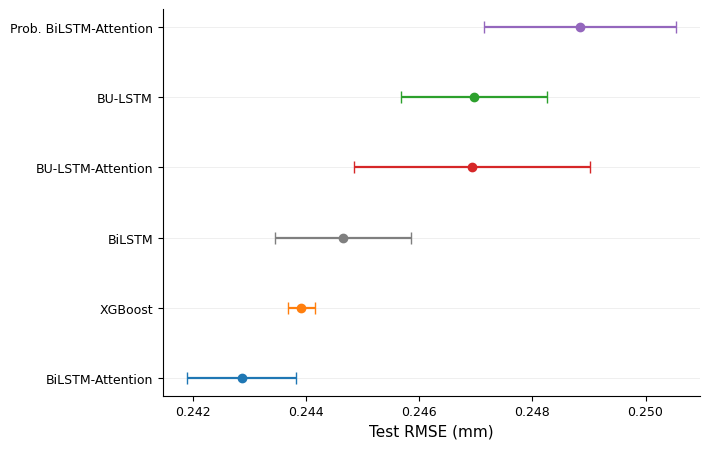

Saved: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.png
Saved: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.svg
Saved: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.pdf


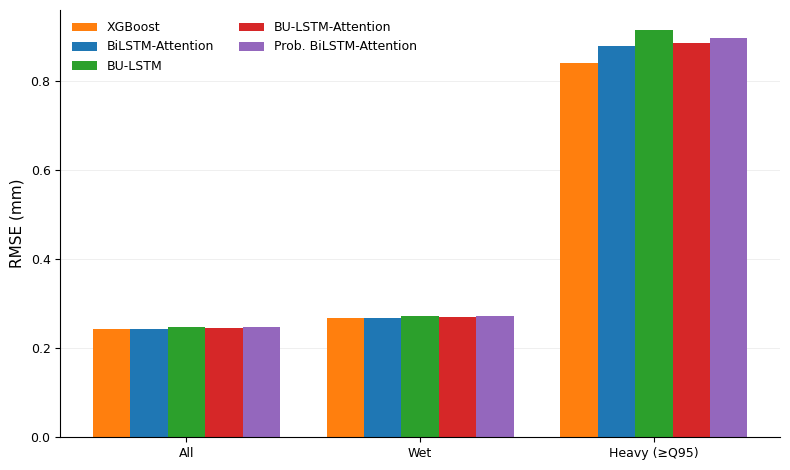

Saved: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.png
Saved: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.svg
Saved: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.pdf


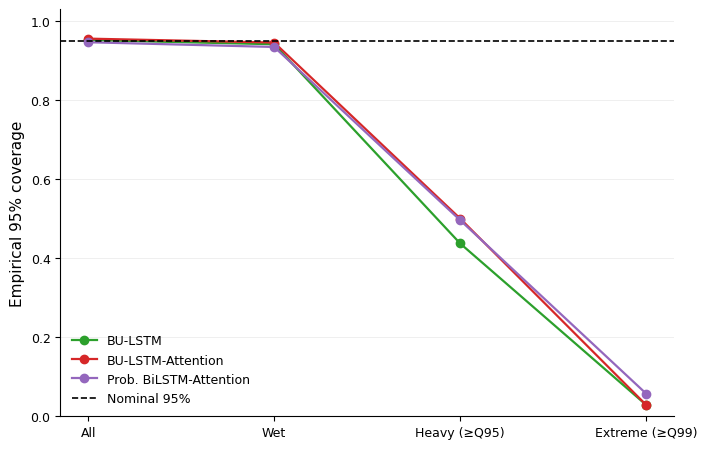

Saved: /root/autodl-tmp/results/final_figures/fig4_global_shap.png
Saved: /root/autodl-tmp/results/final_figures/fig4_global_shap.svg
Saved: /root/autodl-tmp/results/final_figures/fig4_global_shap.pdf


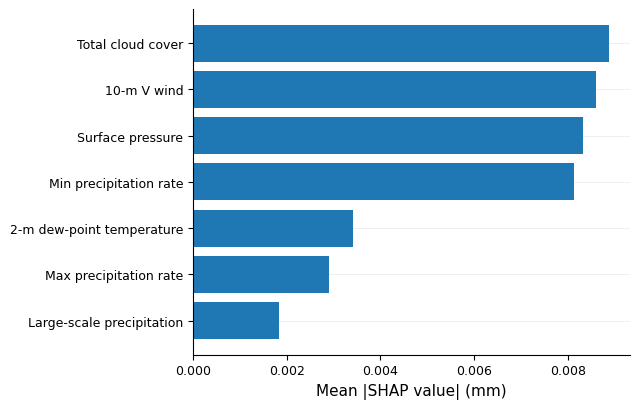

Saved: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.png
Saved: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.svg
Saved: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.pdf


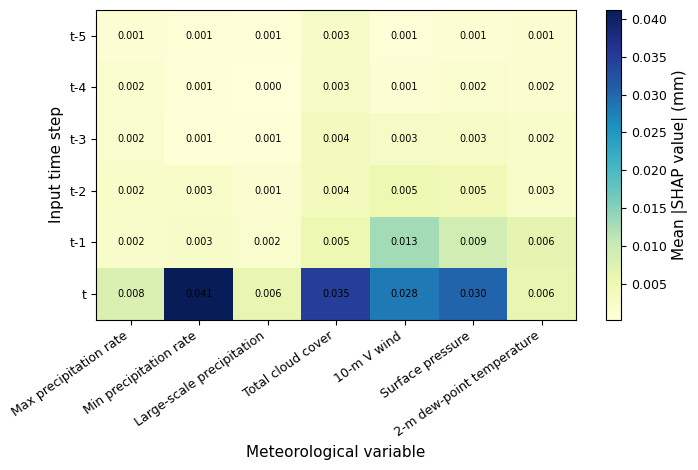

Saved: /root/autodl-tmp/results/final_figures/fig6_shap_summary.png
Saved: /root/autodl-tmp/results/final_figures/fig6_shap_summary.svg
Saved: /root/autodl-tmp/results/final_figures/fig6_shap_summary.pdf


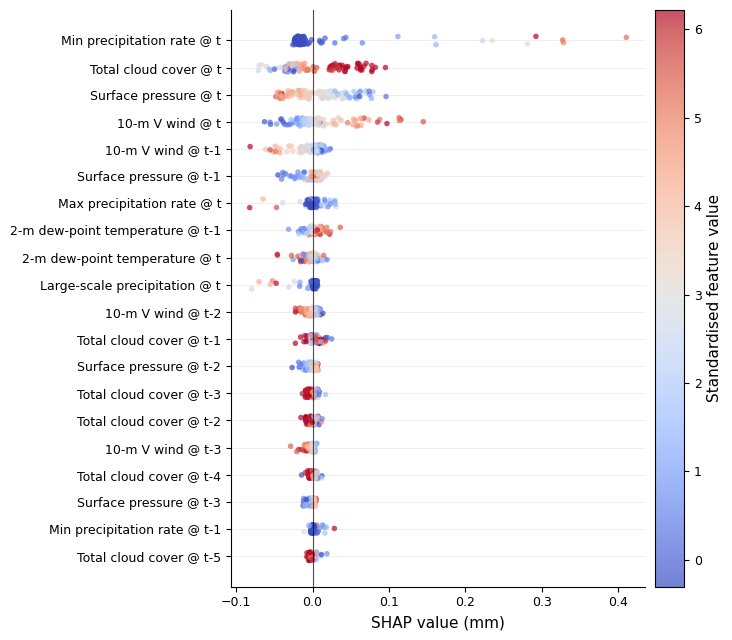


===== STEP 16 COMPLETE =====
All figures saved to:
/root/autodl-tmp/results/final_figures

Editable vector formats:
SVG + PDF

To change appearance later, modify only:
STYLE / COLORS / LABELS / FEATURE_LABELS


In [18]:
# # ============================================================
# # Step 16 — Final Paper Figures
# #
# # NO TRAINING
# # NO SHAP COMPUTATION
# #
# # Reads only final CSV / NPZ results.
# #
# # Figures:
# #
# # Fig 1 — 5-seed RMSE stability
# # Fig 2 — Rainfall-regime point performance
# # Fig 3 — Probabilistic coverage degradation
# # Fig 4 — Global SHAP importance
# # Fig 5 — Temporal SHAP heatmap
# # Fig 6 — SHAP summary
# #
# # All formatting is controlled through STYLE / COLORS / LABELS.
# #
# # Outputs:
# #   PNG  -> easy preview
# #   SVG  -> editable vector figure
# #   PDF  -> publication vector figure
# # ============================================================

# import os
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib as mpl


# # ============================================================
# # 1. STYLE CONFIG
# #
# # CHANGE THIS SECTION ONLY when editing figure appearance.
# # ============================================================

# STYLE = {

#     # ------------------------
#     # Output
#     # ------------------------
#     "output_dir":
#         "/root/autodl-tmp/results/final_figures",

#     "formats":
#         ["png", "svg", "pdf"],

#     "dpi":
#         400,


#     # ------------------------
#     # Font
#     # ------------------------
#     "font_family":
#         "DejaVu Sans",

#     # Example for journal:
#     # "font_family": "Times New Roman",

#     "font_size":
#         10,

#     "axis_label_size":
#         11,

#     "tick_size":
#         9,

#     "legend_size":
#         9,

#     "title_size":
#         11,


#     # ------------------------
#     # Figure sizes
#     # ------------------------
#     "figsize_rmse":
#         (7.2, 4.6),

#     "figsize_stratified":
#         (8.0, 4.8),

#     "figsize_coverage":
#         (7.2, 4.6),

#     "figsize_shap_bar":
#         (6.5, 4.2),

#     "figsize_shap_heatmap":
#         (7.2, 4.8),

#     "figsize_shap_summary":
#         (7.5, 6.5),


#     # ------------------------
#     # Lines / markers
#     # ------------------------
#     "line_width":
#         1.6,

#     "marker_size":
#         6,

#     "errorbar_capsize":
#         4,


#     # ------------------------
#     # Grid / axes
#     # ------------------------
#     "grid":
#         True,

#     "grid_alpha":
#         0.20,

#     "remove_top_right_spines":
#         True,


#     # ------------------------
#     # Titles
#     #
#     # Set False for most
#     # journal-ready figures.
#     # ------------------------
#     "show_titles":
#         False,


#     # ------------------------
#     # SHAP
#     # ------------------------
#     "heatmap_cmap":
#         "YlGnBu",

#     "shap_summary_cmap":
#         "coolwarm",

#     "shap_top_n":
#         20,

#     "heatmap_annotation":
#         True,

#     "heatmap_annotation_digits":
#         3
# }


# # ============================================================
# # 2. MODEL COLORS
# #
# # Change only here if you want different colours later.
# # ============================================================

# COLORS = {

#     "BiLSTM-Attention":
#         "#1f77b4",

#     "XGBoost":
#         "#ff7f0e",

#     "BiLSTM-NoAttention (control)":
#         "#7f7f7f",

#     "BU-LSTM-Attention (proposed)":
#         "#d62728",

#     "BU-LSTM":
#         "#2ca02c",

#     "Probabilistic BiLSTM-Attention":
#         "#9467bd",

#     "Persistence":
#         "#8c564b",

#     "Climatology":
#         "#bcbd22"
# }


# # ============================================================
# # 3. DISPLAY LABELS
# #
# # The data/model names do NOT change.
# # Only what appears on the figure changes here.
# # ============================================================

# LABELS = {

#     "BiLSTM-Attention":
#         "BiLSTM-Attention",

#     "XGBoost":
#         "XGBoost",

#     "BiLSTM-NoAttention (control)":
#         "BiLSTM",

#     "BU-LSTM-Attention (proposed)":
#         "BU-LSTM-Attention",

#     "BU-LSTM":
#         "BU-LSTM",

#     "Probabilistic BiLSTM-Attention":
#         "Prob. BiLSTM-Attention",

#     "Persistence":
#         "Persistence",

#     "Climatology":
#         "Climatology"
# }


# FEATURE_LABELS = {

#     "mxtpr":
#         "Max precipitation rate",

#     "mntpr":
#         "Min precipitation rate",

#     "lsp":
#         "Large-scale precipitation",

#     "tcc":
#         "Total cloud cover",

#     "v10":
#         "10-m V wind",

#     "sp":
#         "Surface pressure",

#     "d2m":
#         "2-m dew-point temperature"
# }


# REGIME_LABELS = {

#     "All":
#         "All",

#     "Wet":
#         "Wet",

#     "Heavy_Q95":
#         "Heavy (≥Q95)",

#     "Extreme_Q99":
#         "Extreme (≥Q99)"
# }


# # ============================================================
# # 4. Global matplotlib configuration
# # ============================================================

# mpl.rcParams.update({

#     "font.family":
#         STYLE["font_family"],

#     "font.size":
#         STYLE["font_size"],

#     "axes.labelsize":
#         STYLE["axis_label_size"],

#     "xtick.labelsize":
#         STYLE["tick_size"],

#     "ytick.labelsize":
#         STYLE["tick_size"],

#     "legend.fontsize":
#         STYLE["legend_size"],

#     "axes.titlesize":
#         STYLE["title_size"]
# })


# OUTPUT_DIR = STYLE[
#     "output_dir"
# ]


# os.makedirs(
#     OUTPUT_DIR,
#     exist_ok=True
# )


# # ============================================================
# # 5. Helper functions
# # ============================================================

# def clean_axes(ax):

#     if STYLE[
#         "remove_top_right_spines"
#     ]:

#         ax.spines[
#             "top"
#         ].set_visible(
#             False
#         )

#         ax.spines[
#             "right"
#         ].set_visible(
#             False
#         )


#     if STYLE[
#         "grid"
#     ]:

#         ax.grid(

#             axis="y",

#             alpha=
#                 STYLE[
#                     "grid_alpha"
#                 ],

#             linewidth=0.7
#         )

#         ax.set_axisbelow(
#             True
#         )


# def save_figure(
#     fig,
#     filename
# ):

#     for fmt in STYLE[
#         "formats"
#     ]:

#         path = os.path.join(

#             OUTPUT_DIR,

#             f"{filename}.{fmt}"
#         )


#         fig.savefig(

#             path,

#             dpi=
#                 STYLE[
#                     "dpi"
#                 ],

#             bbox_inches="tight"
#         )


#         print(
#             "Saved:",
#             path
#         )


#     plt.show()


# # ============================================================
# # 6. Load final result files
# # ============================================================

# METRIC_DIR = (
#     "/root/autodl-tmp/results/metrics"
# )

# SHAP_DIR = (
#     "/root/autodl-tmp/results/shap"
# )


# seed_point = pd.read_csv(

#     os.path.join(

#         METRIC_DIR,

#         "final_5seed_point.csv"
#     )
# )


# strat_point = pd.read_csv(

#     os.path.join(

#         METRIC_DIR,

#         "final_stratified_point.csv"
#     )
# )


# strat_prob = pd.read_csv(

#     os.path.join(

#         METRIC_DIR,

#         "final_stratified_probabilistic.csv"
#     )
# )


# shap_data = np.load(

#     os.path.join(

#         SHAP_DIR,

#         "shap_values_bilstm_attention_final.npz"
#     ),

#     allow_pickle=True
# )


# shap_values = shap_data[
#     "shap_values"
# ]


# X_explain = shap_data[
#     "X_explain"
# ]


# feature_names = [

#     str(x)

#     for x in shap_data[
#         "feature_names"
#     ]

# ]


# n_explain, n_timesteps, n_features = (
#     shap_values.shape
# )


# print(
#     "Loaded SHAP:",
#     shap_values.shape
# )


# # ============================================================
# # FIGURE 1
# # 5-seed RMSE stability
# #
# # Primary overall model comparison.
# # ============================================================

# def plot_fig1_rmse_stability():

#     df = seed_point.copy()


#     df = df.sort_values(

#         "RMSE_mean",

#         ascending=True
#     )


#     y = np.arange(
#         len(df)
#     )


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_rmse"
#             ]
#     )


#     for i, row in df.iterrows():

#         model = row[
#             "Model"
#         ]


#         ax.errorbar(

#             row[
#                 "RMSE_mean"
#             ],

#             y[
#                 list(
#                     df.index
#                 ).index(i)
#             ],

#             xerr=
#                 row[
#                     "RMSE_std"
#                 ],

#             fmt="o",

#             markersize=
#                 STYLE[
#                     "marker_size"
#                 ],

#             capsize=
#                 STYLE[
#                     "errorbar_capsize"
#                 ],

#             linewidth=
#                 STYLE[
#                     "line_width"
#                 ],

#             color=
#                 COLORS.get(
#                     model,
#                     "black"
#                 )
#         )


#     ax.set_yticks(
#         y
#     )


#     ax.set_yticklabels([

#         LABELS.get(
#             x,
#             x
#         )

#         for x in df[
#             "Model"
#         ]

#     ])


#     ax.set_xlabel(
#         "Test RMSE (mm)"
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "Five-seed point forecasting performance"
#         )


#     clean_axes(
#         ax
#     )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig1_5seed_rmse"
#     )


# # ============================================================
# # FIGURE 2
# # Stratified point forecasting
# #
# # MAIN paper:
# # All / Wet / Heavy Q95
# #
# # Q99 intentionally excluded from the main figure because
# # only 35 test samples are available.
# # ============================================================

# def plot_fig2_stratified_rmse():

#     regimes = [

#         "All",
#         "Wet",
#         "Heavy_Q95"
#     ]


#     models = [

#         "XGBoost",
#         "BiLSTM-Attention",
#         "BU-LSTM",
#         "BU-LSTM-Attention (proposed)",
#         "Probabilistic BiLSTM-Attention"
#     ]


#     df = strat_point[

#         strat_point[
#             "Regime"
#         ].isin(
#             regimes
#         )

#         &

#         strat_point[
#             "Model"
#         ].isin(
#             models
#         )

#     ].copy()


#     x = np.arange(
#         len(regimes)
#     )


#     width = (
#         0.80
#         /
#         len(models)
#     )


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_stratified"
#             ]
#     )


#     for i, model in enumerate(
#         models
#     ):

#         values = []


#         for regime in regimes:

#             value = df[

#                 (
#                     df[
#                         "Model"
#                     ]
#                     ==
#                     model
#                 )

#                 &

#                 (
#                     df[
#                         "Regime"
#                     ]
#                     ==
#                     regime
#                 )

#             ][
#                 "RMSE"
#             ].iloc[0]


#             values.append(
#                 value
#             )


#         offset = (

#             i
#             -
#             (
#                 len(models)
#                 -
#                 1
#             )
#             /
#             2

#         ) * width


#         ax.bar(

#             x
#             +
#             offset,

#             values,

#             width=
#                 width,

#             label=
#                 LABELS.get(
#                     model,
#                     model
#                 ),

#             color=
#                 COLORS.get(
#                     model
#                 )
#         )


#     ax.set_xticks(
#         x
#     )


#     ax.set_xticklabels([

#         REGIME_LABELS[
#             r
#         ]

#         for r in regimes

#     ])


#     ax.set_ylabel(
#         "RMSE (mm)"
#     )


#     ax.legend(

#         frameon=False,

#         ncol=2
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "Performance across precipitation regimes"
#         )


#     clean_axes(
#         ax
#     )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig2_stratified_rmse"
#     )


# # ============================================================
# # FIGURE 3
# # Coverage degradation:
# # All -> Wet -> Heavy -> Extreme
# #
# # This is one of the key findings of the revised experiment.
# # ============================================================

# def plot_fig3_coverage():

#     regimes = [

#         "All",
#         "Wet",
#         "Heavy_Q95",
#         "Extreme_Q99"
#     ]


#     models = [

#         "BU-LSTM",

#         "BU-LSTM-Attention (proposed)",

#         "Probabilistic BiLSTM-Attention"
#     ]


#     x = np.arange(
#         len(regimes)
#     )


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_coverage"
#             ]
#     )


#     for model in models:

#         values = []


#         for regime in regimes:

#             value = strat_prob[

#                 (
#                     strat_prob[
#                         "Model"
#                     ]
#                     ==
#                     model
#                 )

#                 &

#                 (
#                     strat_prob[
#                         "Regime"
#                     ]
#                     ==
#                     regime
#                 )

#             ][
#                 "Coverage95"
#             ].iloc[0]


#             values.append(
#                 value
#             )


#         ax.plot(

#             x,

#             values,

#             marker="o",

#             markersize=
#                 STYLE[
#                     "marker_size"
#                 ],

#             linewidth=
#                 STYLE[
#                     "line_width"
#                 ],

#             label=
#                 LABELS.get(
#                     model,
#                     model
#                 ),

#             color=
#                 COLORS.get(
#                     model
#                 )
#         )


#     # Nominal coverage
#     ax.axhline(

#         0.95,

#         linestyle="--",

#         linewidth=1.2,

#         color="black",

#         label="Nominal 95%"
#     )


#     ax.set_xticks(
#         x
#     )


#     ax.set_xticklabels([

#         REGIME_LABELS[
#             r
#         ]

#         for r in regimes

#     ])


#     ax.set_ylim(
#         0,
#         1.03
#     )


#     ax.set_ylabel(
#         "Empirical 95% coverage"
#     )


#     ax.legend(
#         frameon=False
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "Probabilistic coverage across rainfall regimes"
#         )


#     clean_axes(
#         ax
#     )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig3_probabilistic_coverage"
#     )


# # ============================================================
# # FIGURE 4
# # Global SHAP importance
# # ============================================================

# def plot_fig4_global_shap():

#     importance = np.mean(

#         np.abs(
#             shap_values
#         ),

#         axis=(
#             0,
#             1
#         )
#     )


#     order = np.argsort(
#         importance
#     )


#     values = importance[
#         order
#     ]


#     names = [

#         FEATURE_LABELS.get(
#             feature_names[i],
#             feature_names[i]
#         )

#         for i in order
#     ]


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_shap_bar"
#             ]
#     )


#     ax.barh(

#         names,

#         values,

#         color=
#             COLORS[
#                 "BiLSTM-Attention"
#             ]
#     )


#     ax.set_xlabel(
#         "Mean |SHAP value| (mm)"
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "Global feature importance"
#         )


#     clean_axes(
#         ax
#     )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig4_global_shap"
#     )


# # ============================================================
# # FIGURE 5
# # Temporal SHAP heatmap
# # ============================================================

# def plot_fig5_temporal_shap():

#     importance = np.mean(

#         np.abs(
#             shap_values
#         ),

#         axis=0
#     )


#     # Input sequence:
#     # t-5 ... t
#     #
#     # Last input is the most recent sampled state.
#     time_labels = [

#         f"t-{n_timesteps - 1 - i}"

#         if i
#         <
#         n_timesteps - 1

#         else
#         "t"

#         for i in range(
#             n_timesteps
#         )
#     ]


#     display_features = [

#         FEATURE_LABELS.get(
#             f,
#             f
#         )

#         for f in feature_names
#     ]


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_shap_heatmap"
#             ]
#     )


#     im = ax.imshow(

#         importance,

#         aspect="auto",

#         cmap=
#             STYLE[
#                 "heatmap_cmap"
#             ]
#     )


#     ax.set_xticks(
#         np.arange(
#             n_features
#         )
#     )


#     ax.set_xticklabels(

#         display_features,

#         rotation=35,

#         ha="right"
#     )


#     ax.set_yticks(
#         np.arange(
#             n_timesteps
#         )
#     )


#     ax.set_yticklabels(
#         time_labels
#     )


#     ax.set_xlabel(
#         "Meteorological variable"
#     )


#     ax.set_ylabel(
#         "Input time step"
#     )


#     if STYLE[
#         "heatmap_annotation"
#     ]:

#         digits = STYLE[
#             "heatmap_annotation_digits"
#         ]


#         for i in range(
#             n_timesteps
#         ):

#             for j in range(
#                 n_features
#             ):

#                 ax.text(

#                     j,

#                     i,

#                     f"{importance[i, j]:.{digits}f}",

#                     ha="center",

#                     va="center",

#                     fontsize=7
#                 )


#     cbar = fig.colorbar(

#         im,

#         ax=ax
#     )


#     cbar.set_label(
#         "Mean |SHAP value| (mm)"
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "Temporal feature importance"
#         )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig5_temporal_shap"
#     )


# # ============================================================
# # FIGURE 6
# # SHAP summary plot
# #
# # Each feature-time combination is treated separately.
# # ============================================================

# def plot_fig6_shap_summary():

#     flat_shap = shap_values.reshape(

#         n_explain,

#         -1
#     )


#     flat_X = X_explain.reshape(

#         n_explain,

#         -1
#     )


#     time_labels = [

#         f"t-{n_timesteps - 1 - i}"

#         if i
#         <
#         n_timesteps - 1

#         else
#         "t"

#         for i in range(
#             n_timesteps
#         )
#     ]


#     flat_names = []


#     for i in range(
#         n_timesteps
#     ):

#         for j in range(
#             n_features
#         ):

#             feature_label = FEATURE_LABELS.get(

#                 feature_names[
#                     j
#                 ],

#                 feature_names[
#                     j
#                 ]
#             )


#             flat_names.append(

#                 f"{feature_label} @ {time_labels[i]}"

#             )


#     mean_abs = np.mean(

#         np.abs(
#             flat_shap
#         ),

#         axis=0
#     )


#     top_n = min(

#         STYLE[
#             "shap_top_n"
#         ],

#         len(
#             mean_abs
#         )
#     )


#     top_idx = np.argsort(
#         mean_abs
#     )[
#         -top_n:
#     ]


#     fig, ax = plt.subplots(

#         figsize=
#             STYLE[
#                 "figsize_shap_summary"
#             ]
#     )


#     rng = np.random.default_rng(
#         42
#     )


#     scatter = None


#     for rank, idx in enumerate(
#         top_idx
#     ):

#         shap_row = flat_shap[
#             :,
#             idx
#         ]


#         feature_value = flat_X[
#             :,
#             idx
#         ]


#         jitter = rng.uniform(

#             -0.16,

#             0.16,

#             size=len(
#                 shap_row
#             )
#         )


#         scatter = ax.scatter(

#             shap_row,

#             rank
#             +
#             jitter,

#             c=
#                 feature_value,

#             cmap=
#                 STYLE[
#                     "shap_summary_cmap"
#                 ],

#             s=16,

#             alpha=0.70,

#             edgecolors="none"
#         )


#     ax.axvline(

#         0,

#         color="black",

#         linewidth=0.8,

#         alpha=0.7
#     )


#     ax.set_yticks(

#         np.arange(
#             top_n
#         )
#     )


#     ax.set_yticklabels([

#         flat_names[
#             i
#         ]

#         for i in top_idx

#     ])


#     ax.set_xlabel(
#         "SHAP value (mm)"
#     )


#     if STYLE[
#         "show_titles"
#     ]:

#         ax.set_title(
#             "SHAP summary"
#         )


#     cbar = fig.colorbar(

#         scatter,

#         ax=ax,

#         pad=0.02
#     )


#     cbar.set_label(
#         "Standardised feature value"
#     )


#     clean_axes(
#         ax
#     )


#     fig.tight_layout()


#     save_figure(

#         fig,

#         "fig6_shap_summary"
#     )


# # ============================================================
# # 7. Generate all final figures
# # ============================================================

# plot_fig1_rmse_stability()

# plot_fig2_stratified_rmse()

# plot_fig3_coverage()

# plot_fig4_global_shap()

# plot_fig5_temporal_shap()

# plot_fig6_shap_summary()


# print(
#     "\n===== STEP 16 COMPLETE ====="
# )

# print(
#     "All figures saved to:"
# )

# print(
#     OUTPUT_DIR
# )

# print(
#     "\nEditable vector formats:"
# )

# print(
#     "SVG + PDF"
# )

# print(
#     "\nTo change appearance later, modify only:"
# )

# print(
#     "STYLE / COLORS / LABELS / FEATURE_LABELS"
# )

In [4]:
# ============================================================
# Step 17 — Paired Bootstrap Robustness Test
#
# Kernel-restart safe:
#   - NO model loading
#   - NO training
#   - NO scaler
#   - Reads saved prediction CSV files only
#
# Purpose:
#   Test whether RMSE differences between
#   BiLSTM-Attention and XGBoost are robust.
#
# Regimes:
#   All
#   Wet          : y_true > 0
#   Heavy_Q95    : threshold from TRAIN y_true only
#
# Bootstrap:
#   Paired bootstrap
#   10,000 resamples
#   95% confidence interval
#
# Difference definition:
#
#   Delta RMSE =
#       RMSE(BiLSTM-Attention)
#       -
#       RMSE(XGBoost)
#
# Interpretation:
#
#   Delta < 0:
#       BiLSTM-Attention better
#
#   Delta > 0:
#       XGBoost better
#
# If 95% CI includes 0:
#       difference is not clearly distinguishable
#
# Outputs:
#   /root/autodl-tmp/results/metrics/
#       final_bootstrap_bilstm_vs_xgb.csv
# ============================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------
PRED_DIR = "/root/autodl-tmp/results/predictions"

METRICS_DIR = "/root/autodl-tmp/results/metrics"

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


BILSTM_PATH = os.path.join(
    PRED_DIR,
    "bilstm_attention_preds.csv"
)

XGB_PATH = os.path.join(
    PRED_DIR,
    "xgboost_preds.csv"
)


assert os.path.exists(BILSTM_PATH), BILSTM_PATH
assert os.path.exists(XGB_PATH), XGB_PATH


# ------------------------------------------------------------
# 1. Load prediction files
# ------------------------------------------------------------
bilstm = pd.read_csv(
    BILSTM_PATH
)

xgb = pd.read_csv(
    XGB_PATH
)


print("BiLSTM columns:")
print(bilstm.columns.tolist())

print("\nXGBoost columns:")
print(xgb.columns.tolist())


# ------------------------------------------------------------
# 2. Compute Heavy threshold from TRAIN ONLY
#
# Use BiLSTM file only as source of common y_true.
# ------------------------------------------------------------
train_ref = bilstm[
    bilstm["split"] == "train"
].copy()


Q95 = np.quantile(
    train_ref["y_true"].values,
    0.95
)


print(
    f"\nTrain-only Q95 = {Q95:.6f} mm"
)


# ------------------------------------------------------------
# 3. Extract TEST predictions
# ------------------------------------------------------------
b_test = bilstm[
    bilstm["split"] == "test"
].copy()

x_test = xgb[
    xgb["split"] == "test"
].copy()


# ------------------------------------------------------------
# 4. Align by valid_time if available
# ------------------------------------------------------------
if (
    "valid_time" in b_test.columns
    and
    "valid_time" in x_test.columns
):

    b_test["valid_time"] = pd.to_datetime(
        b_test["valid_time"]
    )

    x_test["valid_time"] = pd.to_datetime(
        x_test["valid_time"]
    )

    merged = b_test[
        [
            "valid_time",
            "y_true",
            "y_pred_mean"
        ]
    ].merge(

        x_test[
            [
                "valid_time",
                "y_true",
                "y_pred_mean"
            ]
        ],

        on="valid_time",

        suffixes=(
            "_bilstm",
            "_xgb"
        ),

        how="inner"
    )


    assert np.allclose(
        merged["y_true_bilstm"],
        merged["y_true_xgb"]
    )


    y_true = merged[
        "y_true_bilstm"
    ].values

    pred_bilstm = merged[
        "y_pred_mean_bilstm"
    ].values

    pred_xgb = merged[
        "y_pred_mean_xgb"
    ].values


else:

    assert len(b_test) == len(x_test)

    assert np.allclose(
        b_test["y_true"].values,
        x_test["y_true"].values
    )

    y_true = b_test[
        "y_true"
    ].values

    pred_bilstm = b_test[
        "y_pred_mean"
    ].values

    pred_xgb = x_test[
        "y_pred_mean"
    ].values


print(
    f"\nAligned test N = {len(y_true)}"
)


# ------------------------------------------------------------
# 5. Helper functions
# ------------------------------------------------------------
def rmse(y, pred):

    return np.sqrt(
        np.mean(
            (y - pred) ** 2
        )
    )


def regime_mask(
    y,
    regime
):

    if regime == "All":

        return np.ones(
            len(y),
            dtype=bool
        )

    elif regime == "Wet":

        return y > 0

    elif regime == "Heavy_Q95":

        return y >= Q95

    else:

        raise ValueError(
            regime
        )


# ------------------------------------------------------------
# 6. Paired bootstrap
# ------------------------------------------------------------
def paired_bootstrap_rmse_difference(
    y,
    pred_a,
    pred_b,
    n_boot=10000,
    seed=42
):

    """
    Difference:
        RMSE(A) - RMSE(B)

    Here:
        A = BiLSTM-Attention
        B = XGBoost
    """

    rng = np.random.default_rng(
        seed
    )


    n = len(y)


    observed_a = rmse(
        y,
        pred_a
    )

    observed_b = rmse(
        y,
        pred_b
    )

    observed_diff = (
        observed_a
        -
        observed_b
    )


    boot_diff = np.empty(
        n_boot
    )


    for i in range(
        n_boot
    ):

        idx = rng.integers(
            0,
            n,
            size=n
        )


        y_b = y[
            idx
        ]

        a_b = pred_a[
            idx
        ]

        b_b = pred_b[
            idx
        ]


        boot_diff[
            i
        ] = (

            rmse(
                y_b,
                a_b
            )

            -

            rmse(
                y_b,
                b_b
            )

        )


    ci_low = np.percentile(
        boot_diff,
        2.5
    )

    ci_high = np.percentile(
        boot_diff,
        97.5
    )


    # Bootstrap probability that
    # BiLSTM-Attention is better
    prob_bilstm_better = np.mean(
        boot_diff < 0
    )


    # Bootstrap probability that
    # XGBoost is better
    prob_xgb_better = np.mean(
        boot_diff > 0
    )


    return {

        "N":
            n,

        "RMSE_BiLSTM_Attention":
            observed_a,

        "RMSE_XGBoost":
            observed_b,

        "Delta_RMSE_BiLSTM_minus_XGB":
            observed_diff,

        "CI95_low":
            ci_low,

        "CI95_high":
            ci_high,

        "P_BiLSTM_better":
            prob_bilstm_better,

        "P_XGBoost_better":
            prob_xgb_better
    }


# ------------------------------------------------------------
# 7. Run by rainfall regime
# ------------------------------------------------------------
REGIMES = [
    "All",
    "Wet",
    "Heavy_Q95"
]


results = []


for regime in REGIMES:

    mask = regime_mask(
        y_true,
        regime
    )


    y_r = y_true[
        mask
    ]

    b_r = pred_bilstm[
        mask
    ]

    x_r = pred_xgb[
        mask
    ]


    result = paired_bootstrap_rmse_difference(

        y_r,
        b_r,
        x_r,

        n_boot=10000,

        seed=42
    )


    result[
        "Regime"
    ] = regime


    results.append(
        result
    )


# ------------------------------------------------------------
# 8. Results table
# ------------------------------------------------------------
df_results = pd.DataFrame(
    results
)


df_results = df_results[
    [
        "Regime",
        "N",
        "RMSE_BiLSTM_Attention",
        "RMSE_XGBoost",
        "Delta_RMSE_BiLSTM_minus_XGB",
        "CI95_low",
        "CI95_high",
        "P_BiLSTM_better",
        "P_XGBoost_better"
    ]
]


print(
    "\n"
    + "=" * 105
)

print(
    "STEP 17 — PAIRED BOOTSTRAP RESULTS"
)

print(
    "=" * 105
)


print(

    df_results.to_string(

        index=False,

        formatters={

            "RMSE_BiLSTM_Attention":
                lambda x: f"{x:.6f}",

            "RMSE_XGBoost":
                lambda x: f"{x:.6f}",

            "Delta_RMSE_BiLSTM_minus_XGB":
                lambda x: f"{x:.6f}",

            "CI95_low":
                lambda x: f"{x:.6f}",

            "CI95_high":
                lambda x: f"{x:.6f}",

            "P_BiLSTM_better":
                lambda x: f"{x:.4f}",

            "P_XGBoost_better":
                lambda x: f"{x:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 9. Automatic interpretation
# ------------------------------------------------------------
print(
    "\n"
    + "=" * 105
)

print(
    "INTERPRETATION"
)

print(
    "=" * 105
)


for _, row in df_results.iterrows():

    regime = row[
        "Regime"
    ]

    low = row[
        "CI95_low"
    ]

    high = row[
        "CI95_high"
    ]

    diff = row[
        "Delta_RMSE_BiLSTM_minus_XGB"
    ]


    print(
        f"\n{regime}:"
    )


    print(
        f"  Delta RMSE = {diff:.6f}"
    )

    print(
        f"  95% CI     = "
        f"[{low:.6f}, {high:.6f}]"
    )


    if high < 0:

        print(
            "  Conclusion: "
            "BiLSTM-Attention has lower RMSE "
            "with a bootstrap CI entirely below zero."
        )


    elif low > 0:

        print(
            "  Conclusion: "
            "XGBoost has lower RMSE "
            "with a bootstrap CI entirely above zero."
        )


    else:

        print(
            "  Conclusion: "
            "95% CI includes zero; "
            "the RMSE difference is not clearly distinguishable."
        )


# ------------------------------------------------------------
# 10. Save
# ------------------------------------------------------------
output_path = os.path.join(

    METRICS_DIR,

    "final_bootstrap_bilstm_vs_xgb.csv"
)


df_results.to_csv(
    output_path,
    index=False
)


print(
    "\n===== SAVED ====="
)

print(
    output_path
)


print(
    "\n===== STEP 17 COMPLETE ====="
)

BiLSTM columns:
['split', 'valid_time', 'y_true', 'y_pred_mean', 'y_pred_std']

XGBoost columns:
['split', 'valid_time', 'y_true', 'y_pred_mean', 'y_pred_std']

Train-only Q95 = 0.574048 mm

Aligned test N = 3939

STEP 17 — PAIRED BOOTSTRAP RESULTS
   Regime    N RMSE_BiLSTM_Attention RMSE_XGBoost Delta_RMSE_BiLSTM_minus_XGB  CI95_low CI95_high P_BiLSTM_better P_XGBoost_better
      All 3939              0.242848     0.243750                   -0.000902 -0.005148  0.003344          0.6756           0.3244
      Wet 3228              0.267166     0.267427                   -0.000261 -0.004929  0.004437          0.5570           0.4430
Heavy_Q95  238              0.878433     0.841656                    0.036777  0.021765  0.052976          0.0000           1.0000

INTERPRETATION

All:
  Delta RMSE = -0.000902
  95% CI     = [-0.005148, 0.003344]
  Conclusion: 95% CI includes zero; the RMSE difference is not clearly distinguishable.

Wet:
  Delta RMSE = -0.000261
  95% CI     = [-0.00492

In [5]:
# ============================================================
# Step 18 — Rainfall Threshold Sensitivity Analysis
#
# Kernel-restart safe:
#   - NO training
#   - NO model loading
#   - NO scaler needed
#   - Reads saved prediction CSV files only
#
# Thresholds:
#   Q90
#   Q95
#   Q97.5
#
# IMPORTANT:
#   All thresholds are calculated from TRAIN y_true ONLY.
#
# Point metrics:
#   RMSE
#   MAE
#
# Probabilistic metrics:
#   CRPS
#   Coverage95
#   MPIW95
#
# Outputs:
#   final_thresholds.csv
#   final_threshold_sensitivity_point.csv
#   final_threshold_sensitivity_probabilistic.csv
# ============================================================

import os
import numpy as np
import pandas as pd

from scipy.stats import norm


# ============================================================
# 0. Paths
# ============================================================

PRED_DIR = "/root/autodl-tmp/results/predictions"
METRICS_DIR = "/root/autodl-tmp/results/metrics"

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


# ============================================================
# 1. Model files
# ============================================================

MODEL_FILES = {

    "Persistence":
        "persistence_preds.csv",

    "Climatology":
        "climatology_preds.csv",

    "XGBoost":
        "xgboost_preds.csv",

    "BiLSTM-Attention":
        "bilstm_attention_preds.csv",

    "BU-LSTM":
        "bulstm_preds.csv",

    "BU-LSTM-Attention":
        "proposed_model_preds.csv",

    "Probabilistic BiLSTM-Attention":
        "prob_bilstm_attention_preds.csv",
}


PROB_MODELS = [

    "BU-LSTM",

    "BU-LSTM-Attention",

    "Probabilistic BiLSTM-Attention"
]


# ============================================================
# 2. Reference data
# ============================================================

reference_path = os.path.join(
    PRED_DIR,
    "bilstm_attention_preds.csv"
)

assert os.path.exists(reference_path)


reference = pd.read_csv(
    reference_path
)


train_ref = reference[
    reference["split"] == "train"
].copy()


test_ref = reference[
    reference["split"] == "test"
].copy()


train_y = train_ref[
    "y_true"
].values


test_y = test_ref[
    "y_true"
].values


# ============================================================
# 3. TRAIN-ONLY rainfall thresholds
# ============================================================

THRESHOLDS = {

    "Q90":
        np.quantile(
            train_y,
            0.90
        ),

    "Q95":
        np.quantile(
            train_y,
            0.95
        ),

    "Q97.5":
        np.quantile(
            train_y,
            0.975
        ),
}


print(
    "=" * 80
)

print(
    "STEP 18 — TRAIN-ONLY THRESHOLDS"
)

print(
    "=" * 80
)


threshold_rows = []


for name, value in THRESHOLDS.items():

    n_test = np.sum(
        test_y >= value
    )

    fraction = (
        n_test
        /
        len(test_y)
    )


    threshold_rows.append({

        "Threshold":
            name,

        "Threshold_mm":
            value,

        "Test_N":
            n_test,

        "Test_Fraction":
            fraction
    })


    print(
        f"{name:6s} = "
        f"{value:.6f} mm | "
        f"Test N = {n_test:4d} | "
        f"{100*fraction:.2f}%"
    )


df_thresholds = pd.DataFrame(
    threshold_rows
)


# ============================================================
# 4. Metric functions
# ============================================================

def rmse(
    y,
    pred
):

    return np.sqrt(

        np.mean(
            (y - pred) ** 2
        )

    )


def mae(
    y,
    pred
):

    return np.mean(

        np.abs(
            y - pred
        )

    )


def gaussian_crps(
    y,
    mu,
    sigma
):

    sigma = np.maximum(
        sigma,
        1e-8
    )


    z = (
        y - mu
    ) / sigma


    values = sigma * (

        z
        *
        (
            2 * norm.cdf(z)
            - 1
        )

        +

        2 * norm.pdf(z)

        -

        1 / np.sqrt(np.pi)

    )


    return np.mean(
        values
    )


def probabilistic_metrics(
    y,
    mu,
    sigma
):

    sigma = np.maximum(
        sigma,
        1e-8
    )


    z95 = 1.959963984540054


    lower = (
        mu
        -
        z95 * sigma
    )


    upper = (
        mu
        +
        z95 * sigma
    )


    coverage = np.mean(

        (y >= lower)
        &
        (y <= upper)

    )


    mpiw = np.mean(
        upper - lower
    )


    crps = gaussian_crps(
        y,
        mu,
        sigma
    )


    return {

        "CRPS":
            crps,

        "Coverage95":
            coverage,

        "MPIW95":
            mpiw,

        "MeanPredStd":
            np.mean(
                sigma
            )
    }


# ============================================================
# 5. Helper: align one model to reference TEST data
# ============================================================

def load_aligned_test(
    filename
):

    path = os.path.join(
        PRED_DIR,
        filename
    )


    if not os.path.exists(path):

        return None


    df = pd.read_csv(
        path
    )


    test = df[
        df["split"] == "test"
    ].copy()


    # ---------------------------------------------
    # Align by valid_time
    # ---------------------------------------------
    if (
        "valid_time" in test.columns
        and
        "valid_time" in test_ref.columns
    ):

        ref = test_ref[
            [
                "valid_time",
                "y_true"
            ]
        ].copy()


        ref["valid_time"] = pd.to_datetime(
            ref["valid_time"]
        )


        test["valid_time"] = pd.to_datetime(
            test["valid_time"]
        )


        merged = ref.merge(

            test,

            on="valid_time",

            suffixes=(
                "_ref",
                ""
            ),

            how="inner"
        )


        assert len(merged) == len(test_ref)


        assert np.allclose(

            merged[
                "y_true_ref"
            ].values,

            merged[
                "y_true"
            ].values
        )


        return merged


    else:

        assert len(test) == len(test_ref)

        assert np.allclose(

            test[
                "y_true"
            ].values,

            test_ref[
                "y_true"
            ].values
        )


        test[
            "y_true_ref"
        ] = test[
            "y_true"
        ]


        return test


# ============================================================
# 6. POINT forecasting threshold sensitivity
# ============================================================

point_rows = []


for model_name, filename in MODEL_FILES.items():

    df = load_aligned_test(
        filename
    )


    if df is None:

        print(
            f"WARNING — Missing: {filename}"
        )

        continue


    y_true = df[
        "y_true_ref"
    ].values


    pred = df[
        "y_pred_mean"
    ].values


    for threshold_name, threshold_value in THRESHOLDS.items():

        mask = (
            y_true
            >=
            threshold_value
        )


        y_subset = y_true[
            mask
        ]


        pred_subset = pred[
            mask
        ]


        point_rows.append({

            "Model":
                model_name,

            "Threshold":
                threshold_name,

            "Threshold_mm":
                threshold_value,

            "N":
                mask.sum(),

            "Fraction_of_Test":
                mask.mean(),

            "RMSE":
                rmse(
                    y_subset,
                    pred_subset
                ),

            "MAE":
                mae(
                    y_subset,
                    pred_subset
                )
        })


df_point = pd.DataFrame(
    point_rows
)


# ============================================================
# 7. Display POINT results
# ============================================================

print(
    "\n"
    + "=" * 95
)

print(
    "TABLE A — POINT PERFORMANCE BY RAINFALL THRESHOLD"
)

print(
    "=" * 95
)


for threshold_name in THRESHOLDS.keys():

    temp = df_point[
        df_point[
            "Threshold"
        ]
        ==
        threshold_name
    ].copy()


    temp = temp.sort_values(
        "RMSE"
    )


    print(
        f"\n===== {threshold_name} ====="
    )


    print(

        temp[
            [
                "Model",
                "N",
                "RMSE",
                "MAE"
            ]
        ].to_string(

            index=False,

            formatters={

                "RMSE":
                    lambda x: f"{x:.6f}",

                "MAE":
                    lambda x: f"{x:.6f}"
            }
        )
    )


# ============================================================
# 8. Probabilistic threshold sensitivity
# ============================================================

prob_rows = []


for model_name in PROB_MODELS:

    filename = MODEL_FILES[
        model_name
    ]


    df = load_aligned_test(
        filename
    )


    if df is None:

        continue


    y_true = df[
        "y_true_ref"
    ].values


    mu = df[
        "y_pred_mean"
    ].values


    sigma = df[
        "y_pred_std"
    ].values


    assert np.isfinite(
        sigma
    ).all()


    assert (
        sigma > 0
    ).all()


    for threshold_name, threshold_value in THRESHOLDS.items():

        mask = (
            y_true
            >=
            threshold_value
        )


        metrics = probabilistic_metrics(

            y_true[
                mask
            ],

            mu[
                mask
            ],

            sigma[
                mask
            ]
        )


        prob_rows.append({

            "Model":
                model_name,

            "Threshold":
                threshold_name,

            "Threshold_mm":
                threshold_value,

            "N":
                mask.sum(),

            "Fraction_of_Test":
                mask.mean(),

            **metrics
        })


df_prob = pd.DataFrame(
    prob_rows
)


# ============================================================
# 9. Display probabilistic results
# ============================================================

print(
    "\n"
    + "=" * 105
)

print(
    "TABLE B — PROBABILISTIC PERFORMANCE BY RAINFALL THRESHOLD"
)

print(
    "=" * 105
)


for threshold_name in THRESHOLDS.keys():

    temp = df_prob[
        df_prob[
            "Threshold"
        ]
        ==
        threshold_name
    ].copy()


    temp = temp.sort_values(
        "CRPS"
    )


    print(
        f"\n===== {threshold_name} ====="
    )


    print(

        temp[
            [
                "Model",
                "N",
                "CRPS",
                "Coverage95",
                "MPIW95",
                "MeanPredStd"
            ]
        ].to_string(

            index=False,

            formatters={

                "CRPS":
                    lambda x: f"{x:.6f}",

                "Coverage95":
                    lambda x: f"{x:.6f}",

                "MPIW95":
                    lambda x: f"{x:.6f}",

                "MeanPredStd":
                    lambda x: f"{x:.6f}"
            }
        )
    )


# ============================================================
# 10. Headline trend:
#     Coverage degradation with threshold
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "COVERAGE95 TREND"
)

print(
    "=" * 100
)


for model in PROB_MODELS:

    temp = df_prob[
        df_prob[
            "Model"
        ]
        ==
        model
    ].copy()


    values = []


    for threshold in [
        "Q90",
        "Q95",
        "Q97.5"
    ]:

        value = temp[
            temp[
                "Threshold"
            ]
            ==
            threshold
        ][
            "Coverage95"
        ].iloc[0]


        values.append(
            value
        )


    print(
        f"\n{model}"
    )


    print(
        "  Q90   : "
        f"{values[0]:.4f}"
    )

    print(
        "  Q95   : "
        f"{values[1]:.4f}"
    )

    print(
        "  Q97.5 : "
        f"{values[2]:.4f}"
    )


    if (
        values[0]
        >
        values[1]
        >
        values[2]
    ):

        print(
            "  Trend : MONOTONIC COVERAGE DEGRADATION"
        )

    else:

        print(
            "  Trend : NOT strictly monotonic"
        )


# ============================================================
# 11. XGBoost vs BiLSTM-Attention ranking
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "XGBOOST vs BiLSTM-ATTENTION"
)

print(
    "=" * 100
)


for threshold in [
    "Q90",
    "Q95",
    "Q97.5"
]:

    temp = df_point[
        df_point[
            "Threshold"
        ]
        ==
        threshold
    ]


    b = temp[
        temp[
            "Model"
        ]
        ==
        "BiLSTM-Attention"
    ][
        "RMSE"
    ].iloc[0]


    x = temp[
        temp[
            "Model"
        ]
        ==
        "XGBoost"
    ][
        "RMSE"
    ].iloc[0]


    delta = (
        b - x
    )


    winner = (
        "XGBoost"
        if delta > 0
        else
        "BiLSTM-Attention"
    )


    print(
        f"\n{threshold}:"
    )

    print(
        f"  BiLSTM-Attention = {b:.6f}"
    )

    print(
        f"  XGBoost          = {x:.6f}"
    )

    print(
        f"  Delta B-X        = {delta:.6f}"
    )

    print(
        f"  Lower RMSE       = {winner}"
    )


# ============================================================
# 12. Save
# ============================================================

threshold_path = os.path.join(
    METRICS_DIR,
    "final_thresholds.csv"
)

point_path = os.path.join(
    METRICS_DIR,
    "final_threshold_sensitivity_point.csv"
)

prob_path = os.path.join(
    METRICS_DIR,
    "final_threshold_sensitivity_probabilistic.csv"
)


df_thresholds.to_csv(
    threshold_path,
    index=False
)

df_point.to_csv(
    point_path,
    index=False
)

df_prob.to_csv(
    prob_path,
    index=False
)


print(
    "\n"
    + "=" * 80
)

print(
    "SAVED"
)

print(
    "=" * 80
)

print(
    threshold_path
)

print(
    point_path
)

print(
    prob_path
)


print(
    "\n===== STEP 18 COMPLETE ====="
)

STEP 18 — TRAIN-ONLY THRESHOLDS
Q90    = 0.295784 mm | Test N =  463 | 11.75%
Q95    = 0.574048 mm | Test N =  238 | 6.04%
Q97.5  = 0.932169 mm | Test N =  106 | 2.69%

TABLE A — POINT PERFORMANCE BY RAINFALL THRESHOLD

===== Q90 =====
                         Model   N     RMSE      MAE
                       XGBoost 463 0.626466 0.476809
              BiLSTM-Attention 463 0.652675 0.499120
             BU-LSTM-Attention 463 0.657790 0.502437
Probabilistic BiLSTM-Attention 463 0.667708 0.514401
                       BU-LSTM 463 0.680921 0.532856
                   Persistence 463 0.706487 0.548001
                   Climatology 463 0.755653 0.621278

===== Q95 =====
                         Model   N     RMSE      MAE
                       XGBoost 238 0.841656 0.728074
              BiLSTM-Attention 238 0.878433 0.771141
             BU-LSTM-Attention 238 0.885893 0.775402
Probabilistic BiLSTM-Attention 238 0.897982 0.790230
                   Persistence 238 0.904787 0.754911
     

In [6]:
# ============================================================
# Step 17B — Paired Block Bootstrap Robustness Test
#
# FINAL statistical robustness check
#
# Why block bootstrap?
#   Forecast errors are a time series and may be autocorrelated.
#   Instead of resampling individual timestamps independently,
#   we resample contiguous blocks of observations.
#
# Sampling interval:
#   6 hours
#
# Main block length:
#   28 samples = 7 days
#
# Models:
#   BiLSTM-Attention vs XGBoost
#
# Regimes:
#   All
#   Wet       : y_true > 0
#   Heavy_Q95 : y_true >= train-only Q95
#
# Delta RMSE:
#   RMSE(BiLSTM-Attention) - RMSE(XGBoost)
#
# Delta < 0 : BiLSTM-Attention better
# Delta > 0 : XGBoost better
#
# ============================================================

import os
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------

PRED_DIR = "/root/autodl-tmp/results/predictions"
METRICS_DIR = "/root/autodl-tmp/results/metrics"

os.makedirs(METRICS_DIR, exist_ok=True)

BILSTM_PATH = os.path.join(
    PRED_DIR,
    "bilstm_attention_preds.csv"
)

XGB_PATH = os.path.join(
    PRED_DIR,
    "xgboost_preds.csv"
)

assert os.path.exists(BILSTM_PATH)
assert os.path.exists(XGB_PATH)


# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

bilstm = pd.read_csv(BILSTM_PATH)
xgb = pd.read_csv(XGB_PATH)


# ------------------------------------------------------------
# 2. Train-only Q95 threshold
# ------------------------------------------------------------

train_ref = bilstm[
    bilstm["split"] == "train"
].copy()

Q95 = np.quantile(
    train_ref["y_true"],
    0.95
)

print(
    f"Train-only Q95 = {Q95:.6f} mm"
)


# ------------------------------------------------------------
# 3. Test data
# ------------------------------------------------------------

b_test = bilstm[
    bilstm["split"] == "test"
].copy()

x_test = xgb[
    xgb["split"] == "test"
].copy()


# Convert and sort by time
b_test["valid_time"] = pd.to_datetime(
    b_test["valid_time"]
)

x_test["valid_time"] = pd.to_datetime(
    x_test["valid_time"]
)

b_test = b_test.sort_values(
    "valid_time"
)

x_test = x_test.sort_values(
    "valid_time"
)


# ------------------------------------------------------------
# 4. Align models by valid_time
# ------------------------------------------------------------

merged = b_test[
    [
        "valid_time",
        "y_true",
        "y_pred_mean"
    ]
].merge(

    x_test[
        [
            "valid_time",
            "y_true",
            "y_pred_mean"
        ]
    ],

    on="valid_time",

    suffixes=(
        "_bilstm",
        "_xgb"
    ),

    how="inner"
)


assert np.allclose(
    merged["y_true_bilstm"],
    merged["y_true_xgb"]
)


y_true = merged[
    "y_true_bilstm"
].to_numpy()

pred_bilstm = merged[
    "y_pred_mean_bilstm"
].to_numpy()

pred_xgb = merged[
    "y_pred_mean_xgb"
].to_numpy()


N = len(y_true)

print(
    f"Aligned Test N = {N}"
)


# ------------------------------------------------------------
# 5. Metric
# ------------------------------------------------------------

def rmse(y, pred):

    return np.sqrt(
        np.mean(
            (y - pred) ** 2
        )
    )


# ------------------------------------------------------------
# 6. Regime mask
# ------------------------------------------------------------

def get_mask(y, regime):

    if regime == "All":

        return np.ones(
            len(y),
            dtype=bool
        )

    elif regime == "Wet":

        return y > 0

    elif regime == "Heavy_Q95":

        return y >= Q95

    else:

        raise ValueError(regime)


# ------------------------------------------------------------
# 7. Circular block bootstrap indices
#
# Each replicate:
#   randomly choose starting points
#   take continuous blocks of length BLOCK_LENGTH
#   concatenate until original sample length is reached
#
# Same indices are applied to BOTH models:
#   therefore this is paired.
# ------------------------------------------------------------

def circular_block_indices(
    n,
    block_length,
    rng
):

    n_blocks = int(
        np.ceil(
            n / block_length
        )
    )

    starts = rng.integers(
        0,
        n,
        size=n_blocks
    )

    indices = []

    for start in starts:

        block = (
            start
            +
            np.arange(block_length)
        ) % n

        indices.extend(block)


    return np.asarray(
        indices[:n]
    )


# ------------------------------------------------------------
# 8. Paired block bootstrap
# ------------------------------------------------------------

def paired_block_bootstrap(
    y,
    pred_a,
    pred_b,
    regime,
    block_length=28,
    n_boot=10000,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )


    # -----------------------------
    # Observed result
    # -----------------------------

    original_mask = get_mask(
        y,
        regime
    )


    obs_y = y[
        original_mask
    ]

    obs_a = pred_a[
        original_mask
    ]

    obs_b = pred_b[
        original_mask
    ]


    rmse_a = rmse(
        obs_y,
        obs_a
    )

    rmse_b = rmse(
        obs_y,
        obs_b
    )

    observed_diff = (
        rmse_a - rmse_b
    )


    # -----------------------------
    # Bootstrap
    # -----------------------------

    boot_diffs = []

    regime_sizes = []


    for _ in range(n_boot):

        idx = circular_block_indices(

            len(y),

            block_length,

            rng
        )


        y_boot = y[idx]

        a_boot = pred_a[idx]

        b_boot = pred_b[idx]


        # IMPORTANT:
        # apply rainfall regime AFTER
        # block resampling the full timeline

        mask = get_mask(
            y_boot,
            regime
        )


        n_regime = mask.sum()


        # Safety for rare regimes
        if n_regime < 2:

            continue


        regime_sizes.append(
            n_regime
        )


        diff = (

            rmse(
                y_boot[mask],
                a_boot[mask]
            )

            -

            rmse(
                y_boot[mask],
                b_boot[mask]
            )

        )


        boot_diffs.append(
            diff
        )


    boot_diffs = np.asarray(
        boot_diffs
    )


    ci_low = np.percentile(
        boot_diffs,
        2.5
    )

    ci_high = np.percentile(
        boot_diffs,
        97.5
    )


    p_bilstm_better = np.mean(
        boot_diffs < 0
    )

    p_xgb_better = np.mean(
        boot_diffs > 0
    )


    return {

        "Regime":
            regime,

        "Observed_N":
            original_mask.sum(),

        "Block_Length":
            block_length,

        "Block_Length_Days":
            block_length * 6 / 24,

        "Valid_Bootstrap_Runs":
            len(boot_diffs),

        "Mean_Bootstrap_Regime_N":
            np.mean(regime_sizes),

        "RMSE_BiLSTM_Attention":
            rmse_a,

        "RMSE_XGBoost":
            rmse_b,

        "Delta_RMSE_BiLSTM_minus_XGB":
            observed_diff,

        "CI95_low":
            ci_low,

        "CI95_high":
            ci_high,

        "P_BiLSTM_better":
            p_bilstm_better,

        "P_XGBoost_better":
            p_xgb_better
    }


# ------------------------------------------------------------
# 9. Run
# ------------------------------------------------------------

BLOCK_LENGTH = 28     # 28 × 6 h = 7 days
N_BOOT = 10000


REGIMES = [
    "All",
    "Wet",
    "Heavy_Q95"
]


results = []


for regime in REGIMES:

    result = paired_block_bootstrap(

        y_true,

        pred_bilstm,

        pred_xgb,

        regime=regime,

        block_length=BLOCK_LENGTH,

        n_boot=N_BOOT,

        seed=42
    )

    results.append(
        result
    )


df_results = pd.DataFrame(
    results
)


# ------------------------------------------------------------
# 10. Print results
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 115
)

print(
    "STEP 17B — PAIRED BLOCK BOOTSTRAP"
)

print(
    "=" * 115
)


display_cols = [

    "Regime",

    "Observed_N",

    "RMSE_BiLSTM_Attention",

    "RMSE_XGBoost",

    "Delta_RMSE_BiLSTM_minus_XGB",

    "CI95_low",

    "CI95_high",

    "P_BiLSTM_better",

    "P_XGBoost_better"
]


print(

    df_results[
        display_cols
    ].to_string(

        index=False,

        formatters={

            "RMSE_BiLSTM_Attention":
                lambda x: f"{x:.6f}",

            "RMSE_XGBoost":
                lambda x: f"{x:.6f}",

            "Delta_RMSE_BiLSTM_minus_XGB":
                lambda x: f"{x:.6f}",

            "CI95_low":
                lambda x: f"{x:.6f}",

            "CI95_high":
                lambda x: f"{x:.6f}",

            "P_BiLSTM_better":
                lambda x: f"{x:.4f}",

            "P_XGBoost_better":
                lambda x: f"{x:.4f}"
        }
    )
)


# ------------------------------------------------------------
# 11. Interpretation
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 115
)

print(
    "INTERPRETATION"
)

print(
    "=" * 115
)


for _, row in df_results.iterrows():

    print(
        f"\n{row['Regime']}:"
    )

    print(
        f"  Delta RMSE = "
        f"{row['Delta_RMSE_BiLSTM_minus_XGB']:.6f}"
    )

    print(
        f"  95% CI = "
        f"[{row['CI95_low']:.6f}, "
        f"{row['CI95_high']:.6f}]"
    )


    if row["CI95_high"] < 0:

        print(
            "  Conclusion: "
            "BiLSTM-Attention has robustly lower RMSE."
        )

    elif row["CI95_low"] > 0:

        print(
            "  Conclusion: "
            "XGBoost has robustly lower RMSE."
        )

    else:

        print(
            "  Conclusion: "
            "CI includes zero; "
            "the models are not clearly distinguishable."
        )


# ------------------------------------------------------------
# 12. Save
# ------------------------------------------------------------

output_path = os.path.join(

    METRICS_DIR,

    "final_block_bootstrap_bilstm_vs_xgb.csv"
)


df_results.to_csv(
    output_path,
    index=False
)


print(
    "\n===== SAVED ====="
)

print(
    output_path
)

print(
    "\n===== STEP 17B COMPLETE ====="
)

Train-only Q95 = 0.574048 mm
Aligned Test N = 3939

STEP 17B — PAIRED BLOCK BOOTSTRAP
   Regime  Observed_N RMSE_BiLSTM_Attention RMSE_XGBoost Delta_RMSE_BiLSTM_minus_XGB  CI95_low CI95_high P_BiLSTM_better P_XGBoost_better
      All        3939              0.242848     0.243750                   -0.000902 -0.004913  0.003286          0.6726           0.3274
      Wet        3228              0.267166     0.267427                   -0.000261 -0.004604  0.004306          0.5548           0.4452
Heavy_Q95         238              0.878433     0.841656                    0.036777  0.019030  0.055429          0.0000           1.0000

INTERPRETATION

All:
  Delta RMSE = -0.000902
  95% CI = [-0.004913, 0.003286]
  Conclusion: CI includes zero; the models are not clearly distinguishable.

Wet:
  Delta RMSE = -0.000261
  95% CI = [-0.004604, 0.004306]
  Conclusion: CI includes zero; the models are not clearly distinguishable.

Heavy_Q95:
  Delta RMSE = 0.036777
  95% CI = [0.019030, 0.055429

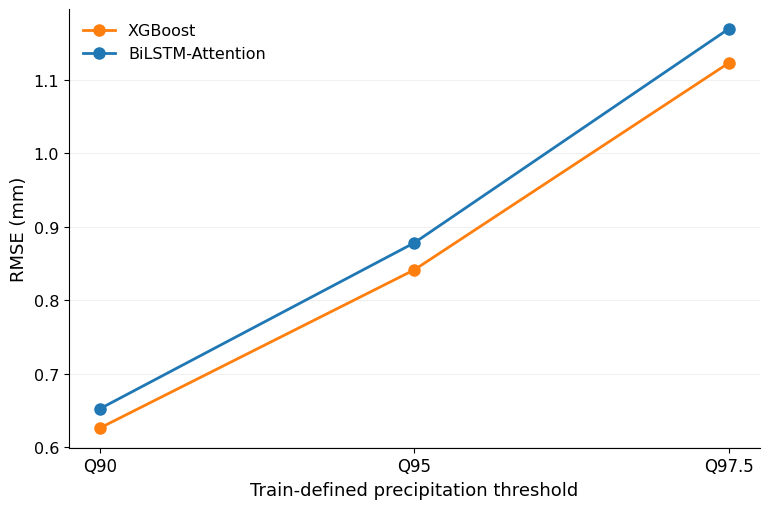

Saved fig7_threshold_rmse


In [25]:
# ============================================================
# Figure 7 — Threshold RMSE
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1–6
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent model colours
# - Train-defined threshold wording
#
# OVERWRITES:
# fig7_threshold_rmse.*
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

METRICS_DIR = "/root/autodl-tmp/results/metrics"
FIG_DIR = "/root/autodl-tmp/results/final_figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

# ============================================================
# 1. Load data
# ============================================================

df = pd.read_csv(
    os.path.join(
        METRICS_DIR,
        "final_threshold_sensitivity_point.csv"
    )
)

models = [
    "XGBoost",
    "BiLSTM-Attention"
]

thresholds = [
    "Q90",
    "Q95",
    "Q97.5"
]

# Consistent colours used throughout the paper
MODEL_COLORS = {
    "XGBoost": "#ff7f0e",
    "BiLSTM-Attention": "#1f77b4"
}

# ============================================================
# 2. Filter and order thresholds
# ============================================================

df = df[
    df["Model"].isin(models)
].copy()

df["Threshold"] = pd.Categorical(
    df["Threshold"],
    categories=thresholds,
    ordered=True
)

# ============================================================
# 3. Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.8, 5.2)
)

# ============================================================
# 4. Model lines
# ============================================================

for model in models:

    temp = df[
        df["Model"] == model
    ].sort_values(
        "Threshold"
    )

    ax.plot(
        temp["Threshold"],
        temp["RMSE"],
        marker="o",
        markersize=8,
        linewidth=2.0,
        color=MODEL_COLORS[model],
        markerfacecolor=MODEL_COLORS[model],
        markeredgecolor=MODEL_COLORS[model],
        label=model
    )

# ============================================================
# 5. Axes
# ============================================================

ax.set_xlabel(
    "Train-defined precipitation threshold",
    fontsize=13
)

ax.set_ylabel(
    "RMSE (mm)",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=12
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)

# ============================================================
# 6. Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=11.5
)

# ============================================================
# 7. Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)

# No title inside figure

fig.tight_layout()

# ============================================================
# 8. Save — overwrite original
# ============================================================

base = os.path.join(
    FIG_DIR,
    "fig7_threshold_rmse"
)

fig.savefig(
    base + ".svg",
    bbox_inches="tight"
)

fig.savefig(
    base + ".pdf",
    bbox_inches="tight"
)

fig.savefig(
    base + ".png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved fig7_threshold_rmse"
)

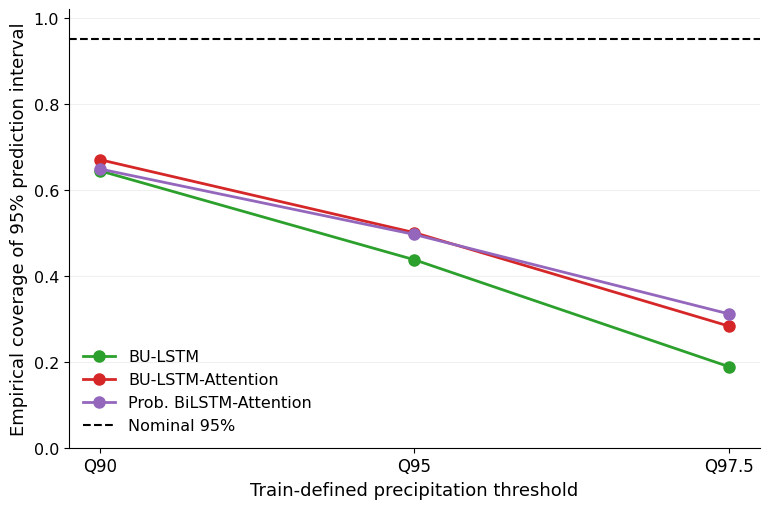

Saved fig8_threshold_coverage


In [26]:
# ============================================================
# Figure 8 — Threshold Coverage
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1–7
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent probabilistic model colours
# - Black nominal-coverage reference line
# - Train-defined threshold wording
#
# OVERWRITES:
# fig8_threshold_coverage.*
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

METRICS_DIR = "/root/autodl-tmp/results/metrics"
FIG_DIR = "/root/autodl-tmp/results/final_figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

# ============================================================
# 1. Load data
# ============================================================

df = pd.read_csv(
    os.path.join(
        METRICS_DIR,
        "final_threshold_sensitivity_probabilistic.csv"
    )
)

models = [
    "BU-LSTM",
    "BU-LSTM-Attention",
    "Probabilistic BiLSTM-Attention"
]

thresholds = [
    "Q90",
    "Q95",
    "Q97.5"
]

# Consistent colours used throughout the paper
MODEL_COLORS = {
    "BU-LSTM": "#2ca02c",
    "BU-LSTM-Attention": "#d62728",
    "Probabilistic BiLSTM-Attention": "#9467bd"
}

# Optional shorter display labels
MODEL_LABELS = {
    "BU-LSTM": "BU-LSTM",
    "BU-LSTM-Attention": "BU-LSTM-Attention",
    "Probabilistic BiLSTM-Attention": "Prob. BiLSTM-Attention"
}

# ============================================================
# 2. Filter and order thresholds
# ============================================================

df = df[
    df["Model"].isin(models)
].copy()

df["Threshold"] = pd.Categorical(
    df["Threshold"],
    categories=thresholds,
    ordered=True
)

# ============================================================
# 3. Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.8, 5.2)
)

# ============================================================
# 4. Model lines
# ============================================================

for model in models:

    temp = df[
        df["Model"] == model
    ].sort_values(
        "Threshold"
    )

    color = MODEL_COLORS[model]

    ax.plot(
        temp["Threshold"],
        temp["Coverage95"],
        marker="o",
        markersize=8,
        linewidth=2.0,
        color=color,
        markerfacecolor=color,
        markeredgecolor=color,
        label=MODEL_LABELS[model]
    )

# ============================================================
# 5. Nominal 95% coverage
# ============================================================

ax.axhline(
    y=0.95,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Nominal 95%"
)

# ============================================================
# 6. Axes
# ============================================================

ax.set_ylim(
    0,
    1.02
)

ax.set_xlabel(
    "Train-defined precipitation threshold",
    fontsize=13
)

ax.set_ylabel(
    "Empirical coverage of 95% prediction interval",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=12
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)

# ============================================================
# 7. Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=11.5,
    loc="lower left"
)

# ============================================================
# 8. Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)

# No title inside figure

fig.tight_layout()

# ============================================================
# 9. Save — overwrite original
# ============================================================

base = os.path.join(
    FIG_DIR,
    "fig8_threshold_coverage"
)

fig.savefig(
    base + ".svg",
    bbox_inches="tight"
)

fig.savefig(
    base + ".pdf",
    bbox_inches="tight"
)

fig.savefig(
    base + ".png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved fig8_threshold_coverage"
)

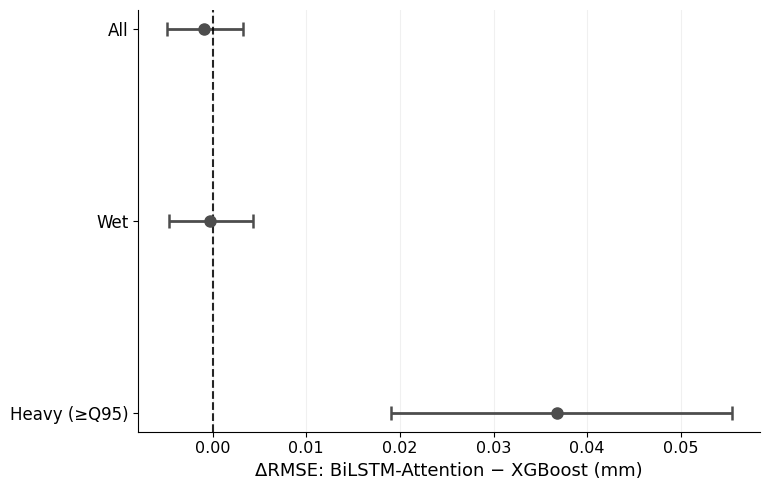

Saved fig9_block_bootstrap


In [27]:
# ============================================================
# Figure 9 — Paired Block Bootstrap
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1–8
# - Larger journal-readable fonts
# - No in-figure title
# - Clear regime labels
# - Black zero-reference line
# - Neutral CI point colour
#
# OVERWRITES:
# fig9_block_bootstrap.*
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

METRICS_DIR = "/root/autodl-tmp/results/metrics"
FIG_DIR = "/root/autodl-tmp/results/final_figures"

os.makedirs(
    FIG_DIR,
    exist_ok=True
)

# ============================================================
# 1. Load data
# ============================================================

df = pd.read_csv(
    os.path.join(
        METRICS_DIR,
        "final_block_bootstrap_bilstm_vs_xgb.csv"
    )
)

# Desired bottom-to-top plotting order:
# Heavy -> Wet -> All
# so All appears visually at the top
order = [
    "Heavy_Q95",
    "Wet",
    "All"
]

df["Regime"] = pd.Categorical(
    df["Regime"],
    categories=order,
    ordered=True
)

df = df.sort_values(
    "Regime"
).reset_index(drop=True)

# ============================================================
# 2. Bootstrap estimates
# ============================================================

delta = df[
    "Delta_RMSE_BiLSTM_minus_XGB"
].values

ci_low = df[
    "CI95_low"
].values

ci_high = df[
    "CI95_high"
].values

xerr = [
    delta - ci_low,
    ci_high - delta
]

# Cleaner display labels
REGIME_DISPLAY = {
    "All": "All",
    "Wet": "Wet",
    "Heavy_Q95": "Heavy (≥Q95)"
}

y_labels = [
    REGIME_DISPLAY.get(
        regime,
        regime
    )
    for regime in df["Regime"].astype(str)
]

# ============================================================
# 3. Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.8, 5.0)
)

# ============================================================
# 4. Bootstrap estimate and 95% CI
# ============================================================

ax.errorbar(
    delta,
    range(len(df)),
    xerr=xerr,

    fmt="o",

    markersize=8,

    capsize=5,
    capthick=1.8,

    elinewidth=2.0,

    color="#4d4d4d",

    markerfacecolor="#4d4d4d",
    markeredgecolor="#4d4d4d"
)

# ============================================================
# 5. Zero-reference line
# ============================================================

ax.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.85
)

# ============================================================
# 6. Y axis
# ============================================================

ax.set_yticks(
    range(len(df))
)

ax.set_yticklabels(
    y_labels,
    fontsize=12
)

ax.set_ylabel("")

# ============================================================
# 7. X axis
# ============================================================

ax.set_xlabel(
    "ΔRMSE: BiLSTM-Attention − XGBoost (mm)",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=11.5
)

# ============================================================
# 8. Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)

# No title inside figure

fig.tight_layout()

# ============================================================
# 9. Save — overwrite original
# ============================================================

base = os.path.join(
    FIG_DIR,
    "fig9_block_bootstrap"
)

fig.savefig(
    base + ".svg",
    bbox_inches="tight"
)

fig.savefig(
    base + ".pdf",
    bbox_inches="tight"
)

fig.savefig(
    base + ".png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(
    "Saved fig9_block_bootstrap"
)

In [10]:
# ============================================================
# Step 16R — Common setup for revised final figures
#
# NO TRAINING
# NO SHAP COMPUTATION
#
# Run this cell ONCE.
# Then Fig.3 / Fig.4 / Fig.5 / Fig.6 can be redrawn separately.
#
# Existing files will be OVERWRITTEN because the same filenames
# are used.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


# ============================================================
# 1. Paths
# ============================================================

METRIC_DIR = "/root/autodl-tmp/results/metrics"
SHAP_DIR = "/root/autodl-tmp/results/shap"

OUTPUT_DIR = "/root/autodl-tmp/results/final_figures"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. Output configuration
# ============================================================

FORMATS = [
    "png",
    "svg",
    "pdf"
]

DPI = 400


# ============================================================
# 3. Figure style
# ============================================================

mpl.rcParams.update({

    "font.family":
        "DejaVu Sans",

    "font.size":
        10,

    "axes.labelsize":
        11,

    "xtick.labelsize":
        9,

    "ytick.labelsize":
        9,

    "legend.fontsize":
        9,

    "axes.titlesize":
        11
})


# ============================================================
# 4. Colours
# ============================================================

COLORS = {

    "BiLSTM-Attention":
        "#1f77b4",

    "XGBoost":
        "#ff7f0e",

    "BiLSTM-NoAttention (control)":
        "#7f7f7f",

    "BU-LSTM-Attention (proposed)":
        "#d62728",

    "BU-LSTM":
        "#2ca02c",

    "Probabilistic BiLSTM-Attention":
        "#9467bd",

    "Persistence":
        "#8c564b",

    "Climatology":
        "#bcbd22"
}


# ============================================================
# 5. Display labels
# ============================================================

LABELS = {

    "BiLSTM-Attention":
        "BiLSTM-Attention",

    "XGBoost":
        "XGBoost",

    "BiLSTM-NoAttention (control)":
        "BiLSTM",

    "BU-LSTM-Attention (proposed)":
        "BU-LSTM-Attention",

    "BU-LSTM":
        "BU-LSTM",

    "Probabilistic BiLSTM-Attention":
        "Prob. BiLSTM-Attention",

    "Persistence":
        "Persistence",

    "Climatology":
        "Climatology"
}


FEATURE_LABELS = {

    "mxtpr":
        "Max precipitation rate",

    "mntpr":
        "Min precipitation rate",

    "lsp":
        "Large-scale precipitation",

    "tcc":
        "Total cloud cover",

    # IMPORTANT:
    # v10 is the meridional wind component,
    # NOT wind speed.
    "v10":
        "10-m meridional wind (v10)",

    "sp":
        "Surface pressure",

    "d2m":
        "2-m dew-point temperature"
}


REGIME_LABELS = {

    "All":
        "All",

    "Wet":
        "Wet",

    "Heavy_Q95":
        "Heavy (≥Q95)",

    "Extreme_Q99":
        "Extreme (≥Q99)"
}


# ============================================================
# 6. Helper functions
# ============================================================

def clean_axes(ax, grid_axis="y"):

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.grid(
        axis=grid_axis,
        alpha=0.20,
        linewidth=0.7
    )

    ax.set_axisbelow(
        True
    )


def save_figure(
    fig,
    filename
):

    for fmt in FORMATS:

        path = os.path.join(
            OUTPUT_DIR,
            f"{filename}.{fmt}"
        )

        fig.savefig(
            path,
            dpi=DPI,
            bbox_inches="tight"
        )

        print(
            "OVERWRITTEN:",
            path
        )

    plt.show()
    plt.close(fig)


# ============================================================
# 7. Load probabilistic stratified results
# ============================================================

strat_prob = pd.read_csv(

    os.path.join(
        METRIC_DIR,
        "final_stratified_probabilistic.csv"
    )
)


# ============================================================
# 8. Load saved SHAP results
# ============================================================

shap_data = np.load(

    os.path.join(
        SHAP_DIR,
        "shap_values_bilstm_attention_final.npz"
    ),

    allow_pickle=True
)


shap_values = shap_data[
    "shap_values"
]


X_explain = shap_data[
    "X_explain"
]


feature_names = [

    str(x)

    for x in shap_data[
        "feature_names"
    ]
]


n_explain, n_timesteps, n_features = (
    shap_values.shape
)


# ------------------------------------------------------------
# True temporal spacing:
#
# Six input states sampled every 6 hours:
#
# t−30 h, t−24 h, t−18 h,
# t−12 h, t−6 h, t
# ------------------------------------------------------------

time_labels = [

    (
        f"t−{(n_timesteps - 1 - i) * 6} h"
        if i < n_timesteps - 1
        else "t"
    )

    for i in range(
        n_timesteps
    )
]


print(
    "Loaded SHAP shape:",
    shap_values.shape
)

print(
    "Time labels:",
    time_labels
)

print(
    "\nCommon setup complete."
)

Loaded SHAP shape: (100, 6, 7)
Time labels: ['t−30 h', 't−24 h', 't−18 h', 't−12 h', 't−6 h', 't']

Common setup complete.


OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig3_probabilistic_coverage.pdf


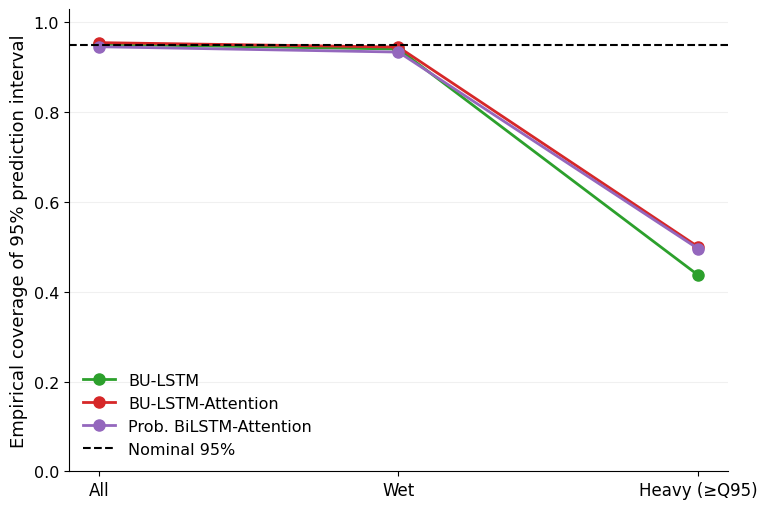

In [21]:
# ============================================================
# Figure 3 — Probabilistic coverage across precipitation regimes
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1 / Fig. 2
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent model colours
# - Q99 excluded from main figure
#
# OVERWRITES:
# fig3_probabilistic_coverage.*
# ============================================================

regimes = [
    "All",
    "Wet",
    "Heavy_Q95"
]

models = [
    "BU-LSTM",
    "BU-LSTM-Attention (proposed)",
    "Probabilistic BiLSTM-Attention"
]

x = np.arange(
    len(regimes)
)

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.8, 5.2)
)

# ============================================================
# Model lines
# ============================================================

for model in models:

    values = []

    for regime in regimes:

        temp = strat_prob[
            (
                strat_prob["Model"] == model
            )
            &
            (
                strat_prob["Regime"] == regime
            )
        ]

        assert len(temp) == 1, (
            f"Unexpected row count for "
            f"{model}, {regime}: {len(temp)}"
        )

        values.append(
            temp["Coverage95"].iloc[0]
        )

    color = COLORS.get(
        model,
        "black"
    )

    ax.plot(
        x,
        values,
        marker="o",
        markersize=8,
        linewidth=2.0,
        label=LABELS.get(
            model,
            model
        ),
        color=color,
        markerfacecolor=color,
        markeredgecolor=color
    )

# ============================================================
# Nominal 95% coverage
# ============================================================

ax.axhline(
    0.95,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Nominal 95%"
)

# ============================================================
# X axis
# ============================================================

ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        REGIME_LABELS[
            regime
        ]
        for regime in regimes
    ],
    fontsize=12
)

ax.set_xlabel("")

# ============================================================
# Y axis
# ============================================================

ax.set_ylabel(
    "Empirical coverage of 95% prediction interval",
    fontsize=13
)

ax.set_ylim(
    0,
    1.03
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=11.5,
    loc="lower left"
)

# ============================================================
# Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)

# No title inside figure

fig.tight_layout()

# ============================================================
# Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig3_probabilistic_coverage"
)

OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig4_global_shap.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig4_global_shap.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig4_global_shap.pdf


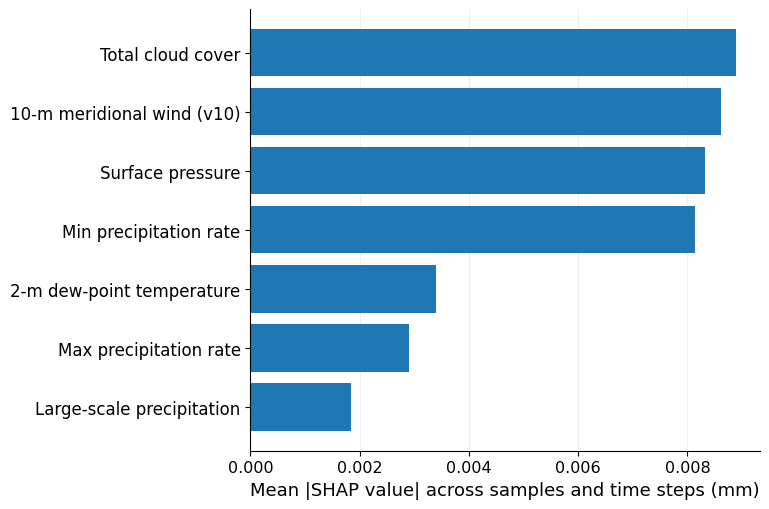

In [22]:
# ============================================================
# Figure 4 — Global SHAP importance
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1 / Fig. 2 / Fig. 3
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent BiLSTM-Attention colour
# - Global SHAP importance averaged across
#   explained samples and all six input time steps
#
# OVERWRITES:
# fig4_global_shap.*
# ============================================================

importance = np.mean(
    np.abs(
        shap_values
    ),
    axis=(
        0,
        1
    )
)

order = np.argsort(
    importance
)

values = importance[
    order
]

names = [
    FEATURE_LABELS.get(
        feature_names[i],
        feature_names[i]
    )
    for i in order
]

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.8, 5.2)
)

# ============================================================
# Horizontal bars
# ============================================================

ax.barh(
    names,
    values,
    color=COLORS[
        "BiLSTM-Attention"
    ],
    edgecolor="none"
)

# ============================================================
# X axis
# ============================================================

ax.set_xlabel(
    "Mean |SHAP value| across samples and time steps (mm)",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=11.5
)

# ============================================================
# Y axis
# ============================================================

ax.set_ylabel("")

ax.tick_params(
    axis="y",
    labelsize=12
)

# ============================================================
# Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)

# No title inside figure

fig.tight_layout()

# ============================================================
# Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig4_global_shap"
)

OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig5_temporal_shap.pdf


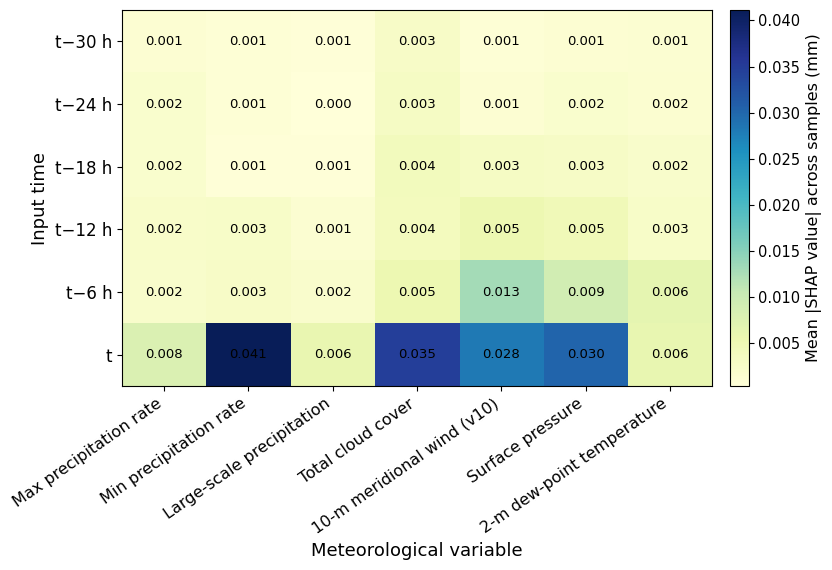

In [23]:
# ============================================================
# Figure 5 — Temporal SHAP heatmap
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1–4
# - Larger journal-readable fonts
# - No in-figure title
# - Real elapsed input times retained
# - Larger heatmap annotations
#
# OVERWRITES:
# fig5_temporal_shap.*
# ============================================================

importance = np.mean(
    np.abs(
        shap_values
    ),
    axis=0
)

display_features = [
    FEATURE_LABELS.get(
        feature,
        feature
    )
    for feature in feature_names
]

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.6, 5.8)
)

im = ax.imshow(
    importance,
    aspect="auto",
    cmap="YlGnBu"
)

# ============================================================
# X axis — meteorological variables
# ============================================================

ax.set_xticks(
    np.arange(
        n_features
    )
)

ax.set_xticklabels(
    display_features,
    rotation=35,
    ha="right",
    fontsize=11.5
)

ax.set_xlabel(
    "Meteorological variable",
    fontsize=13
)

# ============================================================
# Y axis — real elapsed input time
# ============================================================

ax.set_yticks(
    np.arange(
        n_timesteps
    )
)

ax.set_yticklabels(
    time_labels,
    fontsize=12
)

ax.set_ylabel(
    "Input time",
    fontsize=13
)

# ============================================================
# Value annotations
# ============================================================

for i in range(
    n_timesteps
):

    for j in range(
        n_features
    ):

        ax.text(
            j,
            i,
            f"{importance[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=9.5
        )

# ============================================================
# Colour bar
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    pad=0.025
)

cbar.set_label(
    "Mean |SHAP value| across samples (mm)",
    fontsize=11.5
)

cbar.ax.tick_params(
    labelsize=10.5
)

# ============================================================
# Styling
# ============================================================

# Heatmaps normally do not need grid lines
ax.grid(False)

# No title inside figure

fig.tight_layout()

# ============================================================
# Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig5_temporal_shap"
)

OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig6_shap_summary.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig6_shap_summary.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig6_shap_summary.pdf


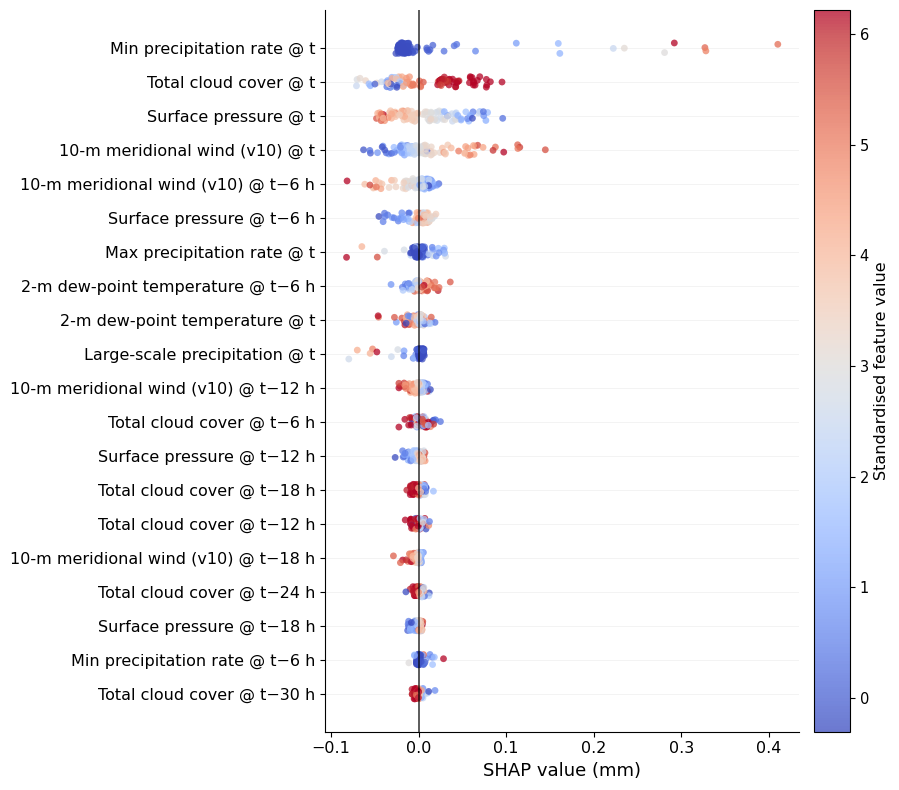

In [24]:
# ============================================================
# Figure 6 — SHAP summary plot
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1–5
# - Larger journal-readable fonts
# - No in-figure title
# - True elapsed input times retained
# - Larger scatter markers
# - Larger feature-time labels
#
# Each feature-time combination is treated independently.
#
# OVERWRITES:
# fig6_shap_summary.*
# ============================================================


# ============================================================
# 1. Flatten SHAP values and input features
# ============================================================

flat_shap = shap_values.reshape(
    n_explain,
    -1
)

flat_X = X_explain.reshape(
    n_explain,
    -1
)


# ============================================================
# 2. Construct feature × time labels
# ============================================================

flat_names = []

for i in range(
    n_timesteps
):

    for j in range(
        n_features
    ):

        feature_label = FEATURE_LABELS.get(
            feature_names[j],
            feature_names[j]
        )

        flat_names.append(
            f"{feature_label} @ {time_labels[i]}"
        )


# ============================================================
# 3. Rank feature-time combinations
# ============================================================

mean_abs = np.mean(
    np.abs(
        flat_shap
    ),
    axis=0
)

TOP_N = min(
    20,
    len(mean_abs)
)

# The most important combination will appear at the top
top_idx = np.argsort(
    mean_abs
)[
    -TOP_N:
]


# ============================================================
# 4. Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.2, 8.0)
)

rng = np.random.default_rng(
    42
)

scatter = None


# ============================================================
# 5. SHAP scatter
# ============================================================

for rank, idx in enumerate(
    top_idx
):

    shap_row = flat_shap[
        :,
        idx
    ]

    feature_value = flat_X[
        :,
        idx
    ]

    # Vertical jitter for visibility
    jitter = rng.uniform(
        -0.16,
        0.16,
        size=len(shap_row)
    )

    scatter = ax.scatter(
        shap_row,
        rank + jitter,

        c=feature_value,

        cmap="coolwarm",

        s=24,

        alpha=0.75,

        edgecolors="none"
    )


# ============================================================
# 6. Zero SHAP reference line
# ============================================================

ax.axvline(
    0,
    color="black",
    linewidth=1.2,
    linestyle="-",
    alpha=0.75
)


# ============================================================
# 7. Y axis — feature × time combinations
# ============================================================

ax.set_yticks(
    np.arange(
        TOP_N
    )
)

ax.set_yticklabels(
    [
        flat_names[i]
        for i in top_idx
    ],
    fontsize=11.5
)

ax.set_ylabel("")


# ============================================================
# 8. X axis
# ============================================================

ax.set_xlabel(
    "SHAP value (mm)",
    fontsize=13
)

ax.tick_params(
    axis="x",
    labelsize=11.5
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)


# ============================================================
# 9. Feature-value colour bar
# ============================================================

cbar = fig.colorbar(
    scatter,
    ax=ax,
    pad=0.025
)

cbar.set_label(
    "Standardised feature value",
    fontsize=11.5
)

cbar.ax.tick_params(
    labelsize=10.5
)


# ============================================================
# 10. Styling
# ============================================================

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

# Very light horizontal guide lines
ax.grid(
    axis="y",
    alpha=0.15,
    linewidth=0.7
)

ax.set_axisbelow(
    True
)

# No title inside figure


# ============================================================
# 11. Layout
# ============================================================

fig.tight_layout()


# ============================================================
# 12. Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig6_shap_summary"
)

OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig1_5seed_rmse.pdf


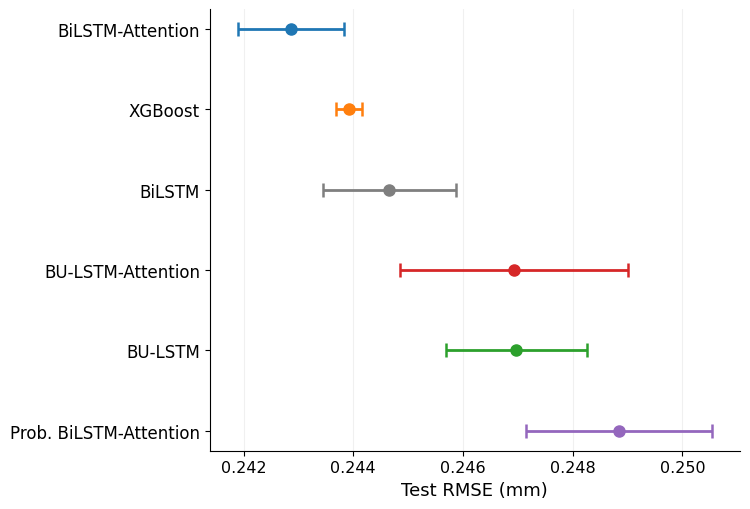

In [19]:
# ============================================================
# Figure 1 — Five-seed RMSE stability
#
# FINAL REVISED VERSION
#
# - Best model shown at TOP
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent model colours
# - Suitable for Overleaf width=\linewidth
#
# OVERWRITES:
# fig1_5seed_rmse.*
# ============================================================

seed_point = pd.read_csv(
    os.path.join(
        METRIC_DIR,
        "final_5seed_point.csv"
    )
)

df = seed_point.copy()

# IMPORTANT:
# Largest RMSE first -> appears at bottom
# Smallest RMSE last -> appears naturally at top
df = df.sort_values(
    "RMSE_mean",
    ascending=False
).reset_index(drop=True)

y = np.arange(len(df))


# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.6, 5.2)
)


for pos, row in df.iterrows():

    model = row["Model"]

    color = COLORS.get(
        model,
        "black"
    )

    ax.errorbar(
        row["RMSE_mean"],
        pos,
        xerr=row["RMSE_std"],

        fmt="o",

        markersize=8,

        capsize=5,

        capthick=1.8,

        elinewidth=2.0,

        color=color,

        markerfacecolor=color,

        markeredgecolor=color
    )


# ============================================================
# Y axis
# ============================================================

ax.set_yticks(
    y
)

ax.set_yticklabels(
    [
        LABELS.get(
            model,
            model
        )
        for model in df["Model"]
    ],
    fontsize=12
)


# ============================================================
# X axis
# ============================================================

ax.set_xlabel(
    "Test RMSE (mm)",
    fontsize=13
)

ax.set_ylabel("")

ax.tick_params(
    axis="x",
    labelsize=11.5
)

ax.tick_params(
    axis="y",
    labelsize=12
)


# ============================================================
# X limits
# ============================================================

x_min = (
    df["RMSE_mean"]
    -
    df["RMSE_std"]
).min()

x_max = (
    df["RMSE_mean"]
    +
    df["RMSE_std"]
).max()

padding = (
    x_max - x_min
) * 0.06

ax.set_xlim(
    x_min - padding,
    x_max + padding
)


# ============================================================
# Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(True)

# NO title inside figure


fig.tight_layout()


# ============================================================
# Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig1_5seed_rmse"
)

OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.png
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.svg
OVERWRITTEN: /root/autodl-tmp/results/final_figures/fig2_stratified_rmse.pdf


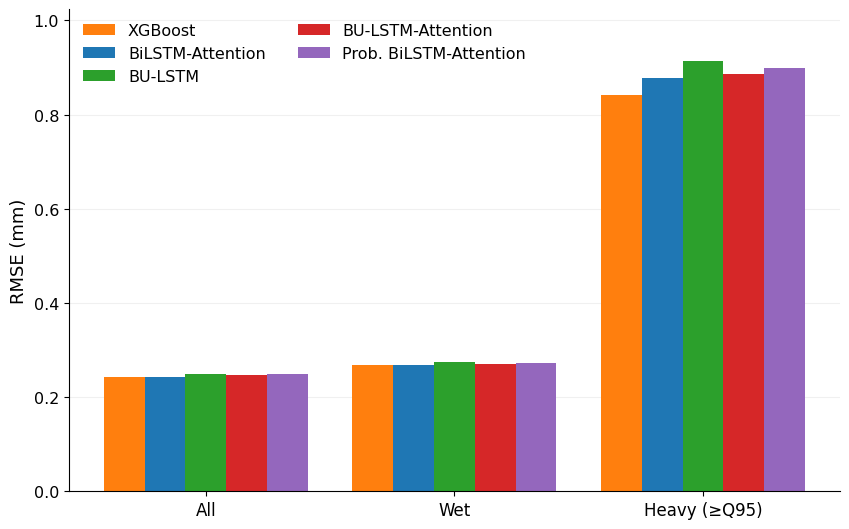

In [20]:
# ============================================================
# Figure 2 — Point forecasting across precipitation regimes
#
# FINAL REVISED VERSION
#
# - Same visual standard as Fig. 1
# - Larger journal-readable fonts
# - No in-figure title
# - Consistent model colours
# - Q99 excluded from main figure
#
# OVERWRITES:
# fig2_stratified_rmse.*
# ============================================================

strat_point = pd.read_csv(
    os.path.join(
        METRIC_DIR,
        "final_stratified_point.csv"
    )
)

# ============================================================
# Main-paper regimes
# ============================================================

regimes = [
    "All",
    "Wet",
    "Heavy_Q95"
]

# ============================================================
# Models
# ============================================================

models = [
    "XGBoost",
    "BiLSTM-Attention",
    "BU-LSTM",
    "BU-LSTM-Attention (proposed)",
    "Probabilistic BiLSTM-Attention"
]

# ============================================================
# Filter data
# ============================================================

df = strat_point[
    strat_point["Regime"].isin(regimes)
    &
    strat_point["Model"].isin(models)
].copy()

x = np.arange(len(regimes))

# Slightly wider bars for readability
width = 0.82 / len(models)

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.6, 5.4)
)

# ============================================================
# Bars
# ============================================================

for i, model in enumerate(models):

    values = []

    for regime in regimes:

        temp = df[
            (df["Model"] == model)
            &
            (df["Regime"] == regime)
        ]

        assert len(temp) == 1, (
            f"Unexpected row count for "
            f"{model}, {regime}: {len(temp)}"
        )

        values.append(
            temp["RMSE"].iloc[0]
        )

    offset = (
        i - (len(models) - 1) / 2
    ) * width

    ax.bar(
        x + offset,
        values,
        width=width,
        label=LABELS.get(model, model),
        color=COLORS.get(model, "black"),
        edgecolor="none"
    )

# ============================================================
# X axis
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    [
        REGIME_LABELS[regime]
        for regime in regimes
    ],
    fontsize=12
)

ax.set_xlabel("")

# ============================================================
# Y axis
# ============================================================

ax.set_ylabel(
    "RMSE (mm)",
    fontsize=13
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)

# ============================================================
# Y limits
# ============================================================

y_max = df["RMSE"].max()

ax.set_ylim(
    0,
    y_max * 1.12
)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=11.5,
    loc="upper left"
)

# ============================================================
# Styling
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(True)

# No title inside figure

fig.tight_layout()

# ============================================================
# Save — overwrite original
# ============================================================

save_figure(
    fig,
    "fig2_stratified_rmse"
)

(12, 12)


,u10,v10,d2m,t2m,sp,e,mxtpr,mntpr,tcc,ssr,lsp,tp
u10,1.000000,0.051692,-0.085973,-0.050827,-0.180656,-0.130694,-0.029068,-0.039891,-0.076684,-0.075814,-0.002948,-0.006281
v10,0.051692,1.000000,0.265646,0.198458,-0.269596,0.085631,0.199078,0.185721,0.312324,-0.058074,0.223419,0.181583
d2m,-0.085973,0.265646,1.000000,0.918222,-0.026799,0.125632,0.243964,0.217554,0.262842,0.208021,0.232436,0.218942
t2m,-0.050827,0.198458,0.918222,1.000000,0.025750,-0.155226,0.160035,0.091399,0.156464,0.440385,0.062704,0.126573
sp,-0.180656,-0.269596,-0.026799,0.025750,1.000000,0.144018,-0.410881,-0.393529,-0.122955,0.053111,-0.387247,-0.427731
e,-0.130694,0.085631,0.125632,-0.155226,0.144018,1.000000,-0.136087,-0.053199,0.125231,-0.652304,0.046969,-0.135689
mxtpr,-0.029068,0.199078,0.243964,0.160035,-0.410881,-0.136087,1.000000,0.924172,0.480058,0.085088,0.880629,0.986773
mntpr,-0.039891,0.185721,0.217554,0.091399,-0.393529,-0.053199,0.924172,1.000000,0.483109,0.001455,0.929083,0.942583
tcc,-0.076684,0.312324,0.262842,0.156464,-0.122955,0.125231,0.480058,0.483109,1.000000,-0.040534,0.531759,0.475471
ssr,-0.075814,-0.058074,0.208021,0.440385,0.053111,-0.652304,0.085088,0.001455,-0.040534,1.000000,-0.087056,0.060665


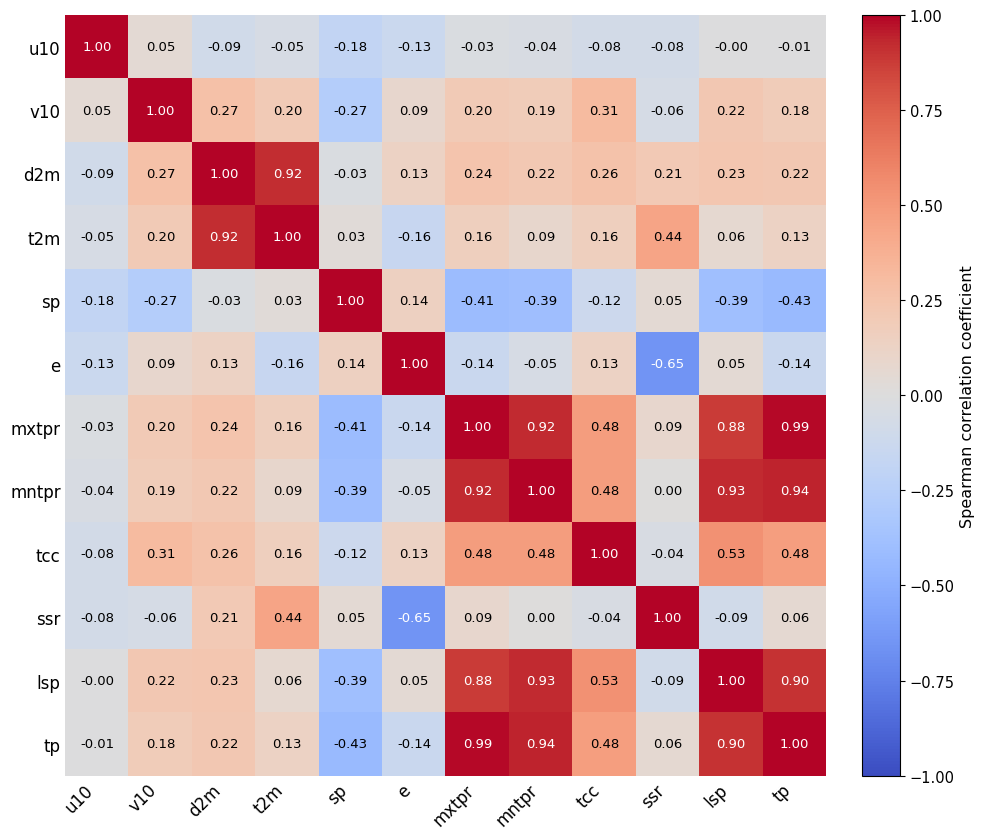

In [5]:
#speraman
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Figure: Training-only Spearman correlation heatmap
# ============================================================

# 1. Load correlation matrix
csv_path = "autodl-tmp/results/features/train_only_spearman.csv"
corr = pd.read_csv(csv_path, index_col=0)

# Ensure numeric
corr = corr.apply(pd.to_numeric, errors="coerce")
corr = corr.rename(index={"tp_mm": "tp"}, columns={"tp_mm": "tp"})

print(corr.shape)
display(corr)

# ------------------------------------------------------------
# 2. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8.5))

im = ax.imshow(
    corr.values,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    aspect="equal"
)

# Axis labels
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns, fontsize=12, rotation=45, ha="right")
ax.set_yticklabels(corr.index, fontsize=12)

# Values inside cells
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]

        # Automatically choose text contrast
        text_color = "white" if abs(value) > 0.55 else "black"

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=9.5,
            color=text_color
        )

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman correlation coefficient", fontsize=11.5)
cbar.ax.tick_params(labelsize=10.5)

# Remove unnecessary spines
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(length=0)

plt.tight_layout()

# ------------------------------------------------------------
# 3. Save
# ------------------------------------------------------------
plt.savefig(
    "autodl-tmp/results/final_figures/train_only_spearman_heatmap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "autodl-tmp/results/final_figures/train_only_spearman_heatmap.svg",
    bbox_inches="tight"
)

plt.savefig(
    "autodl-tmp/results/final_figures/train_only_spearman_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# Step 19 — Rain / No-Rain Event Classification
#
# Purpose:
#   Convert continuous rainfall forecasts into binary
#   rain / no-rain events and evaluate event-detection skill.
#
# NO retraining required.
# Reads existing prediction CSV files only.
#
# Metrics:
#   Accuracy
#   Precision
#   POD / Recall
#   F1
#   CSI
#   FAR
#
# Threshold sensitivity:
#   0.0, 0.1, 0.5, 1.0 mm
#
# OUTPUT:
#   results/metrics/rain_no_rain_threshold_analysis.csv
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 0. Paths
# ============================================================

PRED_DIR = "/root/autodl-tmp/results/predictions"
METRICS_DIR = "/root/autodl-tmp/results/metrics"

os.makedirs(
    METRICS_DIR,
    exist_ok=True
)


# ============================================================
# 1. Existing prediction files
# ============================================================

MODEL_FILES = {

    "Persistence":
        "persistence_preds.csv",

    "Climatology":
        "climatology_preds.csv",

    "XGBoost":
        "xgboost_preds.csv",

    "BiLSTM-Attention":
        "bilstm_attention_preds.csv",

    "BU-LSTM":
        "bulstm_preds.csv",

    "BU-LSTM-Attention":
        "proposed_model_preds.csv",

    "Probabilistic BiLSTM-Attention":
        "prob_bilstm_attention_preds.csv",
}


# ============================================================
# 2. Rain / no-rain thresholds
# ============================================================

RAIN_THRESHOLDS_MM = [
    0.0,
    0.1,
    0.5,
    1.0
]


# ============================================================
# 3. Reference TEST data
#
# Use BiLSTM-Attention only as reference for timestamps/y_true.
# All other models will be aligned by valid_time.
# ============================================================

reference_path = os.path.join(
    PRED_DIR,
    "bilstm_attention_preds.csv"
)

assert os.path.exists(
    reference_path
), f"Missing reference prediction file: {reference_path}"


reference = pd.read_csv(
    reference_path
)

test_ref = reference[
    reference["split"] == "test"
].copy()

test_ref["valid_time"] = pd.to_datetime(
    test_ref["valid_time"]
)

test_ref = (
    test_ref
    .sort_values("valid_time")
    .reset_index(drop=True)
)

print(
    f"Reference test samples: {len(test_ref)}"
)


# ============================================================
# 4. Helper — align each model to reference test period
# ============================================================

def load_aligned_test(filename):

    path = os.path.join(
        PRED_DIR,
        filename
    )

    if not os.path.exists(path):

        print(
            f"WARNING — missing file: {filename}"
        )

        return None

    df = pd.read_csv(
        path
    )

    test = df[
        df["split"] == "test"
    ].copy()

    test["valid_time"] = pd.to_datetime(
        test["valid_time"]
    )

    merged = test_ref[
        [
            "valid_time",
            "y_true"
        ]
    ].merge(

        test[
            [
                "valid_time",
                "y_true",
                "y_pred_mean"
            ]
        ],

        on="valid_time",

        how="inner",

        suffixes=(
            "_ref",
            ""
        )
    )

    assert len(merged) == len(test_ref), (
        f"{filename}: test timestamps do not fully align."
    )

    assert np.allclose(
        merged["y_true_ref"].values,
        merged["y_true"].values
    ), (
        f"{filename}: y_true does not match reference."
    )

    return merged


# ============================================================
# 5. Event metrics
# ============================================================

def event_metrics(
    y_true,
    y_pred,
    threshold
):

    # --------------------------------------------
    # Special treatment for threshold = 0
    #
    # Wet event:
    #   rainfall > 0
    #
    # For positive thresholds:
    #   rainfall >= threshold
    # --------------------------------------------

    if threshold == 0:

        true_event = (
            y_true > 0
        ).astype(int)

        pred_event = (
            y_pred > 0
        ).astype(int)

    else:

        true_event = (
            y_true >= threshold
        ).astype(int)

        pred_event = (
            y_pred >= threshold
        ).astype(int)


    # --------------------------------------------
    # Confusion matrix
    # --------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        true_event,
        pred_event,
        labels=[0, 1]
    ).ravel()


    # --------------------------------------------
    # Standard classification metrics
    # --------------------------------------------

    accuracy = accuracy_score(
        true_event,
        pred_event
    )

    precision = precision_score(
        true_event,
        pred_event,
        zero_division=0
    )

    pod = recall_score(
        true_event,
        pred_event,
        zero_division=0
    )

    f1 = f1_score(
        true_event,
        pred_event,
        zero_division=0
    )


    # --------------------------------------------
    # Meteorological event metrics
    # --------------------------------------------

    # Critical Success Index
    denominator_csi = (
        tp + fp + fn
    )

    csi = (
        tp / denominator_csi
        if denominator_csi > 0
        else np.nan
    )


    # False Alarm Ratio
    denominator_far = (
        tp + fp
    )

    far = (
        fp / denominator_far
        if denominator_far > 0
        else np.nan
    )


    # Event frequency in observations
    event_fraction = (
        true_event.mean()
    )


    return {

        "N":
            len(y_true),

        "Observed_Event_N":
            int(true_event.sum()),

        "Observed_Event_Fraction":
            event_fraction,

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp),

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "POD":
            pod,

        "F1":
            f1,

        "CSI":
            csi,

        "FAR":
            far
    }


# ============================================================
# 6. Evaluate all models at all thresholds
# ============================================================

rows = []


for model_name, filename in MODEL_FILES.items():

    df = load_aligned_test(
        filename
    )

    if df is None:
        continue


    y_true = df[
        "y_true_ref"
    ].to_numpy()

    y_pred = df[
        "y_pred_mean"
    ].to_numpy()


    for threshold in RAIN_THRESHOLDS_MM:

        metrics = event_metrics(
            y_true,
            y_pred,
            threshold
        )

        rows.append({

            "Model":
                model_name,

            "Threshold_mm":
                threshold,

            **metrics
        })


results = pd.DataFrame(
    rows
)


# ============================================================
# 7. Display results
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "STEP 19 — RAIN / NO-RAIN EVENT CLASSIFICATION"
)

print(
    "=" * 100
)


for threshold in RAIN_THRESHOLDS_MM:

    temp = results[
        results["Threshold_mm"]
        ==
        threshold
    ].copy()

    temp = temp.sort_values(
        "CSI",
        ascending=False
    )


    if threshold == 0:

        label = "Rain > 0 mm"

    else:

        label = (
            f"Rain >= {threshold:.1f} mm"
        )


    print(
        f"\n===== {label} ====="
    )

    print(

        temp[
            [
                "Model",
                "Observed_Event_N",
                "Observed_Event_Fraction",
                "Accuracy",
                "Precision",
                "POD",
                "F1",
                "CSI",
                "FAR"
            ]
        ].to_string(

            index=False,

            formatters={

                "Observed_Event_Fraction":
                    lambda x: f"{x:.4f}",

                "Accuracy":
                    lambda x: f"{x:.4f}",

                "Precision":
                    lambda x: f"{x:.4f}",

                "POD":
                    lambda x: f"{x:.4f}",

                "F1":
                    lambda x: f"{x:.4f}",

                "CSI":
                    lambda x: f"{x:.4f}",

                "FAR":
                    lambda x: f"{x:.4f}"
            }
        )
    )


# ============================================================
# 8. Proposed model summary
# ============================================================

proposed = results[
    results["Model"]
    ==
    "BU-LSTM-Attention"
].copy()


print(
    "\n"
    + "=" * 100
)

print(
    "BU-LSTM-ATTENTION THRESHOLD SENSITIVITY"
)

print(
    "=" * 100
)

print(

    proposed[
        [
            "Threshold_mm",
            "Observed_Event_N",
            "Observed_Event_Fraction",
            "Accuracy",
            "POD",
            "F1",
            "CSI",
            "FAR"
        ]
    ].to_string(

        index=False,

        formatters={

            "Observed_Event_Fraction":
                lambda x: f"{x:.4f}",

            "Accuracy":
                lambda x: f"{x:.4f}",

            "POD":
                lambda x: f"{x:.4f}",

            "F1":
                lambda x: f"{x:.4f}",

            "CSI":
                lambda x: f"{x:.4f}",

            "FAR":
                lambda x: f"{x:.4f}"
        }
    )
)


# ============================================================
# 9. Save
# ============================================================

out_path = os.path.join(
    METRICS_DIR,
    "rain_no_rain_threshold_analysis.csv"
)

results.to_csv(
    out_path,
    index=False
)

print(
    f"\nSaved: {out_path}"
)

print(
    "\n===== STEP 19 COMPLETE ====="
)

Reference test samples: 3939

STEP 19 — RAIN / NO-RAIN EVENT CLASSIFICATION

===== Rain > 0 mm =====
                         Model  Observed_Event_N Observed_Event_Fraction Accuracy Precision    POD     F1    CSI    FAR
Probabilistic BiLSTM-Attention              3228                  0.8195   0.8378    0.8458 0.9808 0.9083 0.8321 0.1542
                   Persistence              3228                  0.8195   0.8449    0.9055 0.9052 0.9053 0.8271 0.0945
             BU-LSTM-Attention              3228                  0.8195   0.8225    0.8243 0.9957 0.9019 0.8214 0.1757
                       BU-LSTM              3228                  0.8195   0.8215    0.8231 0.9963 0.9015 0.8206 0.1769
                   Climatology              3228                  0.8195   0.8195    0.8195 1.0000 0.9008 0.8195 0.1805
                       XGBoost              3228                  0.8195   0.8192    0.8209 0.9969 0.9004 0.8188 0.1791
              BiLSTM-Attention              3228           

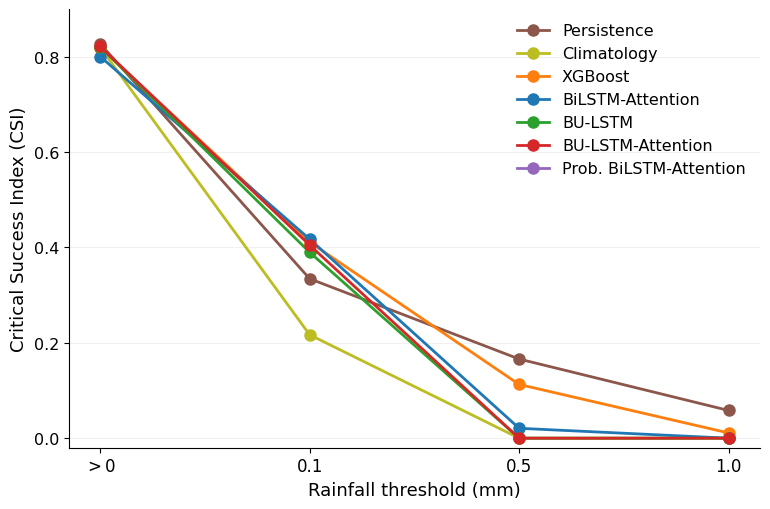

Saved:
/root/autodl-tmp/results/final_figures/rain_threshold_CSI.svg
/root/autodl-tmp/results/final_figures/rain_threshold_CSI.pdf
/root/autodl-tmp/results/final_figures/rain_threshold_CSI.png


In [11]:
# ============================================================
# Step 19 Figure — CSI across rainfall thresholds
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = "/root/autodl-tmp/results/final_figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# Fixed model colors
# ------------------------------------------------------------

MODEL_COLORS = {
    "BiLSTM-Attention": "#1f77b4",
    "XGBoost": "#ff7f0e",
    "BU-LSTM": "#2ca02c",
    "BU-LSTM-Attention": "#d62728",
    "Prob. BiLSTM-Attention": "#9467bd",
    "Persistence": "#8c564b",
    "Climatology": "#bcbd22",
}

MODEL_ORDER = [
    "Persistence",
    "Climatology",
    "XGBoost",
    "BiLSTM-Attention",
    "BU-LSTM",
    "BU-LSTM-Attention",
    "Prob. BiLSTM-Attention",
]

# Use evenly spaced categorical positions
thresholds = [0.0, 0.1, 0.5, 1.0]
x = np.arange(len(thresholds))

fig, ax = plt.subplots(
    figsize=(7.8, 5.2)
)

for model in MODEL_ORDER:

    temp = (
        results[results["Model"] == model]
        .set_index("Threshold_mm")
        .reindex(thresholds)
    )

    ax.plot(
        x,
        temp["CSI"].values,
        marker="o",
        markersize=8,
        linewidth=2.0,
        label=model,
        color=MODEL_COLORS[model]
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel(
    "Rainfall threshold (mm)",
    fontsize=13
)

ax.set_ylabel(
    "Critical Success Index (CSI)",
    fontsize=13
)

ax.set_xticks(x)
ax.set_xticklabels(
    ["$>0$", "0.1", "0.5", "1.0"],
    fontsize=12
)

ax.tick_params(
    axis="y",
    labelsize=11.5
)

ax.set_ylim(
    -0.02,
    0.90
)

ax.grid(
    axis="y",
    alpha=0.18,
    linewidth=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=11.5,
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

# ------------------------------------------------------------
# Save SVG / PDF / PNG
# ------------------------------------------------------------

base = os.path.join(
    FIG_DIR,
    "rain_threshold_CSI"
)

plt.savefig(
    base + ".svg",
    bbox_inches="tight"
)

plt.savefig(
    base + ".pdf",
    bbox_inches="tight"
)

plt.savefig(
    base + ".png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(base + ".svg")
print(base + ".pdf")
print(base + ".png")

In [12]:
# ============================================================
# Step 20 — Leave-One-Feature-Out Feature Ablation
#
# Proposed BU-LSTM-Attention only.
#
# Full model:
#   mxtpr, mntpr, lsp, tcc, v10, sp, d2m
#
# Ablation:
#   remove ONE predictor at a time, then retrain from scratch.
#
# Architecture and training protocol are IDENTICAL to Step 7:
#   3 x BiLSTM(64) + Dropout(0.2)
#   Temporal Attention
#   Gaussian NLL mean/log-variance output
#   Adam(lr=0.001)
#   batch_size=32
#   epochs<=30
#   EarlyStopping(patience=10)
#   seed=42
#
# Requires Step 2D outputs only.
#
# OUTPUT:
#   results/ablation/feature_ablation.csv
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Layer
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 0. Check Step 2D outputs
# ============================================================

required_vars = [
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "y_scaler",
    "FINAL_FEATURES",
]

for var in required_vars:
    assert var in globals(), (
        f"{var} missing. Re-run Step 1–2D first."
    )

print("FINAL_FEATURES:")
print(FINAL_FEATURES)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)


# ============================================================
# 1. Settings
# ============================================================

SEED = 42

ABLATION_DIR = "/root/autodl-tmp/results/ablation"

os.makedirs(
    ABLATION_DIR,
    exist_ok=True
)


# ============================================================
# 2. Reproducibility
# ============================================================

def reset_seed(seed=SEED):

    tf.keras.backend.clear_session()

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


# ============================================================
# 3. Temporal Attention
#    Identical formulation to Step 7
# ============================================================

class TemporalAttention(Layer):

    def __init__(
        self,
        attn_units=64,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.attn_units = attn_units


    def build(
        self,
        input_shape
    ):

        H = input_shape[-1]

        self.W = self.add_weight(
            name="W",
            shape=(H, self.attn_units),
            initializer="glorot_uniform",
            trainable=True
        )

        self.b = self.add_weight(
            name="b",
            shape=(self.attn_units,),
            initializer="zeros",
            trainable=True
        )

        self.v = self.add_weight(
            name="v",
            shape=(self.attn_units, 1),
            initializer="glorot_uniform",
            trainable=True
        )

        super().build(input_shape)


    def call(
        self,
        h
    ):

        score = tf.tanh(
            tf.tensordot(
                h,
                self.W,
                axes=1
            )
            +
            self.b
        )

        score = tf.tensordot(
            score,
            self.v,
            axes=1
        )

        alpha = tf.nn.softmax(
            score,
            axis=1
        )

        context = tf.reduce_sum(
            alpha * h,
            axis=1
        )

        return context, alpha


# ============================================================
# 4. Gaussian NLL
#    Identical to Step 7
# ============================================================

def nll_loss(
    y_true,
    y_pred_mean,
    y_pred_log_var
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    precision = tf.exp(
        -y_pred_log_var
    )

    return tf.reduce_mean(
        0.5
        * precision
        * tf.square(
            y_true - y_pred_mean
        )
        +
        0.5
        * y_pred_log_var
    )


# ============================================================
# 5. Custom NLL model
# ============================================================

class CustomNLLModel(tf.keras.Model):

    def __init__(
        self,
        model,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.model = model

        self.loss_tracker = (
            tf.keras.metrics.Mean(
                name="loss"
            )
        )

        self.val_loss_tracker = (
            tf.keras.metrics.Mean(
                name="val_loss"
            )
        )


    def call(
        self,
        inputs,
        training=False
    ):

        return self.model(
            inputs,
            training=training
        )


    def train_step(
        self,
        data
    ):

        x, y = data

        with tf.GradientTape() as tape:

            out = self(
                x,
                training=True
            )

            mean = out[:, 0]
            log_var = out[:, 1]

            loss = nll_loss(
                y,
                mean,
                log_var
            )

        grads = tape.gradient(
            loss,
            self.trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(
                grads,
                self.trainable_variables
            )
        )

        self.loss_tracker.update_state(
            loss
        )

        return {
            "loss":
                self.loss_tracker.result()
        }


    def test_step(
        self,
        data
    ):

        x, y = data

        out = self(
            x,
            training=False
        )

        mean = out[:, 0]
        log_var = out[:, 1]

        loss = nll_loss(
            y,
            mean,
            log_var
        )

        self.val_loss_tracker.update_state(
            loss
        )

        return {
            "loss":
                self.val_loss_tracker.result()
        }


    @property
    def metrics(self):

        return [
            self.loss_tracker,
            self.val_loss_tracker
        ]


# ============================================================
# 6. Build BU-LSTM-Attention
#    EXACT Step 7 architecture
# ============================================================

def build_proposed_model(
    timesteps,
    n_features
):

    inputs = Input(
        shape=(
            timesteps,
            n_features
        )
    )

    h = Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    )(inputs)

    h = Dropout(
        0.2
    )(h)

    h = Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    )(h)

    h = Dropout(
        0.2
    )(h)

    h = Bidirectional(
        LSTM(
            64,
            return_sequences=True
        )
    )(h)

    h = Dropout(
        0.2
    )(h)

    context, _ = TemporalAttention(
        attn_units=64
    )(h)

    out = Dense(
        2
    )(context)

    base_model = Model(
        inputs,
        out
    )

    model = CustomNLLModel(
        base_model
    )

    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        )
    )

    return model


# ============================================================
# 7. Target inverse transformation
# ============================================================

def inverse_y(
    values
):

    return y_scaler.inverse_transform(
        np.asarray(
            values
        ).reshape(-1, 1)
    ).flatten()


y_test_mm = inverse_y(
    y_test
)


# ============================================================
# 8. Experiment definitions
#
# Full + seven leave-one-out runs
# ============================================================

experiments = {
    "Full": list(range(len(FINAL_FEATURES)))
}

for i, feature in enumerate(FINAL_FEATURES):

    experiments[
        f"Without_{feature}"
    ] = [
        j
        for j in range(len(FINAL_FEATURES))
        if j != i
    ]


print("\n===== EXPERIMENTS =====")

for name, idx in experiments.items():

    features = [
        FINAL_FEATURES[i]
        for i in idx
    ]

    print(
        f"{name:20s}: {features}"
    )


# ============================================================
# 9. Train all experiments
# ============================================================

rows = []


for exp_name, keep_idx in experiments.items():

    print(
        "\n"
        + "=" * 90
    )

    print(
        exp_name
    )

    print(
        "=" * 90
    )


    kept_features = [
        FINAL_FEATURES[i]
        for i in keep_idx
    ]


    # --------------------------------------------------------
    # Select feature channels
    # --------------------------------------------------------

    X_train_ab = X_train[
        :,
        :,
        keep_idx
    ]

    X_val_ab = X_val[
        :,
        :,
        keep_idx
    ]

    X_test_ab = X_test[
        :,
        :,
        keep_idx
    ]


    print(
        "Features:",
        kept_features
    )

    print(
        "Input shape:",
        X_train_ab.shape
    )


    # --------------------------------------------------------
    # Reset seed before EVERY run
    # --------------------------------------------------------

    reset_seed(
        SEED
    )


    # --------------------------------------------------------
    # Build identical model
    # --------------------------------------------------------

    model = build_proposed_model(

        timesteps=
            X_train_ab.shape[1],

        n_features=
            X_train_ab.shape[2]
    )


    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=10,

        restore_best_weights=True
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history = model.fit(

        X_train_ab,
        y_train,

        validation_data=(
            X_val_ab,
            y_val
        ),

        epochs=30,

        batch_size=32,

        callbacks=[
            early_stop
        ],

        verbose=2
    )


    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------

    output = model.predict(
        X_test_ab,
        verbose=0
    )

    pred_scaled = output[:, 0]

    pred_mm = inverse_y(
        pred_scaled
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    rmse = np.sqrt(
        mean_squared_error(
            y_test_mm,
            pred_mm
        )
    )

    mae = mean_absolute_error(
        y_test_mm,
        pred_mm
    )

    r2 = r2_score(
        y_test_mm,
        pred_mm
    )


    removed_feature = (
        "None"
        if exp_name == "Full"
        else exp_name.replace(
            "Without_",
            ""
        )
    )


    rows.append({

        "Experiment":
            exp_name,

        "Removed_Feature":
            removed_feature,

        "N_Features":
            len(keep_idx),

        "RMSE":
            rmse,

        "MAE":
            mae,

        "R2":
            r2
    })


    print(
        f"\nRMSE = {rmse:.6f}"
    )

    print(
        f"MAE  = {mae:.6f}"
    )

    print(
        f"R2   = {r2:.6f}"
    )


# ============================================================
# 10. Calculate changes relative to Full
# ============================================================

ablation_results = pd.DataFrame(
    rows
)


full_rmse = float(
    ablation_results.loc[
        ablation_results["Experiment"] == "Full",
        "RMSE"
    ].iloc[0]
)

full_mae = float(
    ablation_results.loc[
        ablation_results["Experiment"] == "Full",
        "MAE"
    ].iloc[0]
)

full_r2 = float(
    ablation_results.loc[
        ablation_results["Experiment"] == "Full",
        "R2"
    ].iloc[0]
)


ablation_results[
    "Delta_RMSE"
] = (
    ablation_results["RMSE"]
    -
    full_rmse
)

ablation_results[
    "Delta_MAE"
] = (
    ablation_results["MAE"]
    -
    full_mae
)

ablation_results[
    "Delta_R2"
] = (
    ablation_results["R2"]
    -
    full_r2
)


# ============================================================
# 11. Display final results
# ============================================================

display_results = (
    ablation_results
    .sort_values(
        "Delta_RMSE",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n"
    + "=" * 100
)

print(
    "STEP 20 — FEATURE ABLATION RESULTS"
)

print(
    "=" * 100
)


print(

    display_results[
        [
            "Removed_Feature",
            "N_Features",
            "RMSE",
            "Delta_RMSE",
            "MAE",
            "R2"
        ]
    ].to_string(

        index=False,

        float_format=
            lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 12. Save
# ============================================================

out_path = os.path.join(
    ABLATION_DIR,
    "feature_ablation.csv"
)

ablation_results.to_csv(
    out_path,
    index=False
)


print(
    "\nSaved:"
)

print(
    out_path
)

print(
    "\n===== STEP 20 COMPLETE ====="
)

FINAL_FEATURES:
['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']

Shapes:
X_train: (18404, 6, 7)
X_val:   (3939, 6, 7)
X_test:  (3939, 6, 7)

===== EXPERIMENTS =====
Full                : ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
Without_mxtpr       : ['mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
Without_mntpr       : ['mxtpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
Without_lsp         : ['mxtpr', 'mntpr', 'tcc', 'v10', 'sp', 'd2m']
Without_tcc         : ['mxtpr', 'mntpr', 'lsp', 'v10', 'sp', 'd2m']
Without_v10         : ['mxtpr', 'mntpr', 'lsp', 'tcc', 'sp', 'd2m']
Without_sp          : ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'd2m']
Without_d2m         : ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp']

Full
Features: ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp', 'd2m']
Input shape: (18404, 6, 7)


W0000 00:00:1788537155.006468    1026 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1788537155.030893    1026 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788537155.322859    1026 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:38:00.0, compute capability: 12.0a


Epoch 1/30


E0000 00:00:1788537160.538684    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1788537165.720682    2519 cuda_dnn.cc:461] Loaded cuDNN version 91002
E0000 00:00:1788537202.663635    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:var

576/576 - 44s - 76ms/step - loss: 0.1153 - val_loss: 0.1005
Epoch 2/30
576/576 - 12s - 21ms/step - loss: 0.0202 - val_loss: 0.1152
Epoch 3/30
576/576 - 12s - 21ms/step - loss: -1.9969e-02 - val_loss: 0.1612
Epoch 4/30
576/576 - 12s - 20ms/step - loss: -7.5471e-02 - val_loss: 0.0498
Epoch 5/30
576/576 - 11s - 20ms/step - loss: -1.2386e-01 - val_loss: -6.6968e-02
Epoch 6/30
576/576 - 11s - 20ms/step - loss: -9.0225e-02 - val_loss: 0.0609
Epoch 7/30
576/576 - 12s - 20ms/step - loss: -1.6983e-01 - val_loss: -6.8649e-02
Epoch 8/30
576/576 - 11s - 18ms/step - loss: -1.7977e-01 - val_loss: -1.4456e-02
Epoch 9/30
576/576 - 11s - 20ms/step - loss: -2.2642e-01 - val_loss: -5.1959e-02
Epoch 10/30
576/576 - 11s - 20ms/step - loss: -2.6584e-01 - val_loss: -3.5890e-02
Epoch 11/30
576/576 - 12s - 21ms/step - loss: -2.3534e-01 - val_loss: -9.5428e-02
Epoch 12/30
576/576 - 11s - 20ms/step - loss: -2.6996e-01 - val_loss: 0.2957
Epoch 13/30
576/576 - 11s - 19ms/step - loss: -2.5883e-01 - val_loss: 0.0640

...


RMSE = 0.248728
MAE  = 0.121818
R2   = 0.173225

Without_d2m
Features: ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'sp']
Input shape: (18404, 6, 6)
Epoch 1/30


E0000 00:00:1788539307.332505    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


576/576 - 14s - 24ms/step - loss: 0.0963 - val_loss: 0.0280
Epoch 2/30
576/576 - 12s - 20ms/step - loss: 0.0237 - val_loss: 0.0551
Epoch 3/30
576/576 - 12s - 20ms/step - loss: -5.8509e-03 - val_loss: 0.0479
Epoch 4/30
576/576 - 12s - 21ms/step - loss: -5.1440e-02 - val_loss: 0.0699
Epoch 5/30
576/576 - 12s - 21ms/step - loss: -6.5200e-02 - val_loss: 0.0399
Epoch 6/30
576/576 - 11s - 19ms/step - loss: -1.2644e-01 - val_loss: -5.8376e-02
Epoch 7/30
576/576 - 12s - 21ms/step - loss: -1.8449e-01 - val_loss: 0.1073
Epoch 8/30
576/576 - 11s - 20ms/step - loss: -1.7307e-01 - val_loss: -7.4747e-02
Epoch 9/30
576/576 - 12s - 21ms/step - loss: -1.9288e-01 - val_loss: -4.0341e-02
Epoch 10/30
576/576 - 12s - 20ms/step - loss: -2.0250e-01 - val_loss: -4.2032e-02
Epoch 11/30
576/576 - 12s - 20ms/step - loss: -2.6494e-01 - val_loss: 0.0425
Epoch 12/30
576/576 - 12s - 21ms/step - loss: -2.6804e-01 - val_loss: 0.0731
Epoch 13/30
576/576 - 12s - 20ms/step - loss: -2.8425e-01 - val_loss: 0.0598
Epoch 14/

E0000 00:00:1788539575.414924    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



RMSE = 0.245631
MAE  = 0.121182
R2   = 0.193685

STEP 20 — FEATURE ABLATION RESULTS
Removed_Feature  N_Features     RMSE  Delta_RMSE      MAE       R2
            tcc           6 0.253851    0.007438 0.119262 0.138816
             sp           6 0.248728    0.002315 0.121818 0.173225
            v10           6 0.248054    0.001640 0.118083 0.177704
           None           7 0.246413    0.000000 0.117614 0.188543
            lsp           6 0.245644   -0.000769 0.119198 0.193601
            d2m           6 0.245631   -0.000782 0.121182 0.193685
          mntpr           6 0.245154   -0.001259 0.118614 0.196816
          mxtpr           6 0.244492   -0.001922 0.120643 0.201149

Saved:
/root/autodl-tmp/results/ablation/feature_ablation.csv

===== STEP 20 COMPLETE =====


In [13]:
# ============================================================
# Step 20B — Targeted Multi-Seed Feature Ablation
#
# Only validate the two scientifically useful findings:
#
#   1. Without tcc
#      -> largest degradation in single-seed ablation
#
#   2. Without mxtpr
#      -> strongest Spearman correlation with tp,
#         but removal slightly improved RMSE
#
# Full-model 5-seed results are REUSED from Step 9:
#   seeds = [42, 123, 7, 2024, 99]
#
# No need to retrain the Full model.
#
# OUTPUT:
#   results/ablation/targeted_ablation_5seed_raw.csv
#   results/ablation/targeted_ablation_5seed_summary.csv
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 0. Settings
# ============================================================

SEEDS = [42, 123, 7, 2024, 99]

TARGET_REMOVALS = [
    "tcc",
    "mxtpr"
]

ABLATION_DIR = "/root/autodl-tmp/results/ablation"
SEED_DIR = "/root/autodl-tmp/results/seeds"

os.makedirs(
    ABLATION_DIR,
    exist_ok=True
)


# ============================================================
# 1. Check Step 20 functions / Step 2D data
# ============================================================

required_vars = [
    "X_train",
    "X_val",
    "X_test",
    "y_train",
    "y_val",
    "y_test",
    "y_scaler",
    "FINAL_FEATURES",
    "build_proposed_model",
    "reset_seed",
    "inverse_y",
]

for var in required_vars:
    assert var in globals(), (
        f"{var} missing. "
        "Run Step 1–2D and Step 20 first."
    )


y_test_mm = inverse_y(
    y_test
)


# ============================================================
# 2. Load existing Full-model 5-seed results from Step 9
# ============================================================

seed_path = os.path.join(
    SEED_DIR,
    "seed_stability_raw.csv"
)

assert os.path.exists(seed_path), (
    f"Missing existing Step 9 file: {seed_path}"
)

seed_raw = pd.read_csv(
    seed_path
)

full = seed_raw[
    seed_raw["model"]
    ==
    "BU-LSTM-Attention (proposed)"
].copy()

full = full[
    full["seed"].isin(SEEDS)
].copy()

assert len(full) == 5, (
    "Expected 5 existing Full-model seeds "
    "from Step 9."
)

full = full[
    [
        "seed",
        "RMSE",
        "MAE",
        "R2"
    ]
].copy()

full["Experiment"] = "Full"

print(
    "Existing Full-model 5-seed results:"
)

print(
    full.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 3. Run targeted ablations
# ============================================================

rows = []


for removed_feature in TARGET_REMOVALS:

    feature_idx = FINAL_FEATURES.index(
        removed_feature
    )

    keep_idx = [
        i
        for i in range(len(FINAL_FEATURES))
        if i != feature_idx
    ]

    kept_features = [
        FINAL_FEATURES[i]
        for i in keep_idx
    ]


    X_train_ab = X_train[
        :,
        :,
        keep_idx
    ]

    X_val_ab = X_val[
        :,
        :,
        keep_idx
    ]

    X_test_ab = X_test[
        :,
        :,
        keep_idx
    ]


    print(
        "\n"
        + "=" * 90
    )

    print(
        f"REMOVED FEATURE: {removed_feature}"
    )

    print(
        "Remaining:",
        kept_features
    )

    print(
        "=" * 90
    )


    for seed in SEEDS:

        print(
            f"\nRunning "
            f"without {removed_feature} "
            f"| seed={seed}"
        )


        # ----------------------------------------------------
        # Reset before every run
        # ----------------------------------------------------

        reset_seed(
            seed
        )


        # ----------------------------------------------------
        # Build identical BU-LSTM-Attention
        # ----------------------------------------------------

        model = build_proposed_model(

            timesteps=
                X_train_ab.shape[1],

            n_features=
                X_train_ab.shape[2]
        )


        early_stop = EarlyStopping(

            monitor="val_loss",

            patience=10,

            restore_best_weights=True
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model.fit(

            X_train_ab,
            y_train,

            validation_data=(
                X_val_ab,
                y_val
            ),

            epochs=30,

            batch_size=32,

            callbacks=[
                early_stop
            ],

            verbose=0
        )


        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------

        output = model.predict(
            X_test_ab,
            verbose=0
        )

        pred_scaled = output[:, 0]

        pred_mm = inverse_y(
            pred_scaled
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        rmse = np.sqrt(
            mean_squared_error(
                y_test_mm,
                pred_mm
            )
        )

        mae = mean_absolute_error(
            y_test_mm,
            pred_mm
        )

        r2 = r2_score(
            y_test_mm,
            pred_mm
        )


        rows.append({

            "Experiment":
                f"Without_{removed_feature}",

            "Removed_Feature":
                removed_feature,

            "seed":
                seed,

            "RMSE":
                rmse,

            "MAE":
                mae,

            "R2":
                r2
        })


        print(
            f"RMSE={rmse:.6f} | "
            f"MAE={mae:.6f} | "
            f"R2={r2:.6f}"
        )


# ============================================================
# 4. Combine with Full results
# ============================================================

ablation_raw = pd.DataFrame(
    rows
)

full_for_merge = full.copy()

full_for_merge[
    "Removed_Feature"
] = "None"


combined = pd.concat(

    [
        full_for_merge[
            [
                "Experiment",
                "Removed_Feature",
                "seed",
                "RMSE",
                "MAE",
                "R2"
            ]
        ],
        ablation_raw
    ],

    ignore_index=True
)


# ============================================================
# 5. Paired Delta RMSE against Full
# ============================================================

full_rmse_by_seed = (
    full
    .set_index("seed")["RMSE"]
)


combined[
    "Delta_RMSE_vs_Full"
] = combined.apply(

    lambda row:
        row["RMSE"]
        -
        full_rmse_by_seed.loc[row["seed"]]
        if row["Experiment"] != "Full"
        else 0.0,

    axis=1
)


# ============================================================
# 6. Summary across five seeds
# ============================================================

summary_rows = []


for experiment in [
    "Full",
    "Without_tcc",
    "Without_mxtpr"
]:

    sub = combined[
        combined["Experiment"]
        ==
        experiment
    ]

    summary_rows.append({

        "Experiment":
            experiment,

        "N_seeds":
            len(sub),

        "RMSE_mean":
            sub["RMSE"].mean(),

        "RMSE_std":
            sub["RMSE"].std(),

        "MAE_mean":
            sub["MAE"].mean(),

        "MAE_std":
            sub["MAE"].std(),

        "R2_mean":
            sub["R2"].mean(),

        "R2_std":
            sub["R2"].std(),

        "Delta_RMSE_mean":
            sub["Delta_RMSE_vs_Full"].mean(),

        "Delta_RMSE_std":
            sub["Delta_RMSE_vs_Full"].std(),

        "Worse_than_Full_seeds":
            int(
                (
                    sub["Delta_RMSE_vs_Full"]
                    >
                    0
                ).sum()
            )
    })


summary = pd.DataFrame(
    summary_rows
)


# ============================================================
# 7. Display
# ============================================================

print(
    "\n"
    + "=" * 100
)

print(
    "TARGETED 5-SEED FEATURE ABLATION"
)

print(
    "=" * 100
)

print(

    summary.to_string(

        index=False,

        float_format=
            lambda x: f"{x:.6f}"
    )
)


print(
    "\n===== PAIRED DELTA RMSE BY SEED ====="
)

print(

    combined[
        combined["Experiment"]
        !=
        "Full"
    ][
        [
            "Experiment",
            "seed",
            "RMSE",
            "Delta_RMSE_vs_Full"
        ]
    ].to_string(

        index=False,

        float_format=
            lambda x: f"{x:.6f}"
    )
)


# ============================================================
# 8. Save
# ============================================================

raw_path = os.path.join(
    ABLATION_DIR,
    "targeted_ablation_5seed_raw.csv"
)

summary_path = os.path.join(
    ABLATION_DIR,
    "targeted_ablation_5seed_summary.csv"
)

combined.to_csv(
    raw_path,
    index=False
)

summary.to_csv(
    summary_path,
    index=False
)


print(
    "\nSaved:"
)

print(
    raw_path
)

print(
    summary_path
)

print(
    "\n===== STEP 20B COMPLETE ====="
)

Existing Full-model 5-seed results:
 seed     RMSE      MAE       R2 Experiment
   42 0.246395 0.117500 0.188666       Full
  123 0.247453 0.122832 0.181683       Full
    7 0.244201 0.121609 0.203050       Full
 2024 0.249968 0.117611 0.164960       Full
   99 0.246639 0.121431 0.187059       Full

REMOVED FEATURE: tcc
Remaining: ['mxtpr', 'mntpr', 'lsp', 'v10', 'sp', 'd2m']

Running without tcc | seed=42


E0000 00:00:1788540614.643249    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788540627.323845    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

RMSE=0.253851 | MAE=0.119262 | R2=0.138816

Running without tcc | seed=123


E0000 00:00:1788540778.888206    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788541079.366360    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

RMSE=0.248215 | MAE=0.124896 | R2=0.176635

Running without tcc | seed=7


...

RMSE=0.245880 | MAE=0.121965 | R2=0.192053

Running without mxtpr | seed=2024


E0000 00:00:1788542775.148085    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788543073.987173    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

RMSE=0.244376 | MAE=0.123451 | R2=0.201902

Running without mxtpr | seed=99


E0000 00:00:1788543089.250110    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1788543350.117346    1026 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

RMSE=0.244863 | MAE=0.120945 | R2=0.198719

TARGETED 5-SEED FEATURE ABLATION
   Experiment  N_seeds  RMSE_mean  RMSE_std  MAE_mean  MAE_std  R2_mean   R2_std  Delta_RMSE_mean  Delta_RMSE_std  Worse_than_Full_seeds
         Full        5   0.246931  0.002081  0.120197 0.002471 0.185084 0.013748         0.000000        0.000000                      0
  Without_tcc        5   0.250819  0.003523  0.121579 0.002368 0.159132 0.023671         0.003888        0.005103                      4
Without_mxtpr        5   0.245369  0.001199  0.121513 0.001219 0.195390 0.007877        -0.001562        0.002679                      1

===== PAIRED DELTA RMSE BY SEED =====
   Experiment  seed     RMSE  Delta_RMSE_vs_Full
  Without_tcc    42 0.253851            0.007457
  Without_tcc   123 0.248215            0.000762
  Without_tcc     7 0.255275            0.011074
  Without_tcc  2024 0.249353           -0.000615
  Without_tcc    99 0.247403            0.000764
Without_mxtpr    42 0.244492           -0.

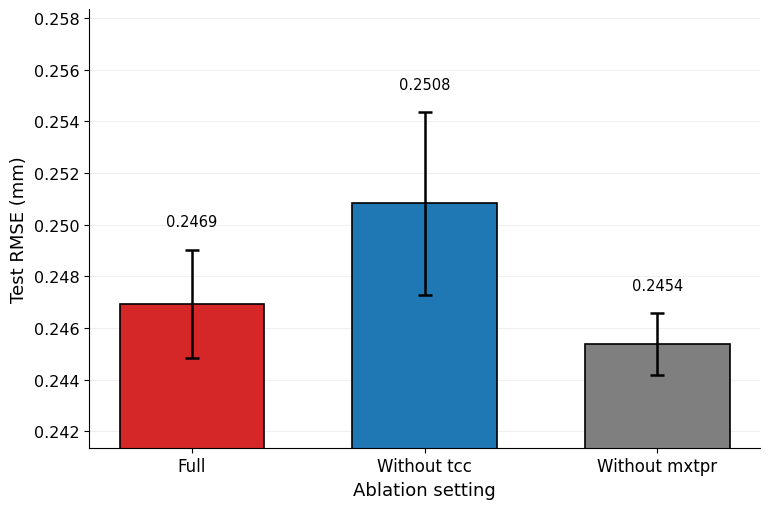

Saved:
/root/autodl-tmp/results/final_figures/feature_ablation_rmse_5seed.svg
/root/autodl-tmp/results/final_figures/feature_ablation_rmse_5seed.pdf
/root/autodl-tmp/results/final_figures/feature_ablation_rmse_5seed.png


In [14]:
# ============================================================
# Step 20C — Final Feature Ablation Figure
#
# Figure:
#   5-seed RMSE (mean ± std) for
#   Full / Without tcc / Without mxtpr
#
# Save to:
#   /root/autodl-tmp/results/final_figures/
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ABLATION_DIR = "/root/autodl-tmp/results/ablation"
FIG_DIR = "/root/autodl-tmp/results/final_figures"

os.makedirs(FIG_DIR, exist_ok=True)

raw_path = os.path.join(ABLATION_DIR, "targeted_ablation_5seed_raw.csv")
summary_path = os.path.join(ABLATION_DIR, "targeted_ablation_5seed_summary.csv")

assert os.path.exists(raw_path), f"Missing file: {raw_path}"
assert os.path.exists(summary_path), f"Missing file: {summary_path}"

raw_df = pd.read_csv(raw_path)
summary_df = pd.read_csv(summary_path)

# ------------------------------------------------------------
# Keep only the three useful experiments
# ------------------------------------------------------------
order = ["Full", "Without_tcc", "Without_mxtpr"]

summary_df = summary_df.copy()
summary_df = summary_df[summary_df["Experiment"].isin(order)].copy()
summary_df["Experiment"] = pd.Categorical(summary_df["Experiment"], categories=order, ordered=True)
summary_df = summary_df.sort_values("Experiment").reset_index(drop=True)

# Friendly labels for plotting
label_map = {
    "Full": "Full",
    "Without_tcc": "Without tcc",
    "Without_mxtpr": "Without mxtpr"
}

summary_df["Label"] = summary_df["Experiment"].map(label_map)

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
x = np.arange(len(summary_df))
rmse_mean = summary_df["RMSE_mean"].values
rmse_std = summary_df["RMSE_std"].values
labels = summary_df["Label"].tolist()

# ------------------------------------------------------------
# Colors
# Keep proposed-model family visually consistent
# ------------------------------------------------------------
color_map = {
    "Full": "#d62728",          # BU-LSTM-Attention red
    "Without_tcc": "#1f77b4",   # blue
    "Without_mxtpr": "#7f7f7f"  # gray
}
bar_colors = [color_map[e] for e in summary_df["Experiment"]]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.8, 5.2))

bars = ax.bar(
    x,
    rmse_mean,
    yerr=rmse_std,
    capsize=5,
    width=0.62,
    color=bar_colors,
    edgecolor="black",
    linewidth=1.2,
    error_kw=dict(
        elinewidth=1.8,
        capthick=1.8
    )
)

# ------------------------------------------------------------
# Optional numeric annotations
# ------------------------------------------------------------
for xi, mean_val, std_val in zip(x, rmse_mean, rmse_std):
    ax.text(
        xi,
        mean_val + std_val + 0.0008,
        f"{mean_val:.4f}",
        ha="center",
        va="bottom",
        fontsize=10.5
    )

# ------------------------------------------------------------
# Axes formatting (match previous final figures)
# ------------------------------------------------------------
ax.set_xlabel("Ablation setting", fontsize=13)
ax.set_ylabel("Test RMSE (mm)", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.tick_params(axis="y", labelsize=11.5)

ax.grid(axis="y", alpha=0.18, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tight y-limits around the data for readability
ymin = max(0, rmse_mean.min() - 0.004)
ymax = rmse_mean.max() + rmse_std.max() + 0.004
ax.set_ylim(ymin, ymax)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
base = os.path.join(FIG_DIR, "feature_ablation_rmse_5seed")

plt.savefig(base + ".svg", bbox_inches="tight")
plt.savefig(base + ".pdf", bbox_inches="tight")
plt.savefig(base + ".png", dpi=600, bbox_inches="tight")

plt.show()

print("Saved:")
print(base + ".svg")
print(base + ".pdf")
print(base + ".png")